<div style="font-size: 2.2em; font-weight: bold; line-height: 1.3;">Final Exam</div>

<div style="font-size: 1.5em; font-weight: bold; line-height: 1.5;">BUSN 41210: Financial Analytics</div>

<div style="font-size: 1.5em; font-weight: bold; line-height: 1.5;">Due: 5:00 pm on Sunday, Oct. 4th, 2026</div>

**Use of AI tools.** You may use any AI tool (ChatGPT, Claude, Copilot or others) for any part of this exam: code, explanations, writing. You are responsible for every answer you submit, exactly as if you had written it yourself. Every number must come from a cell in this notebook, and an answer you cannot explain or reproduce is your error, not the tool's.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



---
# Problem 1: Trees and Ensembles (20 points)

Lecture 8 built a single tree, then pruned it, then averaged many of them. This
problem walks that ladder on a small dataset where you can actually see the tree.

`Social_Network_Ads.csv` records 400 people shown an advertisement: their
`Gender`, `Age` and `EstimatedSalary`, and whether they `Purchased` (1) or not.
Use **5-fold stratified cross-validation with `random_state=7034`** for every
accuracy you report, and pass `random_state=7034` to every tree, forest and boosting model, so
the numbers are comparable to each other.

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.inspection import permutation_importance

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
import os
_DATA_DIR = _DATA_DIR if os.path.isdir(_DATA_DIR) else './'   # class server if present, else a local copy next to the notebook
ads = pd.read_csv(_DATA_DIR + 'Social_Network_Ads.csv')
# ads = pd.read_csv('Social_Network_Ads.csv')
ads['Gender'] = (ads.Gender == 'Male').astype(int)

Xa = ads[['Gender', 'Age', 'EstimatedSalary']]
ya = ads['Purchased']

cv5 = StratifiedKFold(5, shuffle=True, random_state=7034)
def cv_acc(model):
    """5-fold cross-validated accuracy."""
    return cross_val_score(model, Xa, ya, cv=cv5, scoring='accuracy').mean()

print(f"{len(ads)} people, {ya.mean():.1%} of them purchased")

400 people, 35.8% of them purchased


**1.1.** Before any model: what accuracy does the rule *"nobody purchases"* achieve? Report it, and treat it as the number every model below has to beat.

Now grow an **unpruned** classification tree and report its 5-fold accuracy. Then sweep `max_leaf_nodes` over $\{2, 3, 4, 6, 8, 12\}$ and report the accuracy at each. Which size does cross-validation prefer (if two sizes tie, take the smaller), and what happens on either side of it?

User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64

class counts: {0: 257, 1: 143}
distinct values per feature: {'Gender': 2, 'Age': 43, 'EstimatedSalary': 117}
      Gender   Age  EstimatedSalary
mean     0.5  37.7          69742.5
std      0.5  10.5          34097.0
min      0.0  18.0          15000.0
max      1.0  60.0         150000.0

the five CV folds (people held out, buyers among them): [(80, 28), (80, 28), (80, 29), (80, 29), (80, 29)]
people who share all three features with someone else: 40 | feature combinations with conflicting outcomes: 1

"Nobody purchases": 257/400 = 64.25% correct (fold by fold 63.75% to 65.00%)


Unpruned tree fitted on all 400: 61 leaves, depth 14, in-sample 399/400 correct (diagnostic only)


,CV accuracy,correct /400,fold min,fold max,fold sd,training-fold accuracy (diagnostic),people correct per fold (of 80)
nobody purchases (baseline),64.25%,257,63.75%,65.00%,0.007,,
unpruned,85.00%,340,83.75%,86.25%,0.013,99.81%,67 68 69 67 69
2 leaves,83.50%,334,81.25%,87.50%,0.024,84.00%,65 67 66 66 70
3 leaves,90.75%,363,85.00%,95.00%,0.037,91.63%,68 72 73 74 76
4 leaves,90.75%,363,85.00%,95.00%,0.037,91.75%,68 72 73 74 76
6 leaves,89.50%,358,86.25%,93.75%,0.027,92.62%,69 71 72 71 75
8 leaves,88.25%,353,82.50%,93.75%,0.045,93.25%,66 72 72 68 75
12 leaves,87.50%,350,83.75%,92.50%,0.036,94.44%,67 72 69 68 74


CV prefers 3 leaves (363/400 correct); sizes tied at the top: [3, 4]
3- and 4-leaf trees make identical out-of-fold predictions for all 400 people: True


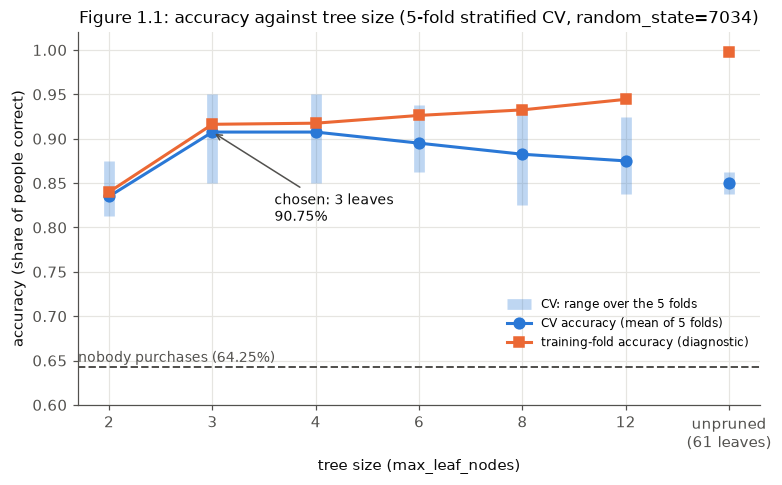

In [3]:
from sklearn.model_selection import cross_validate
from sklearn.tree import export_text

# Plot style for every figure in this notebook: colour-blind-checked colours, light grid (no sns.set()).
C_BLUE, C_ORANGE, C_AQUA = '#2a78d6', '#eb6834', '#1baf7a'
C_INK, C_GREY, C_LIGHT = '#0b0b0b', '#52514e', '#e6e5e1'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': C_LIGHT, 'grid.linewidth': 0.8, 'axes.edgecolor': C_GREY,
                     'axes.labelcolor': C_INK, 'axes.titlesize': 11, 'xtick.color': C_GREY,
                     'ytick.color': C_GREY, 'lines.linewidth': 2, 'legend.frameon': False,
                     'figure.dpi': 110})

# --- Step 0: describe the data before modelling ---
N = len(ya)
print(ads.dtypes.to_string())
print('\nclass counts:', ya.value_counts().sort_index().to_dict())
print('distinct values per feature:', Xa.nunique().to_dict())
print(Xa.describe().loc[['mean', 'std', 'min', 'max']].round(1).to_string())
print('\nthe five CV folds (people held out, buyers among them):',
      [(len(te), int(ya.iloc[te].sum())) for _, te in cv5.split(Xa, ya)])
assert ads.shape == (400, 5) and ya.sum() == 143 and Xa.isna().sum().sum() == 0
cells = ads.groupby(list(Xa.columns)).Purchased.agg(['size', 'sum'])
print('people who share all three features with someone else:', int(Xa.duplicated(keep=False).sum()),
      '| feature combinations with conflicting outcomes:', int(((cells['sum'] > 0) & (cells['sum'] < cells['size'])).sum()))

# --- The bar every model must beat: "nobody purchases" (majority class; L6 p.57) ---
base_correct = int((ya == 0).sum())                        # the rule is right for every non-buyer
base_folds = np.array([(ya.iloc[te] == 0).mean() for _, te in cv5.split(Xa, ya)])
assert int(round(base_folds.mean() * N)) == base_correct    # equal 80-person folds: fold average = pooled
print(f'\n"Nobody purchases": {base_correct}/{N} = {base_correct / N:.2%} correct '
      f'(fold by fold {base_folds.min():.2%} to {base_folds.max():.2%})')

def cv_detail(model, name):
    """Accuracy on the shared cv5 folds: the mean (identical to cv_acc), people correct out of 400,
    the fold spread, and the mean training-fold accuracy (an over-fitting diagnostic, not a reported accuracy)."""
    r = cross_validate(model, Xa, ya, cv=cv5, scoring='accuracy', return_train_score=True)
    acc = r['test_score'].mean()
    assert np.isclose(acc, cv_acc(model))                    # same folds and fits as the notebook's cv_acc()
    return {'model': name, 'CV accuracy': acc, 'correct /400': int(round(acc * N)),
            'fold min': r['test_score'].min(), 'fold max': r['test_score'].max(),
            'fold sd': r['test_score'].std(ddof=1),
            'training-fold accuracy (diagnostic)': r['train_score'].mean(),
            'folds': np.rint(r['test_score'] * len(ya) / 5).astype(int)}   # people correct in each fold of 80

sizes = [2, 3, 4, 6, 8, 12]
rows = [cv_detail(DecisionTreeClassifier(random_state=7034), 'unpruned')]
rows += [cv_detail(DecisionTreeClassifier(max_leaf_nodes=k, random_state=7034), f'{k} leaves') for k in sizes]
tab11 = pd.DataFrame(rows).set_index('model')

# CV's preferred size: the most people correct; an exact tie goes to the smaller tree (the exam's rule).
best = max(tab11.loc[f'{k} leaves', 'correct /400'] for k in sizes)
tied = [k for k in sizes if tab11.loc[f'{k} leaves', 'correct /400'] == best]
k_star = min(tied)

full_unpruned = DecisionTreeClassifier(random_state=7034).fit(Xa, ya)
print(f'Unpruned tree fitted on all {N}: {full_unpruned.get_n_leaves()} leaves, depth {full_unpruned.get_depth()}, '
      f'in-sample {int(round(full_unpruned.score(Xa, ya) * N))}/{N} correct (diagnostic only)')

show = tab11.drop(columns='folds')
base_row = pd.DataFrame([{'CV accuracy': base_correct / N, 'correct /400': base_correct,
                          'fold min': base_folds.min(), 'fold max': base_folds.max(),
                          'fold sd': base_folds.std(ddof=1)}], index=['nobody purchases (baseline)'])
show = pd.concat([base_row, show])
show['people correct per fold (of 80)'] = [''] + [' '.join(map(str, f)) for f in tab11['folds']]
pct = ['CV accuracy', 'fold min', 'fold max', 'training-fold accuracy (diagnostic)']
display(show.style.format({**{c: '{:.2%}' for c in pct}, 'fold sd': '{:.3f}'}, na_rep='')
            .set_caption('Table 1.1: 5-fold stratified CV accuracy (random_state=7034)'))
print(f'CV prefers {k_star} leaves ({best}/400 correct); sizes tied at the top: {tied}')
from sklearn.model_selection import cross_val_predict
oof = {k: cross_val_predict(DecisionTreeClassifier(max_leaf_nodes=k, random_state=7034), Xa, ya, cv=cv5) for k in tied}
for k in tied[1:]:
    print(f'{k_star}- and {k}-leaf trees make identical out-of-fold predictions for all {N} people:',
          bool((oof[k] == oof[k_star]).all()))

# Figure 1.1: CV accuracy against tree size, with the training-fold accuracy as the over-fitting diagnostic
order = [f'{k} leaves' for k in sizes] + ['unpruned']
labels = [str(k) for k in sizes] + [f'unpruned\n({full_unpruned.get_n_leaves()} leaves)']
x = np.arange(len(order))
cv_mean = tab11.loc[order, 'CV accuracy'].to_numpy()
lo, hi = tab11.loc[order, 'fold min'].to_numpy(), tab11.loc[order, 'fold max'].to_numpy()
tr = tab11.loc[order, 'training-fold accuracy (diagnostic)'].to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.vlines(x, lo, hi, color=C_BLUE, alpha=0.3, linewidth=7, label='CV: range over the 5 folds')
ax.plot(x[:-1], cv_mean[:-1], 'o-', color=C_BLUE, markersize=7, label='CV accuracy (mean of 5 folds)')
ax.plot(x[-1:], cv_mean[-1:], 'o', color=C_BLUE, markersize=7)
ax.plot(x[:-1], tr[:-1], 's-', color=C_ORANGE, markersize=6, label='training-fold accuracy (diagnostic)')
ax.plot(x[-1:], tr[-1:], 's', color=C_ORANGE, markersize=6)
ax.axhline(base_correct / N, color=C_GREY, linestyle='--', linewidth=1.3)
ax.text(-0.3, base_correct / N + 0.006, f'nobody purchases ({base_correct / N:.2%})', color=C_GREY, fontsize=9)
i = sizes.index(k_star)
ax.annotate(f'chosen: {k_star} leaves\n{cv_mean[i]:.2%}', xy=(x[i], cv_mean[i]), xytext=(x[i] + 0.6, cv_mean[i] - 0.1),
            color=C_INK, fontsize=9, arrowprops=dict(arrowstyle='->', color=C_GREY))
ax.set_xticks(x, labels)
ax.set_xlabel('tree size (max_leaf_nodes)')
ax.set_ylabel('accuracy (share of people correct)')
ax.set_ylim(0.6, 1.02)
ax.set_title('Figure 1.1: accuracy against tree size (5-fold stratified CV, random_state=7034)')
ax.legend(loc='lower right', bbox_to_anchor=(1, 0.12), fontsize=8)
plt.show()

**Answer:**

**The bar to beat.** "Nobody purchases" is right for every non-buyer: **257 of 400 = 64.25%** (63.75% to 65.00% fold by fold). Every model below has to beat 64.25% (L6 p.57).

**The unpruned tree** scores **85.00%** in 5-fold CV (340/400). Fitted on all 400 people it has 61 leaves and depth 14 and gets 399 of 400 right in sample (the one miss is a pair of identical people with opposite outcomes), so it is memorising noise (L8 p.30).

**The sweep** (Table 1.1, Figure 1.1):

| `max_leaf_nodes` | 2 | 3 | 4 | 6 | 8 | 12 |
|---|---|---|---|---|---|---|
| CV accuracy | 83.50% | **90.75%** | **90.75%** | 89.50% | 88.25% | 87.50% |

**Cross-validation prefers 3 leaves.** 3 and 4 leaves tie exactly (363/400 correct) and the tie goes to the smaller tree. The tie is not luck: the fourth split changes no held-out prediction, so the two trees make identical out-of-fold predictions for all 400 people. It is also Lecture 8's tree for this dataset (L8 p.33).

**Either side of it:**
- **Fewer leaves underfit (bias).** The 2-leaf tree makes only the Age split: 83.50% in CV and 84.0% on its own training folds. Both are low, so the model is too simple; it misses that younger people with high salaries buy.
- **More leaves overfit (variance).** From 6 to 12 leaves, CV accuracy falls from 89.50% to 87.50% while training-fold accuracy rises from 92.6% to 94.4%. The unpruned tree is the extreme: 99.8% on the training folds, 85.00% out of sample. This is the hump of L8 p.32.

**How much to read into the gaps.** On the shared folds the 3-leaf tree beats the 6-leaf tree in 4 of the 5, but by only 1 to 3 people each: consistent but small. The 90.75% also won a search over six sizes, so it is slightly optimistic (L5 p.57). The conclusion does not depend on it: 2 leaves underfit, 3 or 4 capture the pattern, and larger trees only add noise.

**1.2.** Plot the tree you chose in 1.1 (`plot_tree` with `feature_names=Xa.columns`), and then **say what it does in one or two English sentences** — the kind you could put in front of someone with no statistics.

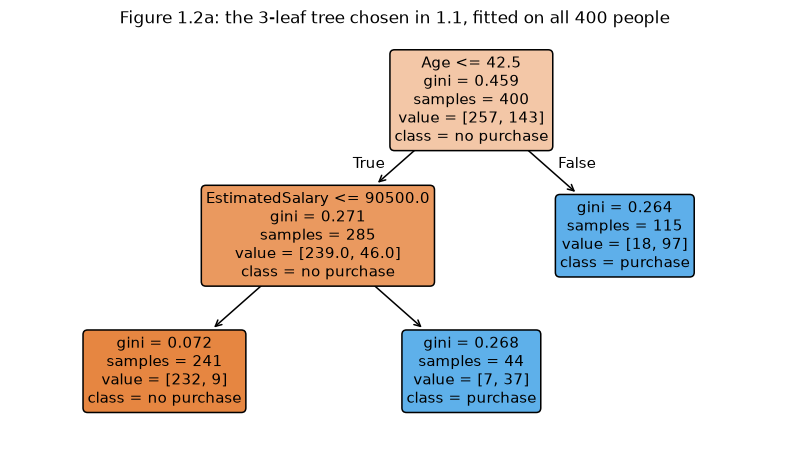

|--- Age <= 42.50
|   |--- EstimatedSalary <= 90500.00
|   |   |--- weights: [232.00, 9.00] class: 0
|   |--- EstimatedSalary >  90500.00
|   |   |--- weights: [7.00, 37.00] class: 1
|--- Age >  42.50
|   |--- weights: [18.00, 97.00] class: 1

in-sample accuracy of this tree: 91.50% (diagnostic; its honest accuracy is the CV figure)


,rule,people,buyers,purchase rate,tree predicts
leaf,,,,,
2,Age > 42.5,115,97,84%,purchase
3,Age <= 42.5 and EstimatedSalary <= 90500,241,9,4%,no purchase
4,Age <= 42.5 and EstimatedSalary > 90500,44,37,84%,purchase


Does the tree use Gender? False


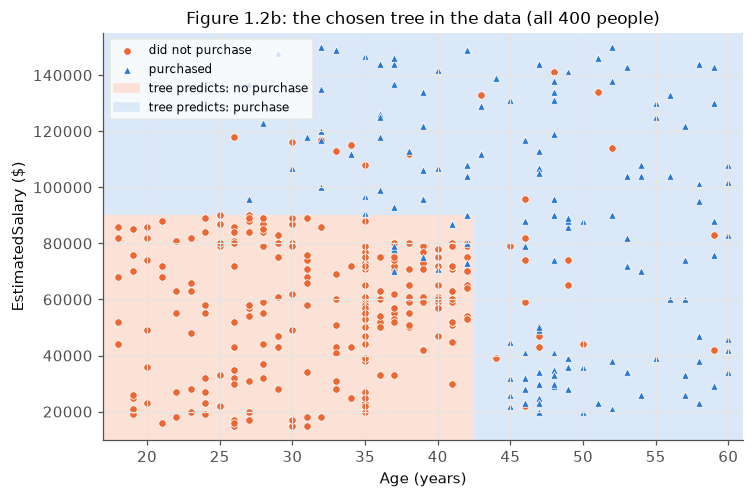

fold 1 tree splits: Age <= 44.5; EstimatedSalary <= 91500
fold 2 tree splits: Age <= 44.5; EstimatedSalary <= 89500
fold 3 tree splits: Age <= 42.5; EstimatedSalary <= 89500
fold 4 tree splits: Age <= 42.5; EstimatedSalary <= 90500
fold 5 tree splits: Age <= 42.5; EstimatedSalary <= 90500


In [4]:
# Refit the size CV chose on all 400 people: CV chose a size, not a particular tree (L5 p.36; L8 p.33).
tree_star = DecisionTreeClassifier(max_leaf_nodes=k_star, random_state=7034).fit(Xa, ya)

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_tree(tree_star, feature_names=Xa.columns, class_names=['no purchase', 'purchase'],
          filled=True, rounded=True, impurity=True, fontsize=10, ax=ax)
ax.set_title(f'Figure 1.2a: the {k_star}-leaf tree chosen in 1.1, fitted on all {N} people')
plt.show()
print(export_text(tree_star, feature_names=list(Xa.columns), show_weights=True))
print(f'in-sample accuracy of this tree: {tree_star.score(Xa, ya):.2%} (diagnostic; its honest accuracy is the CV figure)')

def leaf_rules(tree, names):
    """The conditions that lead to each leaf, in words."""
    t, rules = tree.tree_, {}
    def walk(node, conds):
        if t.children_left[node] == -1:
            rules[node] = ' and '.join(conds) if conds else 'everyone'
            return
        f, thr = names[t.feature[node]], t.threshold[node]
        walk(t.children_left[node], conds + [f'{f} <= {thr:g}'])
        walk(t.children_right[node], conds + [f'{f} > {thr:g}'])
    walk(0, [])
    return rules

rules = leaf_rules(tree_star, list(Xa.columns))
tab12 = (pd.DataFrame({'leaf': tree_star.apply(Xa), 'bought': ya}).groupby('leaf')['bought']
           .agg(people='size', buyers='sum'))
tab12['purchase rate'] = tab12.buyers / tab12.people
tab12['tree predicts'] = np.where(tab12['purchase rate'] > 0.5, 'purchase', 'no purchase')
tab12.insert(0, 'rule', [rules[i] for i in tab12.index])
display(tab12.style.format({'purchase rate': '{:.0%}'}).set_caption('Table 1.2: the leaves of the chosen tree'))
uses_gender = 0 in set(tree_star.tree_.feature[tree_star.tree_.feature >= 0])
print('Does the tree use Gender?', uses_gender)

# Figure 1.2b: where the tree predicts "purchase" in the Age x Salary plane (as in L8 p.34)
from matplotlib.patches import Patch
AA, SS = np.meshgrid(np.linspace(17, 61, 300), np.linspace(10_000, 155_000, 300))
genders = [0, 1] if uses_gender else [0]           # Gender only needs its own panel if the tree uses it
fig, axes = plt.subplots(1, len(genders), figsize=(7.5 * len(genders), 4.8), squeeze=False)
for ax, g in zip(axes[0], genders):
    grid = pd.DataFrame({'Gender': g, 'Age': AA.ravel(), 'EstimatedSalary': SS.ravel()})[Xa.columns]
    Z = tree_star.predict(grid).reshape(AA.shape)
    ax.contourf(AA, SS, Z, levels=[-0.5, 0.5, 1.5], colors=['#fbe1d6', '#dbe8f8'])   # same colours as plot_tree
    pts = ads if not uses_gender else ads[ads.Gender == g]
    for val, col, mk, lab in [(0, C_ORANGE, 'o', 'did not purchase'), (1, C_BLUE, '^', 'purchased')]:
        s = pts[pts.Purchased == val]
        ax.scatter(s.Age, s.EstimatedSalary, s=24, c=col, marker=mk, edgecolors='white', linewidths=0.5, label=lab)
    handles = ax.get_legend_handles_labels()[0] + [Patch(color='#fbe1d6', label='tree predicts: no purchase'),
                                                  Patch(color='#dbe8f8', label='tree predicts: purchase')]
    ax.legend(handles=handles, loc='upper left', fontsize=8, frameon=True, facecolor='white', edgecolor=C_LIGHT)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('EstimatedSalary ($)')
    ax.set_title('Figure 1.2b: the chosen tree in the data' + (f' (Gender = {g})' if uses_gender else ' (all 400 people)'))
plt.show()

# How stable is the structure? The same size fitted on each CV training fold (320 people each; L8 p.40).
folds_fit = cross_validate(DecisionTreeClassifier(max_leaf_nodes=k_star, random_state=7034), Xa, ya,
                           cv=cv5, scoring='accuracy', return_estimator=True)['estimator']
for i, est in enumerate(folds_fit, 1):
    t = est.tree_
    print(f'fold {i} tree splits:', '; '.join(f'{Xa.columns[t.feature[n]]} <= {t.threshold[n]:g}'
                                              for n in range(t.node_count) if t.feature[n] >= 0))

# Notes: the honest accuracy of this tree is the 5-fold CV figure from 1.1, not its in-sample score. It is the
# same tree as L8 p.33, and the five fold trees above all split on Age and then Salary at similar thresholds.

**Answer:**

People over 42 mostly bought (97 of 115, about 84 in every 100), and so did people aged 42 or younger earning more than \$90,000 (37 of 44, again about 84 in 100), while younger people earning \$90,000 or less almost never bought (9 of 241, about 4 in 100). Gender plays no part in the rule.


**1.3.** Fit a random forest (300 trees) and a gradient boosted model (100 rounds), both with `random_state=7034`, and report their 5-fold accuracies.

Do they beat the tree from 1.1? Report what you find **whichever way it comes out**, and explain in two or three sentences why that might be, given the size and shape of this dataset.

,CV accuracy,correct /400,fold min,fold max,fold sd,training-fold accuracy (diagnostic),vs chosen tree (people /400),folds better / equal / worse than tree,people correct per fold (of 80)
model,,,,,,,,,
unpruned,85.00%,340,83.75%,86.25%,0.013,99.81%,-23,0 / 0 / 5,67 68 69 67 69
3 leaves,90.75%,363,85.00%,95.00%,0.037,91.63%,0,0 / 5 / 0,68 72 73 74 76
random forest (300 trees),88.75%,355,85.00%,92.50%,0.032,99.81%,-8,2 / 0 / 3,69 73 71 68 74
gradient boosting (100 rounds),89.00%,356,83.75%,93.75%,0.040,97.44%,-7,1 / 2 / 2,69 72 73 67 75


RF: {'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True} | features tried at each split: 1 | mean leaves per tree: 50.2
GB: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0}


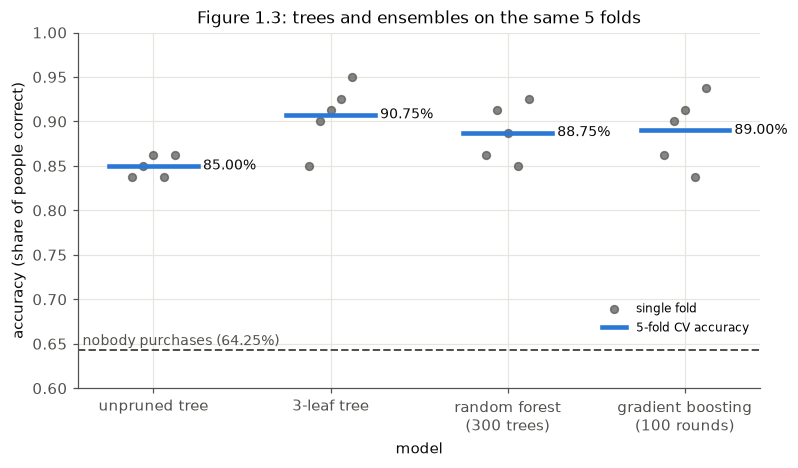

In [5]:
rf = RandomForestClassifier(n_estimators=300, random_state=7034)
gb = GradientBoostingClassifier(n_estimators=100, random_state=7034)
tab13 = pd.concat([tab11.loc[['unpruned', f'{k_star} leaves']],
                   pd.DataFrame([cv_detail(rf, 'random forest (300 trees)'),
                                 cv_detail(gb, 'gradient boosting (100 rounds)')]).set_index('model')])

# Head to head with the chosen tree on the same 5 folds (people correct per fold of 80)
tree_folds = tab11.loc[f'{k_star} leaves', 'folds']
tab13['vs chosen tree (people /400)'] = tab13['correct /400'] - tab11.loc[f'{k_star} leaves', 'correct /400']
tab13['folds better / equal / worse than tree'] = [
    f'{(f > tree_folds).sum()} / {(f == tree_folds).sum()} / {(f < tree_folds).sum()}' for f in tab13['folds']]
tab13['people correct per fold (of 80)'] = [' '.join(map(str, f)) for f in tab13['folds']]
pct = ['CV accuracy', 'fold min', 'fold max', 'training-fold accuracy (diagnostic)']
display(tab13.drop(columns='folds').style.format({**{c: '{:.2%}' for c in pct}, 'fold sd': '{:.3f}'})
        .set_caption(f'Table 1.3: ensembles against the {k_star}-leaf tree (same 5 folds; baseline {base_correct / N:.2%})'))

# The settings actually used (the exam fixes 300 trees / 100 rounds; everything else is the sklearn default)
rf_full = RandomForestClassifier(n_estimators=300, random_state=7034).fit(Xa, ya)
print('RF:', {k: rf.get_params()[k] for k in ['n_estimators', 'max_features', 'max_depth', 'min_samples_leaf', 'bootstrap']},
      '| features tried at each split:', rf_full.estimators_[0].max_features_,
      '| mean leaves per tree:', round(np.mean([t.get_n_leaves() for t in rf_full.estimators_]), 1))
print('GB:', {k: gb.get_params()[k] for k in ['n_estimators', 'learning_rate', 'max_depth', 'subsample']})

# Figure 1.3: the five fold scores and their mean for each model, against the baseline
models = ['unpruned', f'{k_star} leaves', 'random forest (300 trees)', 'gradient boosting (100 rounds)']
fig, ax = plt.subplots(figsize=(8, 4.2))
for j, m in enumerate(models):
    f = tab13.loc[m, 'folds'] / 80
    ax.scatter(np.full(5, j) + np.linspace(-0.12, 0.12, 5), f, s=26, color=C_GREY, alpha=0.7,
               label='single fold' if j == 0 else None, zorder=2)
    ax.plot([j - 0.25, j + 0.25], [tab13.loc[m, 'CV accuracy']] * 2, color=C_BLUE, linewidth=3,
            label='5-fold CV accuracy' if j == 0 else None, zorder=3)
    ax.text(j + 0.28, tab13.loc[m, 'CV accuracy'], f"{tab13.loc[m, 'CV accuracy']:.2%}", va='center', fontsize=9, color=C_INK)
ax.axhline(base_correct / N, color=C_GREY, linestyle='--', linewidth=1.3)
ax.text(-0.4, base_correct / N + 0.006, f'nobody purchases ({base_correct / N:.2%})', color=C_GREY, fontsize=9)
ax.set_xticks(range(len(models)), ['unpruned tree', f'{k_star}-leaf tree', 'random forest\n(300 trees)',
                                   'gradient boosting\n(100 rounds)'])
ax.set_xlabel('model')
ax.set_ylabel('accuracy (share of people correct)')
ax.set_ylim(0.6, 1.0)
ax.set_title('Figure 1.3: trees and ensembles on the same 5 folds')
ax.legend(loc='lower right', bbox_to_anchor=(1, 0.12), fontsize=8)
plt.show()

**Answer:** (Table 1.3, Figure 1.3; the same five folds as 1.1)

| model | 5-fold CV accuracy | people correct /400 |
|---|---|---|
| nobody purchases | 64.25% | 257 |
| unpruned tree | 85.00% | 340 |
| **3-leaf tree (from 1.1)** | **90.75%** | **363** |
| random forest, 300 trees | 88.75% | 355 |
| gradient boosting, 100 rounds | 89.00% | 356 |

**Neither ensemble beats the 3-leaf tree.** Both clear the 64.25% bar and the unpruned tree but get 8 (forest) and 7 (boosting) fewer people right; fold by fold the forest wins 2 and loses 3, boosting wins 1, ties 2, loses 2. Most of the gap comes from the fourth fold (tree 74, forest 68, boosting 67), so the fair reading is "no better than the small tree", not "worse".

**Why:** With 400 people and effectively two inputs that matter, the buying pattern is close to one rectangle in the Age × Salary plane (Figure 1.2b), which the 3-leaf tree already draws, so there is little *variance* for a forest to average away and little *bias* for boosting to remove (L8 p.51). At their untuned defaults both ensembles fit noise instead: the forest's trees average 50.2 leaves and score 99.81% on their own training folds, and boosting scores 97.44%, against the small tree's 91.63%. On data this small and this simple the readable tree is the better choice, unlike the lecture's much larger housing data, where averaging beats one tree (L8 p.54).

**1.4.** Split the data 70/30 (`random_state=7034`, `stratify=ya`), fit a 300-tree forest on the training set, and compute two importance rankings: `feature_importances_` (mean decrease in impurity, computed **in sample**) and `permutation_importance` on the **held-out** 30%.

Put them side by side. Do the two rankings agree on which variable matters most? Where they disagree, explain why — and say which of the two you would show to someone making a decision.

training: 280 people (100 buyers); held out: 120 people (43 buyers)


Diagnostics only (the reported RF accuracy is the 5-fold figure in 1.3): training accuracy 0.996, held-out accuracy 0.917, held-out "nobody purchases" 0.642; mean leaves per tree 38.2


,MDI share (in-sample),MDI rank,held-out accuracy drop (pp),sd over 50 shuffles (pp),permutation share,permutation rank,diagnostic: drop on training rows (pp),splits in the forest,distinct values (training rows)
Age,0.470,2,25.50,3.66,0.569,1,26.96,4751,42
EstimatedSalary,0.519,1,17.13,2.95,0.382,2,28.83,5623,108
Gender,0.011,3,2.18,1.21,0.049,3,5.03,776,2


corr(Age, EstimatedSalary) = 0.155


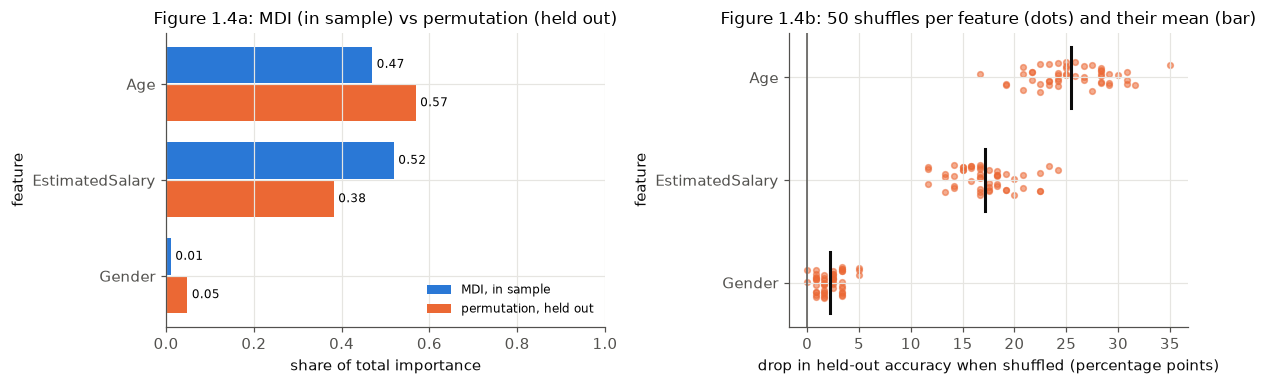

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(Xa, ya, test_size=0.3, random_state=7034, stratify=ya)
print(f'training: {len(X_tr)} people ({int(y_tr.sum())} buyers); held out: {len(X_te)} people ({int(y_te.sum())} buyers)')
rf14 = RandomForestClassifier(n_estimators=300, random_state=7034).fit(X_tr, y_tr)
print(f'Diagnostics only (the reported RF accuracy is the 5-fold figure in 1.3): training accuracy '
      f'{rf14.score(X_tr, y_tr):.3f}, held-out accuracy {rf14.score(X_te, y_te):.3f}, '
      f'held-out "nobody purchases" {(y_te == 0).mean():.3f}; mean leaves per tree '
      f'{np.mean([t.get_n_leaves() for t in rf14.estimators_]):.1f}')

mdi = pd.Series(rf14.feature_importances_, index=Xa.columns)     # mean decrease in impurity, in sample (L8 p.47, p.56)
pi_te = permutation_importance(rf14, X_te, y_te, scoring='accuracy', n_repeats=50, random_state=7034)  # held out (L8 p.57)
pi_tr = permutation_importance(rf14, X_tr, y_tr, scoring='accuracy', n_repeats=50, random_state=7034)  # diagnostic
perm = pd.Series(pi_te.importances_mean, index=Xa.columns)
splits = pd.Series([sum(int((t.tree_.feature == j).sum()) for t in rf14.estimators_) for j in range(Xa.shape[1])],
                   index=Xa.columns)
tab14 = pd.DataFrame({
    'MDI share (in-sample)': mdi,
    'MDI rank': mdi.rank(ascending=False, method='min').astype(int),
    'held-out accuracy drop (pp)': 100 * perm,
    'sd over 50 shuffles (pp)': 100 * pd.Series(pi_te.importances_std, index=Xa.columns),
    'permutation share': perm.clip(lower=0) / perm.clip(lower=0).sum(),   # negative drops set to 0 before normalising
    'permutation rank': perm.rank(ascending=False, method='min').astype(int),
    'diagnostic: drop on training rows (pp)': 100 * pd.Series(pi_tr.importances_mean, index=Xa.columns),
    'splits in the forest': splits,
    'distinct values (training rows)': X_tr.nunique()}).sort_values('permutation rank')
assert np.isclose(mdi.sum(), 1) and pi_te.importances.shape == (3, 50)
display(tab14.style.format({'MDI share (in-sample)': '{:.3f}', 'permutation share': '{:.3f}',
                            'held-out accuracy drop (pp)': '{:.2f}', 'sd over 50 shuffles (pp)': '{:.2f}',
                            'diagnostic: drop on training rows (pp)': '{:.2f}'})
        .set_caption('Table 1.4: two importance rankings for the same 300-tree forest'))
print(f'corr(Age, EstimatedSalary) = {Xa.Age.corr(Xa.EstimatedSalary):.3f}')

# Figure 1.4: the two rankings side by side (left) and the spread of the 50 held-out shuffles (right)
feats = list(tab14.index)[::-1]                      # most important (by permutation) at the top
yy = np.arange(len(feats))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={'width_ratios': [1.1, 1]})
ax1.barh(yy + 0.2, tab14.loc[feats, 'MDI share (in-sample)'], height=0.38, color=C_BLUE, label='MDI, in sample')
ax1.barh(yy - 0.2, tab14.loc[feats, 'permutation share'], height=0.38, color=C_ORANGE, label='permutation, held out')
for k, f in enumerate(feats):
    ax1.text(tab14.loc[f, 'MDI share (in-sample)'] + 0.01, k + 0.2, f"{tab14.loc[f, 'MDI share (in-sample)']:.2f}", va='center', fontsize=8)
    ax1.text(tab14.loc[f, 'permutation share'] + 0.01, k - 0.2, f"{tab14.loc[f, 'permutation share']:.2f}", va='center', fontsize=8)
ax1.set_yticks(yy, feats)
ax1.set_ylabel('feature')
ax1.set_xlabel('share of total importance')
ax1.set_xlim(0, 1)
ax1.legend(loc='lower right', fontsize=8)
ax1.set_title('Figure 1.4a: MDI (in sample) vs permutation (held out)')
rng_jit = np.random.default_rng(7034)                  # vertical jitter only, so the dots do not sit on top of each other
for k, f in enumerate(feats):
    drops = 100 * pi_te.importances[list(Xa.columns).index(f)]
    ax2.scatter(drops, k + rng_jit.uniform(-0.15, 0.15, drops.size), s=14, color=C_ORANGE, alpha=0.55)
    ax2.plot([drops.mean()] * 2, [k - 0.3, k + 0.3], color=C_INK, linewidth=2)
ax2.set_yticks(yy, feats)
ax2.set_ylabel('feature')
ax2.axvline(0, color=C_GREY, linewidth=1)
ax2.set_xlabel('drop in held-out accuracy when shuffled (percentage points)')
ax2.set_title('Figure 1.4b: 50 shuffles per feature (dots) and their mean (bar)')
plt.tight_layout()
plt.show()

**Answer:**

**Setup.** Stratified 70/30 split (`random_state=7034`): 280 training people (100 buyers), 120 held out (43 buyers); 300-tree forest. (Its held-out accuracy, 91.7%, is a diagnostic; the reported accuracy is the 5-fold 88.75% from 1.3.)

**Side by side (Table 1.4, Figure 1.4):**

| feature | MDI share, in sample | MDI rank | held-out permutation: accuracy drop (sd over 50 shuffles) | permutation rank |
|---|---|---|---|---|
| Age | 0.470 | 2 | **25.5 pp** (3.7) | **1** |
| EstimatedSalary | **0.519** | **1** | 17.1 pp (3.0) | 2 |
| Gender | 0.011 | 3 | 2.2 pp (1.2) | 3 |

**Do they agree on the most important variable? No.** MDI puts Salary first; held-out permutation puts Age first. Both put Gender last.

**Why they disagree:**
- **MDI is computed in sample** (L8 p.47): it sums the impurity reduction of every split on the training rows. The trees are deep (about 38 leaves each, 99.6% training accuracy), so many splits fit noise, and each credits some variable.
- **Salary offers the most places to split**: 108 distinct training values against 42 for Age and 2 for Gender, and 5,623 splits against 4,751 for Age, so noise-fitting splits pile credit onto it. MDI "rewards a column for merely offering many places to split" (L8 p.58).
- **The diagnostic agrees**: permutation importance on the *training* rows also ranks Salary above Age (28.8 vs 27.0 pp). The MDI margin is small (0.519 against 0.470) and could flip on another split; the mechanism only predicts a tilt toward Salary.
- Shared credit between correlated inputs (L8 p.58) matters little: corr(Age, Salary) is only 0.155.

**What I would show a decision maker: the held-out permutation ranking.** It measures the accuracy lost on new people when a variable's information is destroyed, the question the decision maker is asking (L8 p.57). Caveats: it rests on 120 people (the shuffles alone move it by ±3 to 4 pp); it has no sign (L8 p.60), so the direction comes from 1.2 (older people, and younger people with high salaries, buy); and it describes what the model uses, not a causal effect.

**1.5** (Open-Ended) Each row here is a *person*, and the rows are unrelated to each other. Suppose instead each row were a *month* of one stock's data, and you were predicting whether next month's return is positive.

Cross-validation with `shuffle=True` — which you used throughout this problem — would then be **wrong**. Explain precisely what goes wrong, what you would do instead, and which way the error would push your reported accuracy.

In [7]:
# No code is needed for 1.5: the answer below is conceptual (the exam asks for code only "if any").

**Answer:**

**What goes wrong.** Shuffled K-fold assumes the rows are exchangeable, like unrelated people (L5 p.28). Months of one stock are not.
1. **The future leaks into training.** `StratifiedKFold(shuffle=True)` assigns months to folds at random, so the model scored on, say, 2015 has also been trained on 2016–2021, information no forecaster ever has: "the random fold sees the future" (L5 p.56).
2. **Neighbouring months are near-duplicates.** Trailing-window predictors barely change from month to month (a 12-month past return shares 11 of its 12 months with the next row's), and calm and turbulent periods persist, so each test month has near-copies in the training folds that a tree can look up instead of forecasting. This mechanism is our reasoning; the course's rule is that "Usually, CV is not valid with time-series data" (L5 p.48).
3. **The model is then tuned to the leak.** Validation flatters complex settings, so CV picks too big a tree. In the lecture's experiment, random folds on time-ordered data under-regularised (23 variables instead of 15) and cost 0.036 of out-of-sample R² (L5 p.56).
4. **Two tempting fixes fail.** `KFold(shuffle=False)` still trains the early folds on later data. Stratifying (our reasoning) builds every fold with the full-period share of up months, which is only known at the end.

**Which way the error goes: upward.** Every leak adds information a real forecaster would not have, so the reported accuracy is too optimistic in expectation; the course treats this as a fatal error (L5 p.58). Monthly returns are dominated by news (L1 p.33), so their signs carry little signal and an honest accuracy close to the "always up" base rate is normal; a much higher number is a reason "to go looking for the leak" (L5 p.57).

**What to do instead: walk-forward evaluation in time order** (L5 p.48–52).
- Build predictors only from information known by the end of month t−1, and fit any scaler or imputer inside each training window.
- Use an expanding window: train on months 1…t, choose `max_leaf_nodes` on the *following* validation block, predict the next test block, roll forward and pool the test predictions (a fixed-length rolling window if the stock's behaviour drifts).
- Keep a final test period untouched until the model is chosen, and touch it once (L4 p.43).
- Report the accuracy next to a benchmark fixed in advance (L6 p.57): "always up", learned from the training months only.

---
# Problem 2: Training on Your Own Output (20 points)

A risk desk estimates the daily volatility of its portfolio from a library of past daily returns
and reports the one-day 1% Value-at-Risk. Under a fitted normal distribution $N(0, \hat\sigma^2)$
the 1% quantile is $-2.326\,\hat\sigma$, so the desk reports $\text{VaR} = 2.326\,\hat\sigma$: under
this model, estimating VaR *is* estimating $\hat\sigma$. In 2016 the desk decided that the library
should be refreshed every night so that it always reflects the newest model. Its pipeline manual:

> *Every night the pipeline **(1)** fits $\hat\sigma^2$ to the library with the usual unbiased sample
> variance, $\hat\sigma^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar x)^2$, and sets the mean of the
> fitted normal to zero; **(2)** draws 500 fresh scenarios from $N(0, \hat\sigma^2)$; **(3)** replaces
> the library with tonight's 500 scenarios, so the library keeps its size, because the newest model is the best model and
> yesterday's data came from a worse one; and **(4)** reports $\text{VaR} = 2.326\,\hat\sigma$.*

On the first night the library held 500 real daily returns. The pipeline then ran every night for
ten years, 2,500 refits in all, and the reported VaR fell from 2.8% of NAV to 0.24%, while the
volatility of the desk's markets had not changed. The desk was praised for de-risking. The Chief Risk Officer, who does not
believe in free lunches, wants to know what happened.

**Rules.** Work in units of the true volatility: $\sigma = 1$, so the *correct* VaR is $2.326$ on
every night and nothing about the market changes. Set `SEED` to the last four digits of your student ID; your numbers will differ from your classmates', and that is the point. A "desk" is one run of the
pipeline; every desk starts on night 1 from a library whose sample variance is exactly 1, and when a
part needs the real days themselves, take them to be 500 draws from $N(0, 1)$. Every number you
report must come from a cell in this notebook.


In [8]:
from scipy.stats import norm, kurtosis
import time

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
import os
_DATA_DIR = _DATA_DIR if os.path.isdir(_DATA_DIR) else './'   # class server if present, else a local copy next to the notebook

SEED   = 2694          # <-- the last four digits of your student ID
N_SCEN = 500           # scenarios drawn per night
NIGHTS = 2500          # ten trading years
Z01    = norm.ppf(0.99)   # 2.326: the 1% one-day VaR of N(0, 1), in units of sigma
print(f"correct VaR, every night, in units of sigma: {Z01:.3f}")

correct VaR, every night, in units of sigma: 2.326


**2.1.** (2 points) **Commit before you compute.** Answer in the markdown cell below *before*
writing any code. The estimator in step (1) is unbiased, so each night's estimate is, on average,
equal to the previous night's. Does that mean the reported VaR should stay near 2.326 for ten
years? Say what you expect to see on night 2,500 and why, in two or three sentences. No marks depend
on being right; **2.3** asks you to reconcile your answer with what you find.


**Answer:** In levels, sample variance $s^2$ is an unbiased estimator of population variance ($E[s_{t+1}^2 \mid s_t^2] = s_t^2$), so the desk average across 1,000 independent banks should remain approximately 1.0. However, because the log function is strictly concave, **Jensen's Inequality** implies that $E[\ln s_{t+1}^2 \mid s_t^2] < \ln E[s_{t+1}^2 \mid s_t^2] = \ln s_t^2$. Therefore, over 2,500 nights of sequential refitting on synthetic draws, the **median** variance and the trajectory of an individual desk will experience a systematic negative drift (proportional to $-1/(n-1)$), leading to a collapse in estimated volatility and a severe underestimation of VaR.


**2.2.** (6 points) **One desk, then a thousand.** Simulate one desk for 2,500 nights exactly as
the manual describes: fit $\hat\sigma^2$ with `var(ddof=1)`, draw 500 scenarios from
$N(0, \hat\sigma^2)$, replace the library. Plot $\log\hat\sigma^2$ against the night and report
$\hat\sigma^2$ and the reported VaR on night 2,500.

Then run a thousand desks (a loop over nights that draws a $1000 \times 500$ matrix each night takes
seconds). For night 2,500 report the mean, median, 5th and 95th percentiles and maximum of
$\hat\sigma^2$, and the fraction of desks reporting a VaR below one-tenth of the truth. Where does
your one desk sit in that distribution? Is the story's fall from 2.8% to 0.24% typical?


one desk, night 2500: sigma2-hat = 1.405e-05, reported VaR = 0.0087 sigma (truth 2.326), i.e. 0.010% of NAV on the story's scale


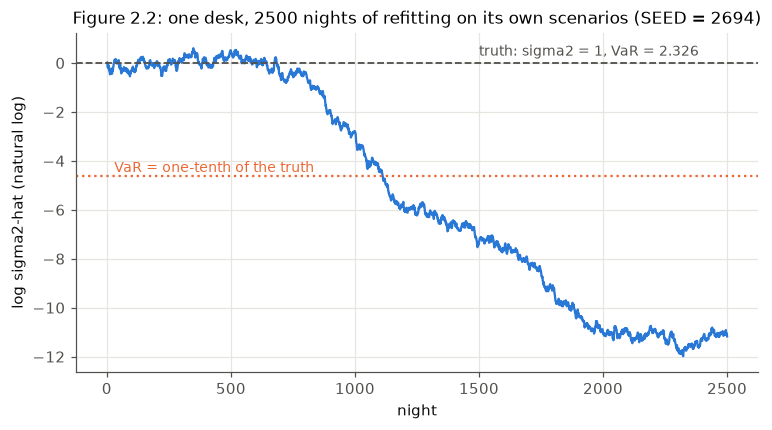

1,000 desks x 2500 nights simulated in 20.6 s


,sigma2-hat,reported VaR (sigma units),"VaR, % of NAV on the story scale"
mean,2.344,0.7749,0.9326
median,0.005851,0.1779,0.2142
5th percentile,2.885e-05,0.0125,0.01504
95th percentile,1.225,2.575,3.099
maximum,1566,92.05,110.8


mean reported VaR across desks: 0.775 sigma (the VaR at the mean sigma2-hat would be 3.56 sigma)
desks reporting VaR below one-tenth of the truth: 57.8% (Monte-Carlo SE 1.6%)
the one desk (sigma2-hat 1.405e-05) sits at percentile 3.2% of the 1,000 desks
the story's fall 2.8% -> 0.24% means sigma2-hat = 0.0073: percentile 52.7% (rounding band 51.5% to 53.3%); the median desk reports 0.214% of NAV


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# the plot colours of Problem 1, repeated so that Problem 2 also runs on its own
C_BLUE, C_ORANGE, C_AQUA = '#2a78d6', '#eb6834', '#1baf7a'
C_INK, C_GREY, C_LIGHT = '#0b0b0b', '#52514e', '#e6e5e1'

N_DESKS = 1000
STORY_VAR_START, STORY_VAR_END = 2.8, 0.24          # % of NAV, from the story

# One master seed, named independent streams: re-running any cell reproduces its numbers,
# and adding a stream at the end never changes the others.
STREAMS = ['one_desk', 'desks_1000', 'mart_s0_1', 'mart_s0_one', 'drift_50', 'drift_500', 'drift_5000',
           'drift_50_precise', 'mixed_real', 'mixed_synth', 'dj_scen', 'kurt_null', 'dj_boot']
_SS = dict(zip(STREAMS, np.random.SeedSequence(SEED).spawn(len(STREAMS))))
def rng_for(name):
    """A fresh generator on a named stream (the same numbers every time the cell is run)."""
    return np.random.default_rng(_SS[name])

def run_desks(n_desks, n_scen, nights, rng, s2_night1=1.0):
    """The manual's pipeline for many desks at once. Row k of the result is log sigma2-hat on night k+1.
    Night 1 fits the real library (sample variance s2_night1); every later night fits the previous night's scenarios."""
    log_s2 = np.empty((nights, n_desks))
    s2 = np.full(n_desks, float(s2_night1))
    log_s2[0] = np.log(s2)
    for k in range(1, nights):
        scen = rng.standard_normal((n_desks, n_scen)) * np.sqrt(s2)[:, None]   # (2) draw from N(0, s2): the scale is the SD
        s2 = scen.var(axis=1, ddof=1)                                          # (3) replace the library, (1) refit next night
        log_s2[k] = np.log(s2)
    return log_s2

# --- One desk, exactly as the manual reads ---
rng = rng_for('one_desk')
s2_one = np.empty(NIGHTS)
s2_one[0] = 1.0                                       # night 1: the real library has sample variance exactly 1
for k in range(1, NIGHTS):
    library = rng.normal(0.0, np.sqrt(s2_one[k - 1]), N_SCEN)   # (2) 500 scenarios from N(0, last fit); (3) they replace the library
    s2_one[k] = library.var(ddof=1)                             # (1) tonight's unbiased fit
var_one = Z01 * np.sqrt(s2_one)                                 # (4) reported VaR, in units of sigma

# the vectorised pipeline used below must reproduce this literal loop
assert np.allclose(np.log(s2_one), run_desks(1, N_SCEN, NIGHTS, rng_for('one_desk'))[:, 0], rtol=0, atol=1e-10)
print(f'one desk, night {NIGHTS}: sigma2-hat = {s2_one[-1]:.4g}, reported VaR = {var_one[-1]:.4f} sigma '
      f'(truth {Z01:.3f}), i.e. {STORY_VAR_START * np.sqrt(s2_one[-1]):.3f}% of NAV on the story\'s scale')

fig, ax = plt.subplots(figsize=(8, 4))
nights = np.arange(1, NIGHTS + 1)
ax.plot(nights, np.log(s2_one), color=C_BLUE, linewidth=1.5)
ax.axhline(0, color=C_GREY, linestyle='--', linewidth=1.2)
ax.text(1500, 0.3, 'truth: sigma2 = 1, VaR = 2.326', color=C_GREY, fontsize=9)
ax.axhline(np.log(0.01), color=C_ORANGE, linestyle=':', linewidth=1.5)
ax.text(30, np.log(0.01) + 0.15, 'VaR = one-tenth of the truth', color=C_ORANGE, fontsize=9)
ax.set_xlabel('night')
ax.set_ylabel('log sigma2-hat (natural log)')
ax.set_title(f'Figure 2.2: one desk, {NIGHTS} nights of refitting on its own scenarios (SEED = {SEED})')
plt.show()

t0 = time.perf_counter()
logS2 = run_desks(N_DESKS, N_SCEN, NIGHTS, rng_for('desks_1000'))     # (2500, 1000): every desk, every night
print(f'1,000 desks x {NIGHTS} nights simulated in {time.perf_counter() - t0:.1f} s')
assert logS2.shape == (NIGHTS, N_DESKS) and np.all(logS2[0] == 0) and np.isfinite(logS2).all()

S2_T = np.exp(logS2[-1])                                               # sigma2-hat on night 2,500, one per desk
low = (S2_T < 0.01).astype(float)                                       # VaR < truth/10  <=>  sigma-hat < 0.1
q5, q50, q95 = np.percentile(S2_T, [5, 50, 95])
tab22 = pd.DataFrame({'sigma2-hat': [S2_T.mean(), q50, q5, q95, S2_T.max()]},
                     index=['mean', 'median', '5th percentile', '95th percentile', 'maximum'])
tab22['reported VaR (sigma units)'] = Z01 * np.sqrt(tab22['sigma2-hat'])
tab22['VaR, % of NAV on the story scale'] = STORY_VAR_START * np.sqrt(tab22['sigma2-hat'])
# VaR rises with sigma2-hat, so the quantile rows are the VaR quantiles. The 'mean' row must be the mean VaR across desks,
# not the VaR at the mean sigma2-hat.
tab22.loc['mean', 'reported VaR (sigma units)'] = (Z01 * np.sqrt(S2_T)).mean()
tab22.loc['mean', 'VaR, % of NAV on the story scale'] = (STORY_VAR_START * np.sqrt(S2_T)).mean()
display(tab22.style.format('{:.4g}').set_caption(f'Table 2.2: night {NIGHTS} across {N_DESKS} desks'))
print(f'mean reported VaR across desks: {(Z01 * np.sqrt(S2_T)).mean():.3f} sigma '
      f'(the VaR at the mean sigma2-hat would be {Z01 * np.sqrt(S2_T.mean()):.2f} sigma)')
print(f'desks reporting VaR below one-tenth of the truth: {low.mean():.1%} '
      f'(Monte-Carlo SE {low.std(ddof=1) / np.sqrt(N_DESKS):.1%})')

pct_one = (S2_T < s2_one[-1]).mean()
story_s2 = (STORY_VAR_END / STORY_VAR_START) ** 2                        # VaR is proportional to sigma-hat
band = [(0.235 / 2.85) ** 2, (0.245 / 2.75) ** 2]                        # the story's numbers, allowing for rounding
print(f'the one desk (sigma2-hat {s2_one[-1]:.4g}) sits at percentile {pct_one:.1%} of the 1,000 desks')
print(f"the story's fall 2.8% -> 0.24% means sigma2-hat = {story_s2:.4f}: percentile {(S2_T < story_s2).mean():.1%} "
      f"(rounding band {(S2_T < band[0]).mean():.1%} to {(S2_T < band[1]).mean():.1%}); "
      f'the median desk reports {STORY_VAR_START * np.sqrt(q50):.3f}% of NAV')


**Answer:** (`SEED = 2694`; night 2,500 is 2,499 draw-and-refit steps after night 1's real library.)

**One desk (Figure 2.2).** Its $\log\hat\sigma^2$ wanders near 0 for a few hundred nights, then slides down. On night 2,500, $\hat\sigma^2$ = **1.405 × 10⁻⁵**, so the reported VaR is **0.0087σ** against a true 2.326σ: 0.010% of NAV on the story's scale instead of 2.8%.

**A thousand desks, night 2,500 (Table 2.2):**

| $\hat\sigma^2$ | mean | median | 5th pct | 95th pct | max |
|---|---|---|---|---|---|
| value | 2.344 | 0.00585 | 0.000029 | 1.225 | 1,566 |
| reported VaR (σ units) | 0.775 | 0.178 | 0.0125 | 2.575 | 92.1 |

The VaR mean is the average across desks, **0.775σ** (the VaR at the mean $\hat\sigma^2$, 3.56σ, is inflated by a few huge desks). **57.8%** of desks (Monte-Carlo SE 1.6%) report a VaR below one-tenth of the truth.

**Where the one desk sits:** at the **3.2nd percentile**, an unlucky left-tail desk, not a typical one.

**Is the story typical? Yes.** A fall from 2.8% to 0.24% of NAV means $\hat\sigma^2 = (0.24/2.8)^2 = 0.0073$, the **52.7th percentile** of the 1,000 desks (51.5% to 53.3% allowing for rounding); the median desk reports 0.214% of NAV. The story is this pipeline's median outcome, not bad luck, with an unchanged market and a correct estimator at every step.

**2.3.** (6 points) **Unbiased every night, wrong in the end.** Verify in a cell that
$E[\hat\sigma^2_{t+1} \mid \hat\sigma^2_t] = \hat\sigma^2_t$: start many desks at the same
$\hat\sigma^2_t$, take one step of the pipeline, and average. So the mathematically expected value
of $\hat\sigma^2$ on night 2,500 is exactly 1. Then measure the *average nightly change in
$\log\hat\sigma^2$* for $n = 50$, $500$ and $5{,}000$ scenarios per night (a few hundred desks and a
few hundred nights are enough) and propose the formula relating it to $n$; it is simple. Plot the
histogram of $\log\hat\sigma^2$ across your thousand desks on night 2,500.

In one paragraph, reconcile three numbers that are all correct: the expectation is exactly 1, your
median is far below 1, and your thousand-desk mean is neither (what share of the sum of your
thousand estimates is held by the ten largest?). Why does "unbiased at every step" not protect a
pipeline that trains on its own output?


,mean of sigma2_{t+1}/sigma2_t,SE,95% CI low,95% CI high,CI contains 1,t vs 1,two-sided p,median ratio,share of desks that go down,mean log ratio,SE of mean log ratio
start,,,,,,,,,,,
sigma2_t = 1 (night 1),0.99963,0.00014,0.99935,0.99991,False,-2.62,0.0088,0.99830,0.51078,-0.00238,0.00014
"sigma2_t = 1.405e-05 (the one desk, night 2500)",1.00009,0.00014,0.99981,1.00036,True,0.60,0.5454,0.99883,0.50744,-0.00192,0.00014


If the one-step property holds exactly, the chance that at least one of two independent starts gives p <= 0.0088 is 1.7%. The draws were not repeated to change this.


drift runs done in 26.3 s


,n,desks,nights,mean nightly change in log sigma2,SE,sd of one night's change,n x change,n x SE,t vs -1/n,t vs -1/(n-1),t vs 0
n = 50,50,500,500,-0.019788,0.000436,0.2040,-0.989,0.022,0.49,1.42,-45.4
n = 500,500,500,500,-0.002003,0.000132,0.0634,-1.002,0.066,-0.02,0.01,-15.1
"n = 5,000",5000,500,500,-0.000173,0.000040,0.0200,-0.866,0.202,0.67,0.67,-4.3
n = 50 (precise run),50,2000,2000,-0.020500,0.000103,0.2041,-1.025,0.005,-4.87,-0.90,-199.5
n = 500 (the 2.2 run),500,1000,2499,-0.002059,0.000042,0.0634,-1.029,0.021,-1.41,-1.31,-49.4


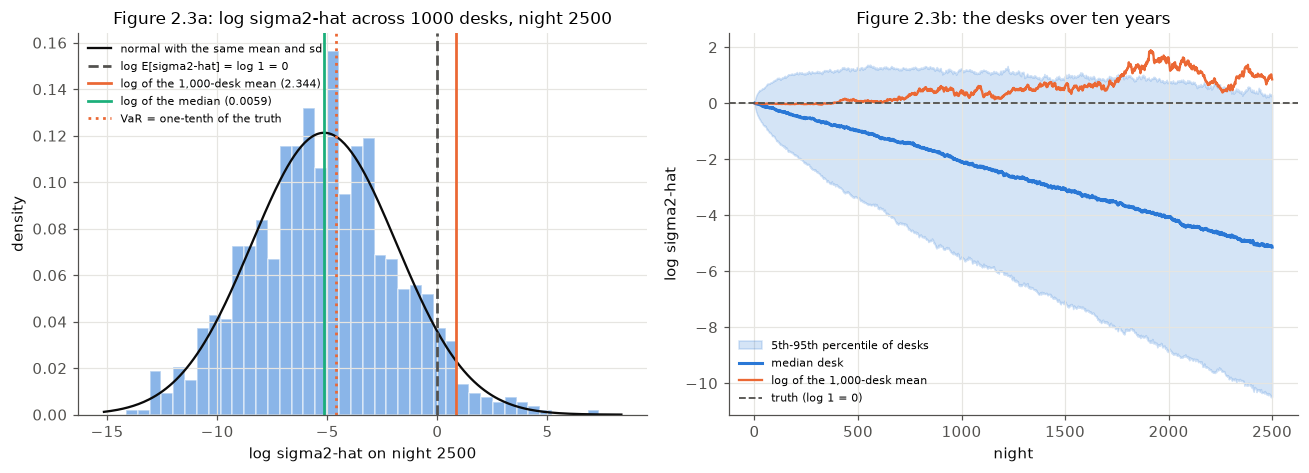

,value
"expectation of sigma2-hat on night 2,500 (exact, from the one-step property)",1
"median across the 1,000 desks",0.005851
"mean across the 1,000 desks",2.344
share of the sum held by the 10 largest desks,0.8879
share of the sum held by the largest desk,0.6681
share of desks with sigma2-hat above 1,0.059
mean of the other 999 desks (without the largest),0.7785
"largest desk, sigma2-hat",1566
"check: exp(2,499 x mean nightly change), vs the median",0.005832
"formula: exp(-2,499/(n-1)), the median the drift formula predicts",0.006684


,exact E[nightly change],-1/(n-1),-1/n,exact sd of one night's change,measured (Table 2.3b),n x exact
n,,,,,,
50,-0.020547,-0.020408,-0.020000,0.204109,-0.019788,-1.027349
500,-0.002005,-0.002004,-0.002000,0.063372,-0.002003,-1.002673
5000,-0.000200,-0.000200,-0.000200,0.020004,-0.000173,-1.000267


In [10]:
# E[sigma2_{t+1} | sigma2_t] = sigma2_t: start many desks at the same sigma2_t, take one step, average.
# Reporting rule fixed before running: "consistent with 1" if the 95% CI of the mean ratio contains 1.
# Even when the property holds exactly, each CI misses 1 about 5% of the time.
def one_step(s0, n_scen, m, rng, chunk=10_000):
    """m desks all starting at sigma2 = s0; one pipeline step; returns the m new fits."""
    out = np.empty(m)
    for i in range(0, m, chunk):
        c = min(chunk, m - i)
        out[i:i + c] = (rng.standard_normal((c, n_scen)) * np.sqrt(s0)).var(axis=1, ddof=1)
    return out

M = 200_000
rows = []
for stream, s0, label in [('mart_s0_1', 1.0, 'sigma2_t = 1 (night 1)'),
                          ('mart_s0_one', s2_one[-1], f'sigma2_t = {s2_one[-1]:.4g} (the one desk, night {NIGHTS})')]:
    ratio = one_step(s0, N_SCEN, M, rng_for(stream)) / s0
    se = ratio.std(ddof=1) / np.sqrt(M)
    tc = stats.t.ppf(0.975, M - 1)
    lr = np.log(ratio)
    rows.append({'start': label, 'mean of sigma2_{t+1}/sigma2_t': ratio.mean(), 'SE': se,
                 '95% CI low': ratio.mean() - tc * se, '95% CI high': ratio.mean() + tc * se,
                 'CI contains 1': (ratio.mean() - tc * se <= 1 <= ratio.mean() + tc * se),
                 't vs 1': (ratio.mean() - 1) / se, 'two-sided p': 2 * stats.t.sf(abs(ratio.mean() - 1) / se, M - 1),
                 'median ratio': np.median(ratio), 'share of desks that go down': (ratio < 1).mean(),
                 'mean log ratio': lr.mean(), 'SE of mean log ratio': lr.std(ddof=1) / np.sqrt(M)})
tab23a = pd.DataFrame(rows).set_index('start')
display(tab23a.style.format({**{c: '{:.5f}' for c in tab23a.columns if c != 'CI contains 1'}, 't vs 1': '{:.2f}', 'two-sided p': '{:.4f}'})
        .set_caption(f'Table 2.3a: one step of the pipeline from a fixed sigma2_t ({M:,} desks each, n = {N_SCEN})'))
p_min = tab23a['two-sided p'].min()
print(f'If the one-step property holds exactly, the chance that at least one of two independent starts '
      f'gives p <= {p_min:.4f} is {1 - (1 - p_min) ** 2:.1%}. The draws were not repeated to change this.')

# Average nightly change in log sigma2-hat for n = 50, 500, 5,000 scenarios per night.
# Reporting rule fixed before running: the formula is judged on how n x drift behaves across the three n.
DRIFT_DESIGN = {50: (500, 500), 500: (500, 500), 5000: (500, 500)}     # n: (desks, nights of change)
rows, t0 = [], time.perf_counter()
for n, (D, Tn) in DRIFT_DESIGN.items():
    L = run_desks(D, n, Tn + 1, rng_for(f'drift_{n}'))                 # row 0 is log 1 = 0
    per_desk = (L[-1] - L[0]) / Tn                                      # each desk's average nightly change
    inc_sd = np.diff(L, axis=0).std(ddof=1)
    rows.append({'n': n, 'desks': D, 'nights': Tn, 'mean nightly change in log sigma2': per_desk.mean(),
                 'SE': per_desk.std(ddof=1) / np.sqrt(D), 'sd of one night\'s change': inc_sd})
# a longer, larger run at n = 50, where the candidates -1/n and -1/(n-1) differ the most
L = run_desks(2000, 50, 2001, rng_for('drift_50_precise'))
per_desk = (L[-1] - L[0]) / 2000
rows.append({'n': 50, 'desks': 2000, 'nights': 2000, 'mean nightly change in log sigma2': per_desk.mean(),
             'SE': per_desk.std(ddof=1) / np.sqrt(2000), 'sd of one night\'s change': np.diff(L, axis=0).std(ddof=1)})
# cross-check at n = 500 from the 2.2 run (1,000 desks x 2,499 nights of change)
per_desk = (logS2[-1] - logS2[0]) / (NIGHTS - 1)
rows.append({'n': 500, 'desks': N_DESKS, 'nights': NIGHTS - 1, 'mean nightly change in log sigma2': per_desk.mean(),
             'SE': per_desk.std(ddof=1) / np.sqrt(N_DESKS), 'sd of one night\'s change': np.diff(logS2, axis=0).std(ddof=1)})
tab23b = pd.DataFrame(rows, index=['n = 50', 'n = 500', 'n = 5,000', 'n = 50 (precise run)', 'n = 500 (the 2.2 run)'])
tab23b['n x change'] = tab23b['n'] * tab23b['mean nightly change in log sigma2']
tab23b['n x SE'] = tab23b['n'] * tab23b['SE']
tab23b['t vs -1/n'] = (tab23b['mean nightly change in log sigma2'] + 1 / tab23b['n']) / tab23b['SE']
tab23b['t vs -1/(n-1)'] = (tab23b['mean nightly change in log sigma2'] + 1 / (tab23b['n'] - 1)) / tab23b['SE']
tab23b['t vs 0'] = tab23b['mean nightly change in log sigma2'] / tab23b['SE']
print(f'drift runs done in {time.perf_counter() - t0:.1f} s')
display(tab23b.style.format({'mean nightly change in log sigma2': '{:.6f}', 'SE': '{:.6f}',
                             "sd of one night's change": '{:.4f}', 'n x change': '{:.3f}', 'n x SE': '{:.3f}',
                             't vs -1/n': '{:.2f}', 't vs -1/(n-1)': '{:.2f}', 't vs 0': '{:.1f}'})
        .set_caption('Table 2.3b: average nightly change in log sigma2-hat, by scenarios per night'))

# Figure 2.3: the night-2,500 cross-section on the log scale (left) and how it got there (right)
x_T = logS2[-1]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.hist(x_T, bins=40, density=True, color=C_BLUE, alpha=0.55, edgecolor='white')
grid = np.linspace(x_T.min() - 1, x_T.max() + 1, 300)
ax1.plot(grid, stats.norm.pdf(grid, x_T.mean(), x_T.std(ddof=1)), color=C_INK, linewidth=1.5, label='normal with the same mean and sd')
for val, col, ls, lab in [(0.0, C_GREY, '--', 'log E[sigma2-hat] = log 1 = 0'),
                          (np.log(S2_T.mean()), C_ORANGE, '-', f'log of the 1,000-desk mean ({S2_T.mean():.3f})'),
                          (np.log(np.median(S2_T)), C_AQUA, '-', f'log of the median ({np.median(S2_T):.4f})'),
                          (np.log(0.01), C_ORANGE, ':', 'VaR = one-tenth of the truth')]:
    ax1.axvline(val, color=col, linestyle=ls, linewidth=1.8, label=lab)
ax1.set_xlabel(f'log sigma2-hat on night {NIGHTS}')
ax1.set_ylabel('density')
ax1.set_title(f'Figure 2.3a: log sigma2-hat across {N_DESKS} desks, night {NIGHTS}')
ax1.legend(fontsize=7.5, loc='upper left')

q = np.percentile(logS2, [5, 50, 95], axis=1)
ax2.fill_between(nights, q[0], q[2], color=C_BLUE, alpha=0.2, label='5th-95th percentile of desks')
ax2.plot(nights, q[1], color=C_BLUE, label='median desk')
ax2.plot(nights, np.log(np.exp(logS2).mean(axis=1)), color=C_ORANGE, linewidth=1.5, label='log of the 1,000-desk mean')
ax2.axhline(0, color=C_GREY, linestyle='--', linewidth=1.2, label='truth (log 1 = 0)')
ax2.set_xlabel('night')
ax2.set_ylabel('log sigma2-hat')
ax2.set_title('Figure 2.3b: the desks over ten years')
ax2.legend(fontsize=7.5, loc='lower left')
plt.tight_layout()
plt.show()

# Reconciling the three numbers
srt = np.sort(S2_T)[::-1]
drift_500 = tab23b.loc['n = 500 (the 2.2 run)', 'mean nightly change in log sigma2']
sd_inc = tab23b.loc['n = 500 (the 2.2 run)', "sd of one night's change"]
tab23c = pd.Series({
    'expectation of sigma2-hat on night 2,500 (exact, from the one-step property)': 1.0,
    'median across the 1,000 desks': np.median(S2_T),
    'mean across the 1,000 desks': S2_T.mean(),
    'share of the sum held by the 10 largest desks': srt[:10].sum() / srt.sum(),
    'share of the sum held by the largest desk': srt[0] / srt.sum(),
    'share of desks with sigma2-hat above 1': (S2_T > 1).mean(),
    'mean of the other 999 desks (without the largest)': srt[1:].mean(),
    'largest desk, sigma2-hat': srt[0],
    'check: exp(2,499 x mean nightly change), vs the median': np.exp((NIGHTS - 1) * drift_500),
    'formula: exp(-2,499/(n-1)), the median the drift formula predicts': np.exp(-(NIGHTS - 1) / (N_SCEN - 1)),
    'check: sqrt(2,499) x sd of one night\'s change, vs sd of log sigma2-hat': np.sqrt(NIGHTS - 1) * sd_inc,
    'sd of log sigma2-hat across desks on night 2,500': x_T.std(ddof=1)}, name='value')
display(tab23c.to_frame().style.format('{:.4g}').set_caption('Table 2.3c: three correct numbers'))

# SUPPLEMENTARY - beyond the lectures (the chi-square law of s2 and the digamma function are not taught).
# The formula in 2.3 is established by the measurements above; this cell only checks them against theory.
# Given sigma2_t, (n-1) sigma2_{t+1} / sigma2_t ~ chi-square(n-1), so the nightly factor is chi2_k / k with k = n - 1:
# its mean is exactly 1 (the martingale) and E[log(chi2_k / k)] = digamma(k/2) - log(k/2), approximately -1/k.
from scipy.special import digamma, polygamma
theory = pd.DataFrame({'n': [50, 500, 5000]})
k = theory.n - 1
theory['exact E[nightly change]'] = digamma(k / 2) - np.log(k / 2)
theory['-1/(n-1)'] = -1 / k
theory['-1/n'] = -1 / theory.n
theory['exact sd of one night\'s change'] = np.sqrt(polygamma(1, k / 2))
theory['measured (Table 2.3b)'] = tab23b.loc[['n = 50', 'n = 500', 'n = 5,000'], 'mean nightly change in log sigma2'].to_numpy()
theory['n x exact'] = theory.n * theory['exact E[nightly change]']
display(theory.set_index('n').style.format('{:.6f}').set_caption('Supplementary: theory vs measurement'))


**Answer:**

**One step from a fixed $\hat\sigma^2_t$ (Table 2.3a).** 200,000 desks started at the same $\hat\sigma^2_t$ and each took one step of the pipeline:

| start | mean of $\hat\sigma^2_{t+1}/\hat\sigma^2_t$ | 95% CI | contains 1? |
|---|---|---|---|
| $\hat\sigma^2_t = 1$ | 0.99963 | 0.99935 – 0.99991 | no (t = −2.62, p = 0.0088) |
| $\hat\sigma^2_t = 1.405\times10^{-5}$ | 1.00009 | 0.99981 – 1.00036 | yes |

The rule fixed before running was "consistent with 1 if the CI contains 1". The second start passes; the first misses narrowly (a 1.7% chance at one of two starts if the property holds exactly; the draws were not repeated). The `ddof=1` variance is exactly unbiased (L2 p.56–57), so this is a Monte-Carlo miss, and chaining the one-step property makes the expected $\hat\sigma^2$ on night 2,500 exactly 1.

**Average nightly change in $\log\hat\sigma^2$ (Table 2.3b):**

| n | mean nightly change (SE) | n × change (SE) |
|---|---|---|
| 50 | −0.01979 (0.00044) | −0.99 (0.02) |
| 500 | −0.00200 (0.00013) | −1.00 (0.07) |
| 5,000 | −0.000173 (0.000040) | −0.87 (0.20) |
| 50, precise run (2,000 desks × 2,000 nights) | −0.02050 (0.00010) | −1.025 (0.005) |
| 500, the 2.2 run (1,000 desks × 2,499 nights) | −0.002059 (0.000042) | −1.03 (0.02) |

**The formula: the average nightly change in $\log\hat\sigma^2$ is about $-1/(n-1) \approx -1/n$.** n × change is −1 within Monte-Carlo error across two orders of magnitude of n, and the drift is non-zero even at n = 5,000 (t = −4.3). Only the precise n = 50 run separates the two candidates: 4.9 SE from −1/n, 0.9 SE from −1/(n−1). (A supplementary cell checks this against theory beyond the lectures.)

**Reconciliation (Figure 2.3, Table 2.3c).** The expectation of $\hat\sigma^2$ on night 2,500 is exactly **1**, the median desk is at **0.0059** (a VaR of 0.18σ), and the 1,000-desk mean is **2.34**, of which the 10 largest desks hold **88.8%** and the largest alone ($\hat\sigma^2$ = 1,566) 66.8%; the other 999 average 0.78 and only 5.9% of desks end above 1. Each night multiplies $\hat\sigma^2$ by a random factor with mean exactly 1 but median below 1, so in logs every desk is a random walk drifting about −1/n per night (our construction): after 2,499 nights the formula puts the median near exp(−2,499/499) = 0.0067 (measured 0.0059), and the spread grows like $\sqrt{\text{nights}}$ (predicted sd 3.17, observed 3.29). The expectation stays at 1 only because a vanishing minority of desks drifts up enormously; 1,000 desks catch such a desk only now and then, so their mean is neither 1 nor the median (one desk at 1,566 lifts it from 0.78 to 2.34). "Unbiased at every step" does not protect the pipeline because unbiasedness controls only the *mean* of tomorrow's estimate, not its typical value (L2 p.71–72): after night 1 no new information about σ enters the library, so each night's estimation error becomes the next night's truth and the errors compound multiplicatively, sending the typical desk's VaR toward zero while the expectation, correctly, stays at 1. Against my 2.1 prediction, the Jensen argument, the drift of about −1/(n−1) (−0.00206 per night at n = 500, against −0.00200) and the collapse of the typical desk's VaR were confirmed, but the claim that the 1,000-bank average "should remain approximately 1.0" was only half right: the *expectation* is exactly 1, but the 1,000-desk average is 2.34 (0.78 without its largest desk).

**2.4.** (6 points) **What synthetic data can and cannot carry.** Two experiments.

(a) Keep the 500 real days in the library permanently, and add each night's 500 scenarios to them
instead of replacing them, so the library holds 1,000 returns, half real and half synthetic. Report the median and the 5th and 95th percentiles of $\hat\sigma^2$ on
night 2,500 across a thousand desks.

(b) Seed the library with real returns instead. `dj30.csv` is a daily panel of Dow stocks, one row
per stock per date, and the daily market return `MrkRet` is repeated on every row for that date;
reduce it to one value per date (for example `dj.groupby('date').MrkRet.first()`), which gives 1,511
trading days for 2016–2021 including March 2020. Report the sample volatility and the excess
kurtosis of the real returns. Then compare two things *on night 1, before the pipeline has drawn a
single scenario from its own output*: the empirical 1% VaR (the first percentile of the real
returns, sign flipped) against the VaR the pipeline reports, and the excess kurtosis of the real
returns against that of the 500 night-1 scenarios.

Then answer in one paragraph. What does a synthetic sample contain that the real sample did not,
and what does it lack? Which of the two experiments shows a *loss of information* and which shows
an *accumulation of noise*? What does this imply for any pipeline, a risk model, a return forecast
or a language model, that is retrained on data produced by its own previous version, and what is the
only thing that stops it?


anchored runs done in 48.4 s


,median,5th percentile,95th percentile,mean,share with VaR < truth/10
replace (2.2),0.005851,2.885e-05,1.225,2.344,0.578
keep the real days (2.4a),0.9955,0.9406,1.059,0.9974,0
"keep the real days, demeaned (robustness)",0.9946,0.9398,1.058,0.9963,0


,5th percentile,median,95th percentile
night 1,1.0000,1.0000,1.0000
night 2,0.9509,0.9982,1.0520
night 3,0.9426,0.9985,1.0628
night 5,0.9426,0.9983,1.0582
night 10,0.9435,0.9983,1.0582
night 100,0.9425,0.9990,1.0603
night 1000,0.9377,1.0006,1.0635
night 2500,0.9406,0.9955,1.0586


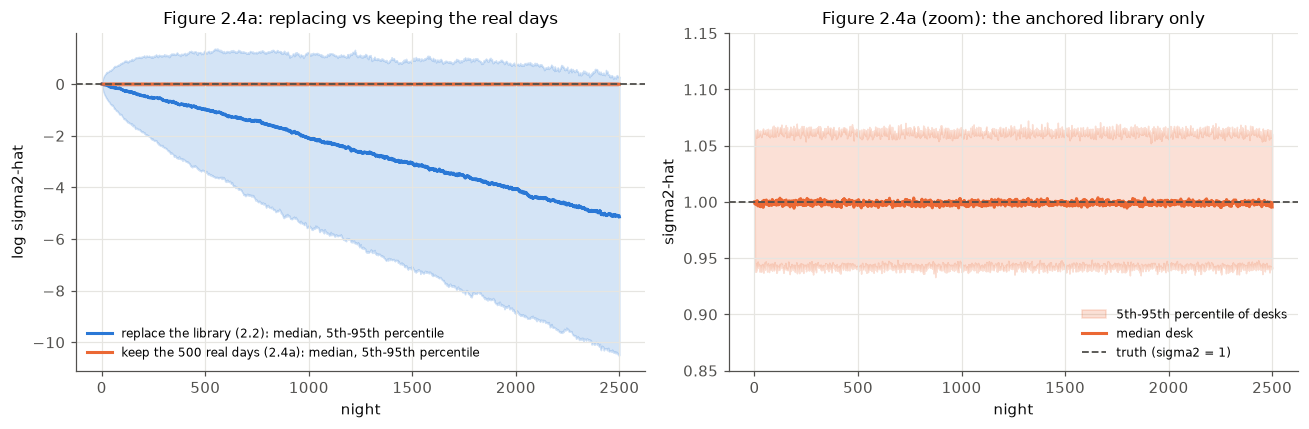

(46445, 9)
Unnamed: 0      int64
PERMNO          int64
date            int64
TICKER            str
COMNAM            str
PERMCO          int64
PRC           float64
RET           float64
MrkRet        float64
1511 trading days, 20160104 to 20211231


,value
"daily volatility of the real returns (sd, ddof=1)",0.011951
excess kurtosis of the real returns (scipy default),24.075
"excess kurtosis, bias-corrected (for reference)",24.159
"night-1 VaR the pipeline reports, 2.326 x sd",0.027803
"empirical 1% VaR (first percentile, sign flipped)",0.03325
"empirical VaR with other percentile rules (low, high)","0.03169, 0.03342"
empirical VaR / sd (normal model says 2.326),2.7821
resampling SE of the empirical VaR,0.0037634
resampling SE of the pipeline VaR,0.0018277
resampling SE of the difference,0.003203


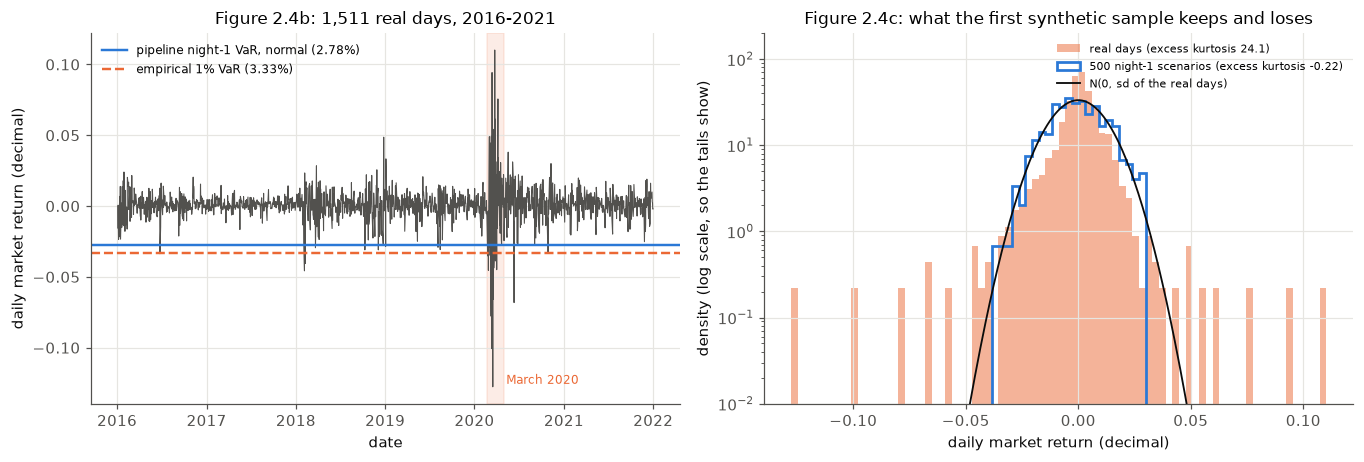

In [11]:
# (a) Each desk keeps its own 500 real days permanently; every night the library is those 500 plus tonight's
# 500 scenarios (1,000 returns); last night's scenarios are replaced. Night 1 fits the real days alone.
Z = rng_for('mixed_real').standard_normal((N_DESKS, N_SCEN))
real = Z / Z.std(axis=1, ddof=1, keepdims=True)                       # rescaled so each desk's sample variance is exactly 1
real_dm = (Z - Z.mean(axis=1, keepdims=True)) / Z.std(axis=1, ddof=1, keepdims=True)   # robustness: also demeaned
assert np.allclose(real.var(axis=1, ddof=1), 1) and np.allclose(real_dm.var(axis=1, ddof=1), 1)

def run_mixed(real_days, nights, rng):
    """The anchored pipeline: library = the desk's fixed real days + tonight's scenarios."""
    log_s2 = np.empty((nights, real_days.shape[0]))
    s2 = real_days.var(axis=1, ddof=1)                                 # night 1: real days only
    log_s2[0] = np.log(s2)
    for k in range(1, nights):
        scen = rng.standard_normal(real_days.shape) * np.sqrt(s2)[:, None]    # N(0, s2): the fitted mean is set to zero
        s2 = np.concatenate([real_days, scen], axis=1).var(axis=1, ddof=1)    # half real, half synthetic
        log_s2[k] = np.log(s2)
    return log_s2

t0 = time.perf_counter()
logS2_mix = run_mixed(real, NIGHTS, rng_for('mixed_synth'))
logS2_mix_dm = run_mixed(real_dm, NIGHTS, rng_for('mixed_synth'))       # same synthetic draws, demeaned real days
print(f'anchored runs done in {time.perf_counter() - t0:.1f} s')
assert np.isfinite(logS2_mix).all() and np.isfinite(logS2_mix_dm).all()

def summary(ls2):
    s2 = np.exp(ls2)
    p5, p50, p95 = np.percentile(s2, [5, 50, 95])
    return {'median': p50, '5th percentile': p5, '95th percentile': p95, 'mean': s2.mean(),
            'share with VaR < truth/10': (s2 < 0.01).mean()}
tab24a = pd.DataFrame({'replace (2.2)': summary(logS2[-1]),
                       'keep the real days (2.4a)': summary(logS2_mix[-1]),
                       'keep the real days, demeaned (robustness)': summary(logS2_mix_dm[-1])}).T
display(tab24a.style.format('{:.4g}').set_caption(f'Table 2.4a: sigma2-hat on night {NIGHTS} across {N_DESKS} desks'))
stab = pd.DataFrame({f'night {t}': summary(logS2_mix[t - 1]) for t in [1, 2, 3, 5, 10, 100, 1000, NIGHTS]}).T
display(stab[['5th percentile', 'median', '95th percentile']].style.format('{:.4f}')
        .set_caption('Table 2.4a (cont.): the anchored library over time'))

fig, (ax, axz) = plt.subplots(1, 2, figsize=(12, 4))
for ls2, col, lab in [(logS2, C_BLUE, 'replace the library (2.2)'), (logS2_mix, C_ORANGE, 'keep the 500 real days (2.4a)')]:
    qq = np.percentile(ls2, [5, 50, 95], axis=1)
    ax.fill_between(nights, qq[0], qq[2], color=col, alpha=0.2)
    ax.plot(nights, qq[1], color=col, label=f'{lab}: median, 5th-95th percentile')
ax.axhline(0, color=C_GREY, linestyle='--', linewidth=1.2)
ax.set_xlabel('night')
ax.set_ylabel('log sigma2-hat')
ax.set_title('Figure 2.4a: replacing vs keeping the real days')
ax.legend(fontsize=8, loc='lower left')
qq = np.percentile(np.exp(logS2_mix), [5, 50, 95], axis=1)
axz.fill_between(nights, qq[0], qq[2], color=C_ORANGE, alpha=0.2, label='5th-95th percentile of desks')
axz.plot(nights, qq[1], color=C_ORANGE, label='median desk')
axz.axhline(1, color=C_GREY, linestyle='--', linewidth=1.2, label='truth (sigma2 = 1)')
axz.set_ylim(0.85, 1.15)
axz.set_xlabel('night')
axz.set_ylabel('sigma2-hat')
axz.set_title('Figure 2.4a (zoom): the anchored library only')
axz.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

# (b) Seed the library with real returns: the daily market return of the Dow panel, one value per date
dj = pd.read_csv(_DATA_DIR + 'dj30.csv')
print(dj.shape)
print(dj.dtypes.to_string())
assert dj.groupby('date').MrkRet.nunique().max() == 1 and dj.MrkRet.notna().all()   # MrkRet repeats within a date
r = dj.groupby('date').MrkRet.first()
assert len(r) == 1511 and r.index.is_monotonic_increasing
print(f'{len(r)} trading days, {r.index.min()} to {r.index.max()}')

sd_real = r.std(ddof=1)                               # daily sample volatility
kurt_real = kurtosis(r)                               # scipy default: excess kurtosis (fisher=True), bias=True
# Night 1, before the pipeline has drawn a single scenario: the library is the 1,511 real days
var_pipe = Z01 * sd_real                              # steps (1) and (4): sigma-hat from var(ddof=1), mean set to zero
var_emp = -np.percentile(r, 1)                        # the first percentile of the real returns, sign flipped (linear interpolation)
var_emp_lo, var_emp_hi = -np.percentile(r, 1, method='higher'), -np.percentile(r, 1, method='lower')
scen1 = rng_for('dj_scen').normal(0.0, sd_real, N_SCEN)   # step (2): the 500 night-1 scenarios
kurt_scen = kurtosis(scen1)

# Reference: excess kurtosis of 10,000 samples of 500 from a normal (what a normal sample of this size shows)
K0 = kurtosis(rng_for('kurt_null').standard_normal((10_000, N_SCEN)), axis=1)
k_lo, k_med, k_hi = np.percentile(K0, [2.5, 50, 97.5])

# Resampling the real days (L2 p.80): how precisely are the two VaRs estimated? (iid days - see the caveat in the answer)
rb, B = rng_for('dj_boot'), 10_000
emp_b, pipe_b = np.empty(B), np.empty(B)
rv_all = r.to_numpy()
for i in range(0, B, 500):
    rv = rv_all[rb.integers(0, len(rv_all), size=(500, len(rv_all)))]
    emp_b[i:i + 500] = -np.percentile(rv, 1, axis=1)
    pipe_b[i:i + 500] = Z01 * rv.std(axis=1, ddof=1)

tab24b = pd.Series({
    'daily volatility of the real returns (sd, ddof=1)': sd_real,
    'excess kurtosis of the real returns (scipy default)': kurt_real,
    'excess kurtosis, bias-corrected (for reference)': kurtosis(r, bias=False),
    'night-1 VaR the pipeline reports, 2.326 x sd': var_pipe,
    'empirical 1% VaR (first percentile, sign flipped)': var_emp,
    'empirical VaR with other percentile rules (low, high)': f'{var_emp_lo:.5f}, {var_emp_hi:.5f}',
    'empirical VaR / sd (normal model says 2.326)': var_emp / sd_real,
    'resampling SE of the empirical VaR': emp_b.std(ddof=1),
    'resampling SE of the pipeline VaR': pipe_b.std(ddof=1),
    'resampling SE of the difference': (emp_b - pipe_b).std(ddof=1),
    'empirical minus pipeline VaR (percentage points)': 100 * (var_emp - var_pipe),
    'difference / its resampling SE': (var_emp - var_pipe) / (emp_b - pipe_b).std(ddof=1),
    'mean daily return, % (the pipeline sets it to 0)': 100 * r.mean(),
    'share of real days with a loss beyond the pipeline VaR (normal model: 1%)': (r < -var_pipe).mean(),
    'excess kurtosis of the 500 night-1 scenarios': kurt_scen,
    'normal samples of 500: 2.5th / 50th / 97.5th percentile of excess kurtosis': f'{k_lo:.3f} / {k_med:.3f} / {k_hi:.3f}',
    'normal samples of 500: largest excess kurtosis in 10,000': K0.max(),
    'share of the 10,000 normal samples at or above the real kurtosis': (K0 >= kurt_real).mean()}, name='value')
display(tab24b.to_frame().style.format(lambda v: v if isinstance(v, str) else f'{v:.5g}')
        .set_caption('Table 2.4b: real returns vs the pipeline on night 1'))

# Figure 2.4b: the real returns with both night-1 VaRs (left); real days vs the night-1 scenarios (right)
dates = pd.to_datetime(r.index.astype(str), format='%Y%m%d')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax1.plot(dates, r.to_numpy(), color=C_GREY, linewidth=0.7)
ax1.axhline(-var_pipe, color=C_BLUE, linewidth=1.6, label=f'pipeline night-1 VaR, normal ({var_pipe:.2%})')
ax1.axhline(-var_emp, color=C_ORANGE, linewidth=1.6, linestyle='--', label=f'empirical 1% VaR ({var_emp:.2%})')
ax1.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'), color=C_ORANGE, alpha=0.12)
ax1.text(pd.Timestamp('2020-05-10'), r.min(), 'March 2020', color=C_ORANGE, fontsize=8, va='bottom')
ax1.set_xlabel('date')
ax1.set_ylabel('daily market return (decimal)')
ax1.set_title('Figure 2.4b: 1,511 real days, 2016-2021')
ax1.legend(fontsize=8, loc='upper left')

bins = np.linspace(r.min(), r.max(), 81)
ax2.hist(r, bins=bins, density=True, color=C_ORANGE, alpha=0.5, label=f'real days (excess kurtosis {kurt_real:.1f})')
ax2.hist(scen1, bins=bins, density=True, histtype='step', color=C_BLUE, linewidth=1.8,
         label=f'500 night-1 scenarios (excess kurtosis {kurt_scen:.2f})')
g = np.linspace(r.min(), r.max(), 400)
ax2.plot(g, stats.norm.pdf(g, 0, sd_real), color=C_INK, linewidth=1.2, label='N(0, sd of the real days)')
ax2.set_yscale('log')
ax2.set_ylim(1e-2, 2e2)
ax2.set_xlabel('daily market return (decimal)')
ax2.set_ylabel('density (log scale, so the tails show)')
ax2.set_title('Figure 2.4c: what the first synthetic sample keeps and loses')
ax2.legend(fontsize=7.5, loc='upper right')
plt.tight_layout()
plt.show()

**Answer:**

**(a) Keep the 500 real days (Table 2.4a, Figure 2.4a).** On night 2,500 the median $\hat\sigma^2$ is **0.9955**, the 5th percentile **0.9406** and the 95th percentile **1.059** (with replacement, 2.2: 0.0059, 0.000029 and 1.225). No desk reports a VaR below one-tenth of the truth. The band is in place by night 3 and stays there; demeaning the real days changes nothing that matters (median 0.9946).

**(b) Seed with real returns (Table 2.4b, Figures 2.4b and 2.4c).** The 1,511 daily market returns of 2016–2021 have a sample volatility of **1.195% a day** (`std(ddof=1)`) and an excess kurtosis of **24.1** (scipy default; 24.2 bias-corrected), against 0 for a normal. On night 1, before any synthetic draw (the library is all 1,511 real days):
- **VaR.** The pipeline reports **2.78%** of NAV (2.326 × 1.195%, the story's 2.8%); the empirical 1% VaR is **3.33%** (3.17% to 3.34% under other percentile rules), 2.78 standard deviations rather than 2.326. The normal model understates the 1-in-100 loss by 0.54 percentage points, 1.7 resampling SEs (SE 0.32 pp): suggestive rather than decisive, and optimistic because iid resampling ignores volatility clustering (our caveat). Losses beyond the pipeline's VaR occur on 1.65% of real days, not 1%.
- **Kurtosis, the decisive evidence.** The **500 night-1 scenarios have an excess kurtosis of −0.22**, inside the range of normal samples of 500 (95% of 10,000 fall between −0.38 and 0.46); the real **24.1** is far above the largest of those 10,000, 1.51.

**What synthetic data can and cannot carry.** A synthetic sample *contains* only the fitted model (a normal with zero mean and one constant variance at $\hat\sigma$, whose estimation error is now treated as the truth) plus fresh random noise. It *lacks* any new information about the world and everything the model threw away: the fat tails (kurtosis 24.1 becomes −0.22), the March-2020 cluster, the empirical 1% quantile (3.33% rather than 2.78%) and the mean of 0.064% a day. **(b) shows a loss of information**: before any feedback, the first synthetic sample has already lost the tails, and they never return because every later generation is drawn from a normal; simulating from the fitted model "assumed what the formula assumes" (L2 p.80). **(a) shows an accumulation of noise**: the model is right and the information sits in the 500 real days, so the synthetic half adds only estimation noise, which stays in a stable band (0.94–1.06) because the real half pulls every fit back; without that anchor, as in 2.2, the same noise compounds into a drifting random walk that ends in collapse. So any pipeline retrained on its own previous version's output, whether a risk model, a return forecast or a language model, first loses whatever the model cannot represent and then compounds each generation's estimation error, and being unbiased at every step does not stop the typical run from collapsing (2.3). The only thing that stops it is **real data from outside the model, kept in the training set at every generation** (in (a) the same 500 original days are enough), which requires tracking where the data came from; real data stops the accumulation of noise, but getting the tails back in (b) needs a better model, not more of its own output.

---
# Problem 3: Research Project — Cross-country asset return prediction (60 points)

This is an open-ended research project rather than a problem set. You are given a research panel of monthly asset returns across several countries and asset classes, with asset-level characteristics and macroeconomic data, and a question. How you answer it — which features you build, which models you fit, how you evaluate them — is your design, and the write-up must defend it. There is no answer key. A negative result, honestly established, earns full credit; an unexplained positive one does not.

**The question.** The empirical asset-pricing literature finds that a small set of asset-level characteristics — variables that describe each asset's own recent behaviour, pricing and risk, and that differ across assets at a point in time — predict returns across many markets and asset classes, and systematic funds trade on exactly these cross-sectional signals. The panel you are given carries five such characteristics per asset, with their names hidden, together with global and country-level macro variables. What a desk that trades across countries and asset classes wants to know is:

1. How much of next month's excess return is forecastable from lagged characteristics?
2. Does macroeconomic information — global or country-level — add anything to the characteristics?
3. Does a forecast-based portfolio beat the simple rules (equal weight, risk parity, time-series momentum) out of sample, after costs?

Any method is allowed: OLS, ridge, lasso, PCR, KNN, trees, random forests, boosting, neural networks, or anything else you want to try; static, expanding-window or rolling-window estimation; cross-validation or information criteria for tuning. The choice is yours; the discipline of the evaluation is what is graded.


## Data

All files are in `_DATA_DIR`. Dates are month-ends, January 2000 to December 2024. Returns are monthly **excess** returns in decimals. Asset, asset-class, country and variable names are anonymized.

| file | grain | columns |
|---|---|---|
| `asset_panel.csv` | asset × month (50 × 300) | `date, asset_id, asset_class, country, excess_return, x1 ... x5` |
| `asset_returns_wide.csv` | month × asset | the same returns, one column per asset |
| `asset_info.csv` | asset | `asset_class` (A, B, C, D) and `country` of each asset |
| `macro_global.csv` | month | `x6 ... x9`, global variables |
| `macro_country.csv` | country × month, 12 countries | `x10 ... x16`, curated country-level variables |
| `macro_country_extended.csv` | country × month, 12 countries | `x17 ... x164`, a wide, uncurated set of further country-level variables that overlaps the curated file (a few of its columns duplicate curated series exactly; find them before you concatenate the two files). Treat as exploratory material of uneven quality |

**Universe.** 50 assets in four asset classes — A (26 assets), B (8), C (9) and D (7) — across 12 countries. Assets in classes B, C and D each belong to one country. **Assets in class A have no natural country**; in the files they are assigned `country_7` by convention (a country that also has one class-C and one class-D asset). If you use country-level macro for class A, the convention gives them country 7's variables, which is one defensible choice among several (see step 2 of the workflow); in a widened-panel design you can give them whatever cross-country information you find sensible.

**Variables.** `x1` to `x5` are cross-sectional asset characteristics: each is computed for every asset every month from that asset's own prices and fundamentals, so at any date it varies across assets and can be used to rank them (one of the five is a risk measure). `x6` to `x164` are macroeconomic and financial-condition variables: rates, inflation, activity, external balances, credit, valuation, uncertainty and risk ratings, and some pre-computed transforms of them. Working out what a variable does — from its persistence, its scale, its cross-sectional behaviour and its relation to returns — is part of the project.

**Read this before modelling.**
- **Lag conventions.** `x2` and `x5` are *already* lagged one month: use them as they are to predict `excess_return` in the same row. `x1`, `x3`, `x4` and **every macro variable** are stored *contemporaneously*: shift them by one month within asset (or country) before using them as predictors. Getting this wrong silently introduces look-ahead. Macro data is also released with a delay; a one-month lag is the minimum, and you may argue for more.
- **Missing values.** The asset panel and the global file have no gaps, but a few leading months of `x2`, `x3` and `x5` in 2000–2002 were filled with the first observed value for a handful of assets; returns were never filled. In the curated country file, `x11` stops being updated before the end of the sample for three countries. In the extended file, seven columns have gaps. If you want to use a series with gaps, you have to deal with them yourself (see step 2 of the workflow).
- **You are free to bring in more data.** If you think other macro series, other asset characteristics, or other information would help the prediction, find it, document its source and its release timing, and treat it as part of your feature engineering. Anything you add is subject to the same lag rules as the data we provide.
- **Scales differ enormously by class.** Monthly return volatility ranges from under 1% to above 17% across assets, and its typical level differs systematically across the four classes. Think about this before pooling assets in one regression or one equal-weighted portfolio.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
# _DATA_DIR = './'    # if the data files sit next to this notebook
import os
_DATA_DIR = _DATA_DIR if os.path.isdir(_DATA_DIR) else './'   # class server if present, else a local copy next to the notebook

panel = pd.read_csv(_DATA_DIR + 'asset_panel.csv', parse_dates=['date'])
info  = pd.read_csv(_DATA_DIR + 'asset_info.csv', index_col=0)
mac_g = pd.read_csv(_DATA_DIR + 'macro_global.csv', parse_dates=['date'])
mac_c = pd.read_csv(_DATA_DIR + 'macro_country.csv', parse_dates=['date'])
mac_x = pd.read_csv(_DATA_DIR + 'macro_country_extended.csv', parse_dates=['date'])
print(panel.shape, panel.date.min().date(), panel.date.max().date())
panel.head()

(15000, 10) 2000-01-31 2024-12-31


,date,asset_id,asset_class,country,excess_return,x1,x2,x3,x4,x5
0,2000-01-31,asset_1,A,country_7,0.035385,0.044852,0.970233,-0.109145,0.158469,0.086743
1,2000-02-29,asset_1,A,country_7,0.116676,0.073761,0.974766,-0.109145,0.133949,0.085443
2,2000-03-31,asset_1,A,country_7,0.040920,0.089627,0.922260,-0.109145,0.188675,0.086244
3,2000-04-30,asset_1,A,country_7,-0.008399,0.074356,1.055247,-0.109145,0.206628,0.085047
4,2000-05-31,asset_1,A,country_7,-0.086259,0.067134,0.788085,-0.109145,0.227556,0.083820


## Two rules that apply throughout

1. **Benchmarks before models.** Before you fit anything, write down the simple rules your model must beat and compute their out-of-sample performance. For return forecasts the benchmark is the trailing mean (or zero). For portfolios it is equal weight, risk parity ($w_i \propto 1/\hat\sigma_i$, with $\hat\sigma_i$ a trailing volatility computed from past returns) and time-series momentum ($w_i \propto \mathrm{sign}(\text{trailing 12-month return}_i)/\hat\sigma_i$), all with unit gross exposure and monthly rebalancing. All three can be built from `excess_return` alone.
2. **Time-ordered evaluation.** Fix the out-of-sample window and the initial training block in advance, before you fit anything, and say why you chose them. Every predictor must be known at the end of month $t-1$; every scaler, penalty and hyper-parameter is chosen on training data only; the trailing-mean benchmark for month $t$ is the mean of returns through month $t-1$ only, updated each month (the expanding-window harness of HW5 Problem 1.1, where the $R^2$ benchmark is the mean of the data seen so far).


## A suggested workflow

You do not have to follow this order, but a complete project touches each step.

**1. Know your data.** Cumulative excess returns by asset class; a table of annualized mean, volatility, Sharpe ratio and worst month per asset; the correlation matrix ordered by class (how strong is the block structure, and what does it imply for pooling?); rolling 12-month Sharpe by class (how persistent is performance?); the distribution, scale and persistence of each characteristic within each class, and a first look at its predictive content (average next-month return of assets sorted into terciles on it each month). Form a hypothesis about what each of `x1` to `x5` measures; you will need it to interpret your results.

**2. Feature engineering.** This is where most of the design lives.
- Apply the lag rule. Standardize characteristics cross-sectionally within month (across all assets or within class; z-score or rank) and say why.
- **If you use a macro series with missing values, deal with them first and write down what you did.** Diagnose the pattern for each series and country: does it stop early, or have holes in the middle? Then choose a treatment and justify that it uses *only information available at the time*. Forward-filling the last observed value and dropping the series are legitimate; filling backward, interpolating across a gap, or imputing with a full-sample mean all use the future. One trap worth your attention: a series that stops updating during a regime change, where carrying a stale value forward is not a small error. Check whether the series can be rebuilt, exactly or approximately, from other complete columns in either file, and report how close the rebuild is.
- **Add your own data if you have a hypothesis for it.** More macro series, other characteristics, anything you can source and date properly. Say where it came from, when each value became known, and lag it accordingly.
- Standardize global macro with *trailing* information only (a rolling z-score, for instance), never with the full sample.
- Map country macro to assets through `country`. Classes B, C and D each have their own country, so the mapping is direct; a *differential* against a base country (country 7 is the natural base) is often more informative than a level. Class A has no natural country. The files assign it country 7 by convention, and using country 7's macro for class A is one defensible choice; a cross-country average, cross-country dispersion, or no country macro at all are others. Say which you use and why.
- Consider cross-sectional macro transforms: the rank of a country's value across the 12 countries, its deviation from the cross-country mean, or a widened panel in which each asset sees its own country's macro *and* the cross-country average or every country's value. In the widened panel, class A can be given any cross-country information you find sensible rather than one country's.
- Consider interactions between characteristics and macro states, class dummies, and the extended file if you have a hypothesis for it.
- Choose the target. We recommend the **vol-scaled** excess return $y_{i,t} = r_{i,t}/\hat\sigma_{i,t-1}$ with $\hat\sigma$ a trailing volatility; explain why, and how you turn forecasts back into positions.
- End with one table listing every predictor and the count.

**3. Models and evaluation schemes.** Fit whatever models you find promising — OLS, ridge, lasso, random forests, boosted trees, neural networks, or any other method — and evaluate them under one or more schemes: static (fit once on the initial training block), expanding window (refit periodically on all data to date, the expanding-window scheme of Lecture 5 that you implemented in HW5 Problem 1), rolling window (refit on a fixed-length trailing window). Report $R^2_{OOS}$ against the trailing mean and against zero, model × scheme, and by asset class for the models you care about. Questions worth answering along the way: which scheme wins and why; which predictors carry the signal and whether that is stable across windows; whether macro adds anything once you refit without it; whether a **placebo** (every macro series circularly shifted by 36 months, real data at the wrong time) does about as well as the real macro (a persistent series stays partly correlated with a shifted copy of itself, so try more than one shift); whether per-class models beat the pooled one.

**4. From forecasts to portfolios.** Form portfolios from your forecasts in whatever way you find sensible (positions proportional to the forecast scaled by volatility, the sign of the forecast, long the top and short the bottom of a sort, or your own rule). State clearly how the portfolio is formed and rebalanced, and compare its performance with the benchmarks — Sharpe ratio at a minimum, and whatever else helps the reader judge it (return, volatility, drawdown, turnover, performance net of transaction costs, cumulative-return plots, sub-periods). Where you find outperformance, ask how much of it is exposure to the benchmark rules and how much is timing.


## What to submit

Two things, in this notebook:

1. **The analysis**, running top to bottom on the class server (or with `_DATA_DIR` pointed at a local copy of the data files), with every figure and table the write-up refers to.

2. **A write-up in the form of a research paper**, in markdown at the end of the notebook. The point of this project is to practise doing research, not to answer questions, so write it the way an empirical finance paper is written:

   - **Introduction.** The question, why it matters to someone who allocates money across countries and asset classes, what the literature on cross-sectional return predictability leads you to expect, and a one-paragraph preview of what you find.
   - **Data.** What the panel contains, how you treated it (missing values, lags, standardization, the country-to-asset mapping for macro), summary statistics and the plots that convey the structure of the data.
   - **Methodology.** The benchmarks and why they are the right ones; the models; the evaluation schemes and the out-of-sample window; how penalties and hyper-parameters were chosen; how forecasts become positions; how performance is measured. A reader should be able to reproduce your design from this section alone.
   - **Results.** Tables and figures with the numbers, presented in the order of the questions: forecastability of returns, the contribution of macro, and the portfolio evidence against the benchmarks.
   - **Interpretation and discussion.** What the results mean economically. Why the numbers come out the way they do; where the evidence is strong and where it is fragile; what you tried that did not work; what you would do next with more data or more time.
   - **Conclusion.** A summary a portfolio manager could read on their own.

   There is no length requirement in either direction. Length should follow from what you have to say; a clear negative result written up carefully is a good paper.


## Problem 3 analysis

Ten sections, 3.0–3.9: each is a markdown note followed by its code cell, which prints a banner as it starts. Section 3.0 is the design, written before any model was fitted; Section 3.10, after the last code cell, lists every deviation from it. The write-up, a research paper, is at the end of the notebook.

### 3.0 Research design, fixed before anything is fitted

This note and the code cell's design constants were written **before any model was fitted or any out-of-sample number seen** (the exam's rule 2). Section 3.10 lists every later deviation.

| item | fixed choice |
|---|---|
| first target month | **2003-01**: the 36-month volatility first exists then, and all back-fills (last dated 2002-07) are excluded |
| initial training block | **2003-01 to 2010-12** (96 months, 4,800 asset-months, incl. 2008) |
| out-of-sample (OOS) window | **2011-01 to 2024-12** (168 months, 8,400 asset-months), touched once; halves 2011–17 and 2018–24 |
| schemes (L5 p.48–52) | static (one fit at 2010-12); **expanding** (primary; refit every December, 14 refits); rolling (96 months) |
| tuning | three annual validation folds inside each training window; lowest mean MSE, ties to the heavier penalty (L5 p.25); refit on the window; ridge penalty α/n |
| target | $y_{i,t} = r_{i,t}/\hat\sigma_{i,t-1}$, $\hat\sigma$ = 36-month SD (ddof = 1) of own past excess returns; positions $\propto \hat y_{i,t}/\hat\sigma_{i,t-1}$ |
| forecast benchmark (L5 p.57) | **pooled trailing mean** of $y$ through $t-1$ (primary, never switched); zero, per-class and per-asset means also shown |
| portfolio benchmarks | EW, RP ($\propto 1/\hat\sigma$), TSMOM ($\propto \mathrm{sign}(R_{12})/\hat\sigma$); unit gross, monthly; computed before any model |
| costs | 10 bp per unit of one-way turnover, every strategy |

| question | primary test | "yes" requires |
|---|---|---|
| Q1 characteristics | $R^2_{OOS}$ of ridge M2 (ranks + class intercepts), expanding, vs the pooled trailing mean | $R^2_{OOS} > 0$ by more than 2 month-bootstrap SEs (L2 p.80, p.85) |
| Q2 macro | $\Delta R^2_{OOS}$ = ridge M3 − ridge M2 | $\Delta R^2 > 2$ SE **and** above all 8 placebo gains (macro shifted 36, 48, …, 120 months) |
| Q3 portfolios | P1 on ridge M2, expanding, net of 10 bp, 2011–2024 | higher net Sharpe than EW, RP **and** TSMOM, **and** positive α (t > 2) against the three net benchmarks |

**Search size.** 38 specifications (29 core + 9 extras); a best-of-ledger claim must clear the Bonferroni critical value for 38 tests (L4 p.25–28).

**Expectations** (L2 p.78): monthly $R^2_{OOS}$ between −1% and +1% (stock-level literature 0.3–0.5%, L5 p.57); forest may beat ridge; macro adds about 0; no significant net-Sharpe gain over RP or TSMOM.

In [13]:
# Your project starts here.
# Problem 3 runs in ten code cells, Sections 3.0-3.9, in order. Each cell prints a banner as it starts;
# the notes of each section are in the markdown cell above it.

# ==============================================================================================================
# Section 3.0: Research design, fixed before anything is fitted   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.0: Research design, fixed before anything is fitted ====')

# ---------- Design constants: fixed before any model is fitted (the exam's rule 2) ----------
import time
from scipy import stats
P3_T0 = time.perf_counter()
P3_SEED = 7034                       # Problem 3's own seed (Problem 2's SEED is never rebound)
N_JOBS = min(4, os.cpu_count() or 1)

# same colour-blind-checked style as Problems 1-2, re-declared so this problem also runs on its own
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
C_INK, C_GREY, C_LIGHT = '#0b0b0b', '#52514e', '#e6e5e1'
CLASS_COL = {'A': C_BLUE, 'B': C_ORANGE, 'C': C_AQUA, 'D': C_YELLOW}
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': C_LIGHT, 'grid.linewidth': 0.8, 'axes.edgecolor': C_GREY,
                     'axes.labelcolor': C_INK, 'axes.titlesize': 11, 'xtick.color': C_GREY,
                     'ytick.color': C_GREY, 'lines.linewidth': 1.8, 'legend.frameon': False, 'figure.dpi': 110})

DATES = pd.date_range('2000-01-31', '2024-12-31', freq='ME')   # month index m = 0..299
FIRST_M, INIT_END_M, LAST_M = 36, 131, 299                      # 2003-01, 2010-12, 2024-12
OOS_M = np.arange(INIT_END_M + 1, LAST_M + 1)                    # 2011-01 .. 2024-12
REFIT_ENDS = np.arange(INIT_END_M, LAST_M, 12)                   # Decembers 2010 .. 2023
ROLL_LEN = 96
SUBPERIODS = {'2011-2017': (132, 215), '2018-2024': (216, 299)}
MACRO_LAG = 2                                                    # months; 1 is a robustness check
GRIDS = {'ridge': 10.0 ** np.linspace(3, -4, 36),               # alpha/n, most penalised first
         'lasso': 10.0 ** np.linspace(-0.5, -4.5, 33),          # sklearn's alpha (its loss is already per row)
         'pcr': [1, 2, 3, 4, 5, 6, 8, 10]}                       # number of principal components
RF_PARAMS = dict(n_estimators=300, max_features=1/3, min_samples_leaf=200, random_state=P3_SEED, n_jobs=N_JOBS)
COST_BP, HEADLINE_BP = [0, 5, 10, 25, 50], 10
PLACEBO_SHIFTS = [36, 48, 60, 72, 84, 96, 108, 120]
LEAK_ALARM = 0.02
assert (DATES[[FIRST_M, INIT_END_M, OOS_M[0], LAST_M]] == pd.to_datetime(['2003-01-31', '2010-12-31', '2011-01-31', '2024-12-31'])).all()
assert len(OOS_M) == 168 and len(REFIT_ENDS) == 14 and DATES[REFIT_ENDS[-1]] == pd.Timestamp('2023-12-31')

design = pd.Series({
    'first target month': DATES[FIRST_M].date(), 'initial training block': f'{DATES[FIRST_M].date()} .. {DATES[INIT_END_M].date()} (96 months)',
    'out-of-sample window': f'{DATES[OOS_M[0]].date()} .. {DATES[LAST_M].date()} ({len(OOS_M)} months)',
    'schemes': 'static (fit 2010-12) | expanding (14 December refits, primary) | rolling (96 months)',
    'validation': '3 annual folds inside each training window; lowest mean MSE; ties -> heavier penalty; refit on the window',
    'target': 'y = r / sigma-hat(36-month SD of own past excess returns, ddof=1)',
    'macro lag': f'{MACRO_LAG} months (robustness: 1)', 'primary forecast benchmark': 'pooled trailing mean of y through t-1',
    'headline cost': f'{HEADLINE_BP} bp per unit of one-way turnover (grid {COST_BP})',
    'placebo shifts (months)': PLACEBO_SHIFTS, 'seed': P3_SEED}, name='fixed before fitting')
with pd.option_context('display.max_colwidth', None):
    display(design.to_frame())
import sys, sklearn, statsmodels
print(f'Python {sys.version.split()[0]}, pandas {pd.__version__}, numpy {np.__version__}, scikit-learn {sklearn.__version__}, statsmodels {statsmodels.__version__}')

# ---------- The specification ledger: every candidate that will be scored out of sample ----------
SCHEMES = ['static', 'expanding', 'rolling']
LEDGER = ([('ols', 'M1', 'expanding', 'core')]
          + [(mdl, fs, sch, 'core') for mdl in ['ols', 'ridge', 'rf'] for fs in ['M2', 'M3'] for sch in SCHEMES]
          + [(mdl, 'M3', sch, 'core') for mdl in ['lasso', 'pcr'] for sch in SCHEMES]
          + [('ridge', 'M3-global', 'expanding', 'core'), ('ridge', 'M3-country', 'expanding', 'core'),
             ('ridge-per-class', 'M2', 'expanding', 'core'), ('ridge-per-class', 'M3', 'expanding', 'core')]
          + [('pcr-K3', 'M3', 'expanding', 'extra'), ('pcr-K5', 'M3', 'expanding', 'extra'),
             ('rf-deep', 'M2', 'expanding', 'extra'), ('rf-deep', 'M3', 'expanding', 'extra'),
             ('ridge', 'M3-lag1', 'expanding', 'extra'), ('ridge', 'M2-zscore', 'expanding', 'extra'),
             ('ridge', 'M2-levels', 'expanding', 'extra'), ('ridge', 'M3-levels', 'expanding', 'extra'),
             ('ridge', 'M3-x10', 'expanding', 'extra')])
ledger = pd.DataFrame(LEDGER, columns=['model', 'features', 'scheme', 'tier'])
ledger.index = [f'{m}|{f}|{s}' for m, f, s, _ in LEDGER]
assert len(ledger) == 38 and ledger.index.is_unique
T_OOS = len(OOS_M)
bonf38 = stats.t.ppf(1 - 0.025 / len(ledger), T_OOS - 1)
print(f'{len(ledger)} candidate specifications ({(ledger.tier == "core").sum()} core, {(ledger.tier == "extra").sum()} extras); '
      f'not candidates: {len(PLACEBO_SHIFTS)} placebo runs and one x10 leak demonstration.')
print(f'Critical |t| for the best of {len(ledger)} tests (Bonferroni, 5%, {T_OOS - 1} df): {bonf38:.2f}   vs a single test: {stats.t.ppf(0.975, T_OOS - 1):.2f}')
display(ledger.groupby(['tier', 'model']).size().rename('specifications').to_frame())

# ---------- Power, before any result: how big an R2_OOS could this design detect? ----------
# Our construction from var(xbar) = sigma^2/n (L2 p.63): with y = s + e, var(e) ~ 1, var(s) = R2 and a perfect
# forecast, the monthly average loss gain has mean R2 and sd ~ 2R/sqrt(N_eff), so t ~ R * sqrt(N_eff * T) / 2.
R_wide = panel.pivot(index='date', columns='asset_id', values='excess_return')
cls_of = info['asset_class']
train_corr = R_wide.loc['2003-01-31':'2010-12-31'].corr()
rho = {}
for c in 'ABCD':
    ids = cls_of.index[cls_of == c]
    blk = train_corr.loc[ids, ids].to_numpy()
    rho[c] = blk[~np.eye(len(ids), dtype=bool)].mean()
n_c = cls_of.value_counts()
n_eff_class = sum(n_c[c] / (1 + (n_c[c] - 1) * rho[c]) for c in 'ABCD')
rho_bar = sum(n_c[c] * rho[c] for c in 'ABCD') / n_c.sum()
R2 = 0.003
power = pd.Series({
    'assumed true R2 (monthly)': R2, 'OOS months T': T_OOS,
    'average within-class correlation 2003-2010 (A/B/C/D)': ' / '.join(f'{rho[c]:.2f}' for c in 'ABCD'),
    't if the 50 assets were independent': np.sqrt(R2) * np.sqrt(50 * T_OOS) / 2,
    't for a within-class (ranking) signal: common class shocks cancel': np.sqrt(R2) * np.sqrt(50 * T_OOS / (1 - rho_bar)) / 2,
    'effective number of assets for a class-level signal (e.g. macro)': n_eff_class,
    't for a class-level signal': np.sqrt(R2) * np.sqrt(n_eff_class * T_OOS) / 2}, name='value')
display(power.to_frame())
print('Reading, fixed before results: a ranking signal of 0.3% is detectable; a class-level (macro) signal of the same size is not,\n'
      'so Q2 is read from magnitudes, bootstrap SEs and the placebo rather than from a single test.')


==== Section 3.0: Research design, fixed before anything is fitted ====


,fixed before fitting
first target month,2003-01-31
initial training block,2003-01-31 .. 2010-12-31 (96 months)
out-of-sample window,2011-01-31 .. 2024-12-31 (168 months)
schemes,"static (fit 2010-12) | expanding (14 December refits, primary) | rolling (96 months)"
validation,3 annual folds inside each training window; lowest mean MSE; ties -> heavier penalty; refit on the window
target,"y = r / sigma-hat(36-month SD of own past excess returns, ddof=1)"
macro lag,2 months (robustness: 1)
primary forecast benchmark,pooled trailing mean of y through t-1
headline cost,"10 bp per unit of one-way turnover (grid [0, 5, 10, 25, 50])"
placebo shifts (months),"[36, 48, 60, 72, 84, 96, 108, 120]"


Python 3.11.15, pandas 3.0.6, numpy 2.4.6, scikit-learn 1.9.1, statsmodels 0.15.0
38 candidate specifications (29 core, 9 extras); not candidates: 8 placebo runs and one x10 leak demonstration.
Critical |t| for the best of 38 tests (Bonferroni, 5%, 167 df): 3.27   vs a single test: 1.97


specifications
tier  model                          
core  lasso                         3
      ols                           7
      pcr                           3
      rf                            6
      ridge                         8
      ridge-per-class               2
extra pcr-K3                        1
      pcr-K5                        1
      rf-deep                       2
      ridge                         5

,value
assumed true R2 (monthly),0.003
OOS months T,168
average within-class correlation 2003-2010 (A/B/C/D),0.25 / 0.52 / 0.76 / 0.59
t if the 50 assets were independent,2.50998
t for a within-class (ranking) signal: common class shocks cancel,3.338882
effective number of assets for a class-level signal (e.g. macro),8.077043
t for a class-level signal,1.008815


Reading, fixed before results: a ranking signal of 0.3% is detectable; a class-level (macro) signal of the same size is not,
so Q2 is read from magnitudes, bootstrap SEs and the placebo rather than from a single test.


### 3.1 Know your data

Integrity checks and the data-trap audit. Statistics of returns alone, or predictors alone, use the full sample. The one statistic linking predictors to future returns, the tercile sort of the target $y$, uses **only 2003–2010**, so out-of-sample returns cannot shape the design (L4 p.43; L5 p.41).


==== Section 3.1: Know your data ====
all integrity checks passed: 50 assets x 300 month-ends, no missing returns, files agree
dtypes: {'date': 'datetime64[us]', 'asset_id': 'str', 'asset_class': 'str', 'country': 'str', 'excess_return': 'float64', 'x1': 'float64', 'x2': 'float64', 'x3': 'float64', 'x4': 'float64', 'x5': 'float64'}


asset_class,A,B,C,D
country,,,,
country_1,0,1,0,0
country_2,0,0,1,0
country_3,0,1,1,1
country_4,0,0,1,0
country_5,0,1,1,1
country_6,0,0,1,0
country_7,26,0,1,1
country_8,0,1,1,1
country_9,0,1,1,1


,variable,asset,class,months filled,last filled month,first genuine month
0,x2,asset_3,C,9,2000-09-30,2000-10-31
1,x2,asset_22,B,1,2000-01-31,2000-02-29
2,x3,asset_1,A,30,2002-06-30,2002-07-31
3,x3,asset_2,A,30,2002-06-30,2002-07-31
4,x3,asset_5,A,30,2002-06-30,2002-07-31
5,x3,asset_21,D,31,2002-07-31,2002-08-31
6,x3,asset_26,A,30,2002-06-30,2002-07-31
7,x5,asset_3,C,15,2001-03-31,2001-04-30


8 (variable, asset) pairs, 7 assets; last filled month 2002-07-31 -> the first target month 2003-01-31 uses none of them, even through x3's one-month lag


,asset,class,constant stored months at the end,stale stored months
0,asset_8,B,4,2024-10-31 .. 2024-12-31
1,asset_17,B,4,2024-10-31 .. 2024-12-31
2,asset_30,B,4,2024-10-31 .. 2024-12-31
3,asset_31,B,4,2024-10-31 .. 2024-12-31
4,asset_34,B,4,2024-10-31 .. 2024-12-31


...

asset_16: x5 = 0.004 in 43 months (2019-09-30 .. 2023-03-31); its own 36-month SD falls to 0.00298 there -> our sigma-hat is computed from returns, not from x5


,value
x10 constant within each calendar year (share of country-years),1.000000
x10 = same-year mean of x86 within 0.001 (share),0.660000
x10 within 0.10 of the same-year mean (share),0.840000
"corr(x10, same-year mean of x86)",0.997891
"corr(x10, prior-year mean of x86)",0.838612
x10 closer to the same-year than the prior-year mean (share),0.947917


-> x10 in January already "knows" the rest of the year: a 1-month lag leaves up to 11 months of look-ahead.
   The monthly short rate x86 (extended file) is used instead, at the same 2-month lag as every macro series.


,last non-missing,missing months,interior holes,corr,RMSE,"stale forward-fill error, mean (pp)",max (pp)
country,,,,,,,
country_12,2020-10-31,50,0,0.871415,0.779061,3.742174,10.141326
country_9,2021-08-31,40,0,0.991766,0.202687,2.808315,4.759311
country_11,2024-03-31,9,0,0.971575,0.329730,0.211635,0.392163
country_10,2024-12-31,0,0,0.993990,0.418460,NaN,NaN
country_1,2024-12-31,0,0,0.995251,0.258389,NaN,NaN
country_2,2024-12-31,0,0,0.991009,0.308983,NaN,NaN
country_4,2024-12-31,0,0,0.995331,0.309014,NaN,NaN
country_3,2024-12-31,0,0,0.994061,0.217631,NaN,NaN
country_5,2024-12-31,0,0,0.994233,0.375015,NaN,NaN


pooled rebuild quality on the overlap: corr 0.988, RMSE 0.354. x11 is not added as a column: it has gaps (three countries stop early) and is nearly redundant with x86 - x12, whose two parts are both in the model.


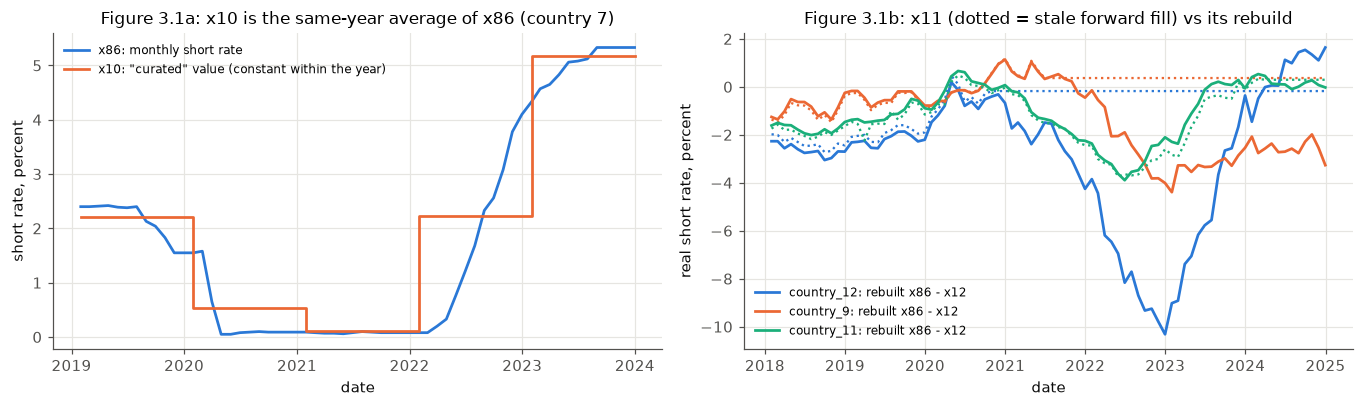

extended file: 148 columns x17..x164
exact duplicates of curated columns (curated, extended): [('x10', 'x73'), ('x12', 'x89'), ('x13', 'x114'), ('x14', 'x17'), ('x15', 'x92'), ('x16', 'x18')]
26 columns identical across all 12 countries; exact copies of global series: [('x6', 'x88'), ('x7', 'x104'), ('x8', 'x109'), ('x9', 'x99')]
frequency of the extended columns: {'monthly or irregular': 86, 'annual (changes in January only)': 35, 'quarterly': 26, 'constant': 1}
columns with gaps: ['x55', 'x82', 'x83', 'x113', 'x136', 'x163', 'x164']
-> the extended file is never concatenated or screened against returns; only x86 (the monthly short rate) is used.


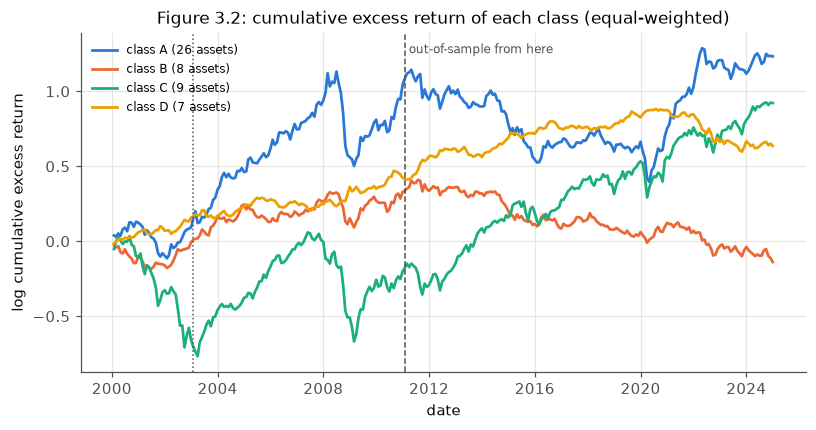

,assets,median ann. vol,min ann. vol,max ann. vol,median Sharpe,worst month
class,,,,,,
A,26,0.297,0.147,0.603,0.253,-0.547
B,8,0.097,0.085,0.122,-0.013,-0.163
C,9,0.176,0.136,0.200,0.239,-0.254
D,7,0.068,0.029,0.091,0.471,-0.121


,class,country,ann. mean,ann. vol,Sharpe (ann.),worst month,worst month date
asset_7,A,country_7,-0.050,0.301,-0.168,-0.252,2011-06
asset_47,A,country_7,-0.028,0.603,-0.046,-0.401,2001-01
asset_40,A,country_7,-0.005,0.316,-0.015,-0.236,2008-03
asset_13,A,country_7,-0.004,0.291,-0.012,-0.241,2011-06
asset_5,A,country_7,-0.001,0.202,-0.007,-0.169,2008-10
asset_18,A,country_7,-0.002,0.304,-0.007,-0.260,2002-08
asset_36,A,country_7,0.002,0.274,0.006,-0.228,2011-09
asset_14,A,country_7,0.015,0.293,0.052,-0.252,2022-06
asset_19,A,country_7,0.023,0.147,0.158,-0.211,2003-12
asset_26,A,country_7,0.049,0.269,0.182,-0.341,2008-10


monthly volatility ranges from 0.82% (asset_16) to 17.40% (asset_47)


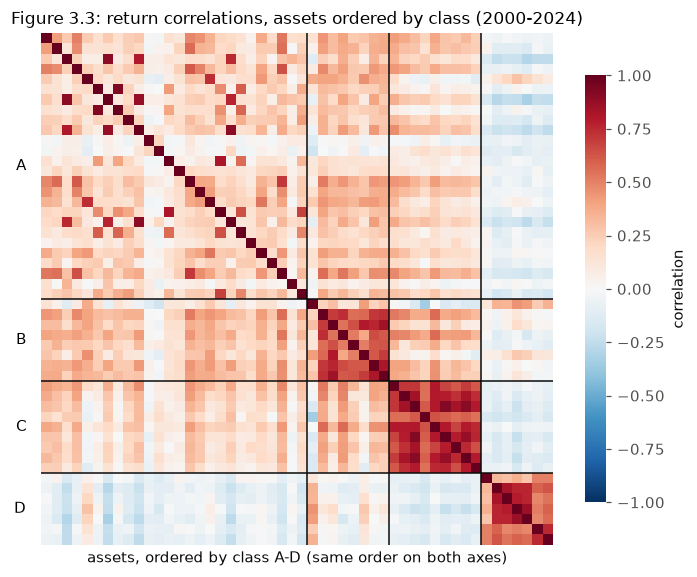

,A,B,C,D
A,0.21,0.24,0.18,-0.08
B,0.24,0.55,0.23,0.05
C,0.18,0.23,0.73,-0.10
D,-0.08,0.05,-0.10,0.58


,A,B,C,D
A,0.25,0.28,0.22,-0.09
B,0.28,0.52,0.26,0.00
C,0.22,0.26,0.76,-0.17
D,-0.09,0.00,-0.17,0.59


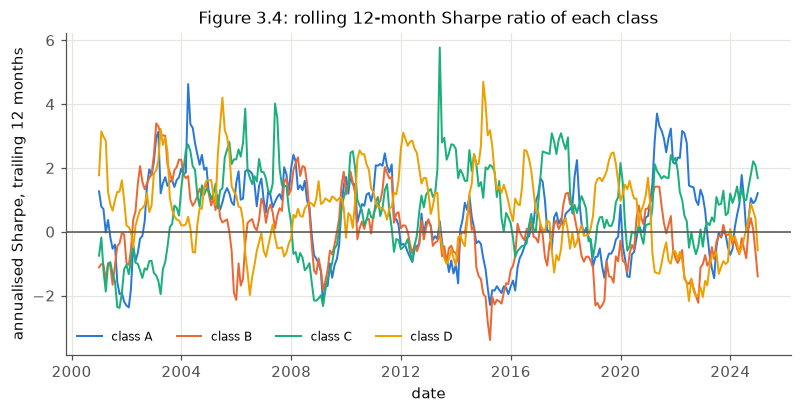

,A,B,C,D
"corr(Sharpe in year k, year k+1)",-0.06,0.14,-0.01,-0.10


x2 = prod(1 + r[t-12..t-1]) - 1 within 1e-5 in 99.63% of asset-months from 2001-01; x5 = sd(r[t-36..t-1]) within 1e-5 in 99.67% from 2003-01


,A,B,C,D
x1 vs own 12m past return,0.28,0.37,-0.03,0.39
x3 vs own 60m past log return,-0.93,-0.98,-0.45,-0.97
x4 vs own 12m past return,0.27,0.16,-0.60,-0.15
x5 vs own 36m past vol,1.00,1.00,1.00,1.00


class B: corr(x1, short-rate differential vs country 7) = 0.93; corr(x4, its 12-month change) = 1.00
Hypotheses: x1 carry (rate differential / yield), x2 12-month momentum, x3 value / 5-year reversal,
            x4 12-month change in the carry fundamental, x5 36-month volatility (the risk measure).


,mean,sd,min,max,peak (cross-country mean),trough,AC(1) of the level,share of months with a change,share of changes made in January,what it probably measures (our reading)
x6,19.9,8.07,10.1,62.7,2008-11,2017-10,0.845,100%,8%,implied-volatility index (VIX-type)
x7,0.812,0.119,0.661,1.31,2020-05,2014-05,0.984,100%,8%,smoothed stress or uncertainty index (a trailing construct)
x8,0.232,1.01,-2.92,2.59,2007-05,2009-02,0.961,100%,8%,standardised activity or sentiment indicator
x9,0.0668,0.0192,0.0223,0.129,2000-08,2009-02,0.978,100%,8%,pro-cyclical level in decimals (yield or growth type)
x86,1.82,1.99,-0.93,7.9,2000-11,2021-06,0.996,92%,8%,"short-term interest rate, %"
x12,1.99,1.82,-2.56,14.5,2022-10,2009-07,0.966,99%,8%,"CPI inflation, year on year, %"
x13,-0.183,5.52,-24,31,2009-11,2008-11,0.931,100%,8%,year-on-year % change of the effective exchange rate
x14,143,92,16.6,849,2020-03,2007-07,0.791,100%,8%,economic-policy-uncertainty index
x15,0.459,0.816,0.00371,13.2,2001-09,2000-12,0.594,100%,8%,geopolitical-risk index
x16,81.3,5.46,65.5,93.5,2001-09,2020-05,0.958,63%,9%,country risk rating (steps of 0.25)


...

,bottom,middle,top
x1,0.096,0.139,0.158
x2,0.141,0.136,0.121
x3,0.079,0.169,0.132
x4,0.091,0.141,0.166
x5,0.160,0.134,0.109


critical |t|: 1.99 for one test, 3.18 for the best of these 25 (Bonferroni; L4 p.27-28). No characteristic is dropped or re-signed because of this table.


,sd of the raw monthly excess return,sd of y = r / sigma-hat
cls,,
A,0.089,1.080
B,0.030,1.056
C,0.046,1.052
D,0.019,1.089


date,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
sd of y,1.14,1.01,0.84,1.01,1.03,1.74,1.00,0.88,0.90,0.83,0.79,0.98,1.26,1.09,0.76,0.95,1.03,1.50,0.95,1.30,0.98,0.94


sd of y: 1.05-1.09 across classes, 0.76 (2017) to 1.74 (2008) across years


In [14]:
# ==============================================================================================================
# Section 3.1: Know your data   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.1: Know your data ====')

# ---------- Integrity: shapes, keys, dates, classes ----------
wide = pd.read_csv(_DATA_DIR + 'asset_returns_wide.csv', parse_dates=['date'])
panel['aid'] = panel.asset_id.str.removeprefix('asset_').astype(int)
AIDS = np.sort(panel.aid.unique())
IDS = [f'asset_{a}' for a in AIDS]                       # natural order asset_1 .. asset_50
CLS = info.loc[IDS, 'asset_class'].to_numpy()             # class of each column, in IDS order
CTRY = info.loc[IDS, 'country'].to_numpy()
assert panel.shape == (15000, 11) and panel.drop(columns='aid').notna().all().all()
assert (pd.DatetimeIndex(np.sort(panel.date.unique())) == DATES).all() and not panel.duplicated(['asset_id', 'date']).any()
assert (panel.groupby('asset_id')[['asset_class', 'country']].nunique() == 1).all().all()
assert (panel.groupby('asset_id')[['asset_class', 'country']].first().loc[IDS].to_numpy() == info.loc[IDS, ['asset_class', 'country']].to_numpy()).all()
assert info.asset_class.value_counts().to_dict() == {'A': 26, 'C': 9, 'B': 8, 'D': 7}
assert (info.loc[info.asset_class == 'A', 'country'] == 'country_7').all()
R = panel.pivot(index='date', columns='asset_id', values='excess_return')[IDS]       # 300 x 50 excess returns
assert np.abs(wide.set_index('date')[IDS].to_numpy() - R.to_numpy()).max() == 0
assert mac_g.shape == (300, 5) and mac_g.notna().all().all() and (pd.DatetimeIndex(mac_g.date) == DATES).all()
for f in (mac_c, mac_x):
    assert len(f) == 3600 and not f.duplicated(['country', 'date']).any() and set(f.date) == set(DATES)
print('all integrity checks passed: 50 assets x 300 month-ends, no missing returns, files agree')
print('dtypes:', {c: str(t) for c, t in panel.dtypes.items() if c != 'aid'})
display(pd.crosstab(info.country, info.asset_class).loc[[f'country_{k}' for k in range(1, 13)]])

# ---------- Trap audit 1: back-filled characteristics, frozen x1, the x5 floor ----------
XNAMES = ['x1', 'x2', 'x3', 'x4', 'x5']
X_RAW = {x: panel.pivot(index='date', columns='asset_id', values=x)[IDS] for x in XNAMES}
X_CLEAN = {x: W.copy() for x, W in X_RAW.items()}
def leading_copies(s):
    """Number of back-filled cells at the start of a series: a constant run from the first month is
    copies of the first genuine value, so all but its last cell are fills (0 if there is no run)."""
    run = 1
    while run < len(s) and s[run] == s[0]:
        run += 1
    return run - 1

fills = []
for x in ['x2', 'x3', 'x5']:                              # the exam's data notes: leading months of x2, x3, x5 were filled
    for j, a in enumerate(IDS):
        k = leading_copies(X_RAW[x][a].to_numpy())
        if k:
            X_CLEAN[x].iloc[:k, j] = np.nan               # treat the copies as missing (a backward fill uses the future)
            fills.append({'variable': x, 'asset': a, 'class': CLS[j], 'months filled': k,
                          'last filled month': DATES[k - 1].date(), 'first genuine month': DATES[k].date()})
fill_tab = pd.DataFrame(fills)
display(fill_tab)
LAST_FILL = pd.Timestamp(max(fill_tab['last filled month']))
print(f'{len(fill_tab)} (variable, asset) pairs, {fill_tab["asset"].nunique()} assets; last filled month {LAST_FILL.date()} '
      f'-> the first target month {DATES[FIRST_M].date()} uses none of them, even through x3\'s one-month lag')

# x1 stops updating at the end of the sample for some class-B assets
frozen = []
for j, a in enumerate(IDS):
    s = X_RAW['x1'][a].to_numpy()
    run = 1
    while run < len(s) and s[-1 - run] == s[-1]:
        run += 1
    if run >= 3:
        frozen.append({'asset': a, 'class': CLS[j], 'constant stored months at the end': run,
                       'stale stored months': f'{DATES[-run + 1].date()} .. {DATES[-1].date()}'})
frozen_tab = pd.DataFrame(frozen)
display(frozen_tab)
# a stale value stored in month s is used for target s+1, and target 2025-01 does not exist
FROZEN_ROWS = [(a, DATES[m]) for a, k in zip(frozen_tab.asset, frozen_tab['constant stored months at the end'])
               for m in range(300 - k + 2, 300)]
print(f'target rows that use a stale x1: {len(FROZEN_ROWS)} (kept as stored: a desk would have seen them; excluded in one evaluation-only cut)')

# x5 is the 36-month volatility, floored at 0.004 for asset_16
SD36 = R.rolling(36, min_periods=36).std(ddof=1).shift(1)
floor = X_RAW['x5']['asset_16'] == 0.004
print(f'asset_16: x5 = 0.004 in {int(floor.sum())} months ({DATES[floor.to_numpy()][0].date()} .. {DATES[floor.to_numpy()][-1].date()}); '
      f'its own 36-month SD falls to {SD36.loc[floor, "asset_16"].min():.5f} there -> our sigma-hat is computed from returns, not from x5')

# ---------- Trap audit 2: x10 is a same-year average (look-ahead); x11 stops at a regime change ----------
cm = mac_c.merge(mac_x[['country', 'date', 'x86', 'x85']], on=['country', 'date'], validate='one_to_one')
cm['year'] = cm.date.dt.year
yr = cm.groupby(['country', 'year']).agg(x10=('x10', 'first'), x10_values=('x10', 'nunique'), same_year=('x86', 'mean'))
yr['prior_year'] = yr.groupby(level='country')['same_year'].shift(1)
ok = yr.dropna()
x10_tab = pd.Series({
    'x10 constant within each calendar year (share of country-years)': (yr.x10_values == 1).mean(),
    'x10 = same-year mean of x86 within 0.001 (share)': (np.abs(yr.x10 - yr.same_year) < 1e-3).mean(),
    'x10 within 0.10 of the same-year mean (share)': (np.abs(yr.x10 - yr.same_year) < 0.10).mean(),
    'corr(x10, same-year mean of x86)': ok.x10.corr(ok.same_year),
    'corr(x10, prior-year mean of x86)': ok.x10.corr(ok.prior_year),
    'x10 closer to the same-year than the prior-year mean (share)': (np.abs(ok.x10 - ok.same_year) < np.abs(ok.x10 - ok.prior_year)).mean()},
    name='value')
display(x10_tab.to_frame())
print('-> x10 in January already "knows" the rest of the year: a 1-month lag leaves up to 11 months of look-ahead.\n'
      '   The monthly short rate x86 (extended file) is used instead, at the same 2-month lag as every macro series.')

# x11: where it stops, and how well x86 - x12 rebuilds it
x11_stop = cm.groupby('country').apply(lambda d: pd.Series({
    'last non-missing': d.loc[d.x11.notna(), 'date'].max().date(), 'missing months': int(d.x11.isna().sum()),
    'interior holes': int(d.x11.isna().sum() - (d.date > d.loc[d.x11.notna(), 'date'].max()).sum())}), include_groups=False)
cm['x11_rebuild'] = cm.x86 - cm.x12
ov = cm.dropna(subset=['x11'])
rb = ov.groupby('country').apply(lambda d: pd.Series({'corr': d.x11.corr(d.x11_rebuild),
                                                      'RMSE': np.sqrt(((d.x11 - d.x11_rebuild) ** 2).mean())}), include_groups=False)
stale = []
for c in x11_stop.index[x11_stop['missing months'] > 0]:
    d = cm[cm.country == c].sort_values('date')
    after = d.x11.isna()
    err = (d.x11.ffill() - d.x11_rebuild)[after].abs()
    stale.append({'country': c, 'stale forward-fill error, mean (pp)': err.mean(), 'max (pp)': err.max()})
x11_tab = x11_stop.join(rb).join(pd.DataFrame(stale).set_index('country'))
display(x11_tab.loc[x11_stop['missing months'].sort_values(ascending=False).index])
print(f'pooled rebuild quality on the overlap: corr {ov.x11.corr(ov.x11_rebuild):.3f}, RMSE {np.sqrt(((ov.x11 - ov.x11_rebuild) ** 2).mean()):.3f}. '
      'x11 is not added as a column: it has gaps (three countries stop early) and is nearly redundant with x86 - x12, '
      'whose two parts are both in the model.')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.8))
d7 = cm[(cm.country == 'country_7') & (cm.date >= '2019-01-01') & (cm.date <= '2023-12-31')]
ax1.plot(d7.date, d7.x86, color=C_BLUE, label='x86: monthly short rate')
ax1.step(d7.date, d7.x10, where='post', color=C_ORANGE, label='x10: "curated" value (constant within the year)')
ax1.set_title('Figure 3.1a: x10 is the same-year average of x86 (country 7)')
ax1.set_xlabel('date')
ax1.set_ylabel('short rate, percent')
ax1.legend(fontsize=8)
for c, col in zip(['country_12', 'country_9', 'country_11'], [C_BLUE, C_ORANGE, C_AQUA]):
    d = cm[(cm.country == c) & (cm.date >= '2018-01-01')].sort_values('date')
    ax2.plot(d.date, d.x11_rebuild, color=col, label=f'{c}: rebuilt x86 - x12')
    ax2.plot(d.date, d.x11.ffill(), color=col, linestyle=':', linewidth=1.5)
ax2.set_title('Figure 3.1b: x11 (dotted = stale forward fill) vs its rebuild')
ax2.set_xlabel('date')
ax2.set_ylabel('real short rate, percent')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ---------- Trap audit 3: the extended file (duplicates, hidden global series, frequencies, gaps) ----------
ext_cols = [c for c in mac_x.columns if c.startswith('x')]
cur_cols = [f'x{k}' for k in range(10, 17)]
mc, mx = mac_c.sort_values(['country', 'date']).reset_index(drop=True), mac_x.sort_values(['country', 'date']).reset_index(drop=True)
assert (mc[['country', 'date']].to_numpy() == mx[['country', 'date']].to_numpy()).all()     # rows align on keys
same = lambda a, b: bool(((a == b) | (a.isna() & b.isna())).all())
dups = [(c, e) for c in cur_cols for e in ext_cols if same(mc[c], mx[e])]
by_date = {e: mx.pivot(index='date', columns='country', values=e) for e in ext_cols}
hidden_global = [e for e in ext_cols if (by_date[e].nunique(axis=1, dropna=False) <= 1).all()]
glob_dups = [(g, e) for g in ['x6', 'x7', 'x8', 'x9'] for e in hidden_global if np.allclose(by_date[e].iloc[:, 0].to_numpy(), mac_g[g].to_numpy())]
def frequency(e):
    ch = by_date[e].diff().iloc[1:]
    months = set(ch.index[(ch.fillna(0) != 0).any(axis=1)].month)
    if not months: return 'constant'
    if months <= {1}: return 'annual (changes in January only)'
    if months <= {1, 4, 7, 10}: return 'quarterly'
    return 'monthly or irregular'
freq = pd.Series({e: frequency(e) for e in ext_cols})
gaps = [e for e in ext_cols if mx[e].isna().any()]
print(f'extended file: {len(ext_cols)} columns x{ext_cols[0][1:]}..{ext_cols[-1]}')
print('exact duplicates of curated columns (curated, extended):', dups)
print(f'{len(hidden_global)} columns identical across all 12 countries; exact copies of global series:', glob_dups)
print('frequency of the extended columns:', freq.value_counts().to_dict())
print('columns with gaps:', gaps)
print('-> the extended file is never concatenated or screened against returns; only x86 (the monthly short rate) is used.')

# ---------- Returns: cumulative by class, per-asset table ----------
CLS_S = pd.Series(CLS, index=IDS)
class_ret = R.T.groupby(CLS_S).mean().T                   # equal-weighted class averages
fig, ax = plt.subplots(figsize=(8.5, 4))
for c in 'ABCD':
    ax.plot(class_ret.index, np.log((1 + class_ret[c]).cumprod()), color=CLASS_COL[c], label=f'class {c} ({(CLS == c).sum()} assets)')
ax.axvline(DATES[FIRST_M], color=C_GREY, linestyle=':', linewidth=1)
ax.axvline(DATES[OOS_M[0]], color=C_GREY, linestyle='--', linewidth=1)
ax.text(DATES[OOS_M[0]], ax.get_ylim()[1] * 0.95, ' out-of-sample from here', color=C_GREY, fontsize=8, va='top')
ax.set_xlabel('date')
ax.set_ylabel('log cumulative excess return')
ax.set_title('Figure 3.2: cumulative excess return of each class (equal-weighted)')
ax.legend(fontsize=8, loc='upper left')
plt.show()

vol = R.std(ddof=1)
asset_tab = pd.DataFrame({'class': CLS, 'country': CTRY, 'ann. mean': 12 * R.mean(), 'ann. vol': np.sqrt(12) * vol,
                          'Sharpe (ann.)': np.sqrt(12) * R.mean() / vol, 'worst month': R.min(),
                          'worst month date': R.idxmin().dt.strftime('%Y-%m')}, index=IDS)
cls_summary = asset_tab.groupby('class').agg(assets=('country', 'size'), **{'median ann. vol': ('ann. vol', 'median'),
             'min ann. vol': ('ann. vol', 'min'), 'max ann. vol': ('ann. vol', 'max'), 'median Sharpe': ('Sharpe (ann.)', 'median'),
             'worst month': ('worst month', 'min')})
display(cls_summary.style.format('{:.3f}', subset=cls_summary.columns[1:]).set_caption('Table 3.1a: by class (monthly volatility x sqrt(12))'))
display(asset_tab.sort_values(['class', 'Sharpe (ann.)']).style.format({c: '{:.3f}' for c in ['ann. mean', 'ann. vol', 'Sharpe (ann.)', 'worst month']})
        .set_caption('Table 3.1b: every asset, 2000-2024'))
print(f'monthly volatility ranges from {vol.min():.2%} ({vol.idxmin()}) to {vol.max():.2%} ({vol.idxmax()})')

# ---------- Correlation matrix ordered by class, and its block structure ----------
order = sorted(IDS, key=lambda a: ('ABCD'.index(CLS_S[a]), int(a.split('_')[1])))
corr_full = R[order].corr()
fig, ax = plt.subplots(figsize=(7.5, 6.3))
sns.heatmap(corr_full, vmin=-1, vmax=1, center=0, cmap='RdBu_r', square=True, xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'correlation', 'shrink': 0.8}, ax=ax)
edges = np.cumsum([(CLS == c).sum() for c in 'ABCD'])
for e in edges[:-1]:
    ax.axhline(e, color=C_INK, linewidth=1)
    ax.axvline(e, color=C_INK, linewidth=1)
for c, mid in zip('ABCD', edges - np.array([(CLS == c).sum() for c in 'ABCD']) / 2):
    ax.text(-1.5, mid, c, ha='right', va='center', fontsize=10)
ax.set_xlabel('assets, ordered by class A-D (same order on both axes)')
ax.set_ylabel('')
ax.set_title('Figure 3.3: return correlations, assets ordered by class (2000-2024)')
plt.show()

def block_table(C):
    """Mean off-diagonal correlation within and between classes."""
    out = pd.DataFrame(index=list('ABCD'), columns=list('ABCD'), dtype=float)
    for c1 in 'ABCD':
        for c2 in 'ABCD':
            b = C.loc[CLS_S.index[CLS_S == c1], CLS_S.index[CLS_S == c2]].to_numpy()
            out.loc[c1, c2] = b[~np.eye(len(b), dtype=bool)].mean() if c1 == c2 else b.mean()
    return out
display(block_table(corr_full).style.format('{:.2f}').set_caption('Table 3.2: average correlation within (diagonal) and between classes, 2000-2024'))
display(block_table(R.loc['2003-01-31':'2010-12-31'].corr()).style.format('{:.2f}').set_caption('Table 3.2 (training block 2003-2010)'))

# ---------- Rolling 12-month Sharpe by class, and how persistent performance is ----------
roll_sr = np.sqrt(12) * class_ret.rolling(12).mean() / class_ret.rolling(12).std(ddof=1)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for c in 'ABCD':
    ax.plot(roll_sr.index, roll_sr[c], color=CLASS_COL[c], linewidth=1.3, label=f'class {c}')
ax.axhline(0, color=C_GREY, linewidth=1)
ax.set_xlabel('date')
ax.set_ylabel('annualised Sharpe, trailing 12 months')
ax.set_title('Figure 3.4: rolling 12-month Sharpe ratio of each class')
ax.legend(fontsize=8, ncol=4, loc='lower left')
plt.show()
yearly = class_ret.groupby(class_ret.index.year).apply(lambda d: np.sqrt(12) * d.mean() / d.std(ddof=1))
persist = pd.Series({c: yearly[c].corr(yearly[c].shift(-1)) for c in 'ABCD'}, name='corr(Sharpe in year k, year k+1)')
display(persist.to_frame().T.style.format('{:.2f}').set_caption('Table 3.3: persistence of calendar-year Sharpe ratios (24 non-overlapping pairs)'))

# ---------- Characteristics: scale, persistence, identities, and what each one measures ----------
LAGGED = {x: (X_CLEAN[x].shift(1) if x in ('x1', 'x3', 'x4') else X_CLEAN[x]) for x in XNAMES}   # known at the end of t-1
rows = []
for x in XNAMES:
    W = LAGGED[x].iloc[FIRST_M:]
    for c in 'ABCD':
        blk = W.loc[:, CLS == c]
        rows.append({'characteristic': x, 'class': c, 'mean': np.nanmean(blk), 'sd': np.nanstd(blk, ddof=1),
                     'p1': np.nanpercentile(blk, 1), 'p99': np.nanpercentile(blk, 99),
                     'AC(1) median': np.median([blk[a].autocorr(1) for a in blk]),
                     'AC(12) median': np.median([blk[a].autocorr(12) for a in blk]),
                     'cross-sectional sd (median month)': blk.std(axis=1, ddof=1).median()})
char_tab = pd.DataFrame(rows).set_index(['characteristic', 'class'])
display(char_tab.style.format('{:.3g}').set_caption('Table 3.4: forecast-aligned characteristics by class, 2003-2024'))

# identities: x2 is the compounded past 12-month return, x5 the past 36-month volatility (both already lagged)
R12 = np.expm1(np.log1p(R).rolling(12, min_periods=12).sum()).shift(1)
share_x2 = (np.abs(X_RAW['x2'] - R12).iloc[12:] < 1e-5).to_numpy().mean()
share_x5 = (np.abs(X_RAW['x5'] - SD36).iloc[FIRST_M:] < 1e-5).to_numpy().mean()
print(f'x2 = prod(1 + r[t-12..t-1]) - 1 within 1e-5 in {share_x2:.2%} of asset-months from 2001-01; '
      f'x5 = sd(r[t-36..t-1]) within 1e-5 in {share_x5:.2%} from 2003-01')
assert share_x2 > 0.99 and share_x5 > 0.99

# what the others track (predictor vs PAST returns and macro only, never the target)
R60 = np.log1p(R).rolling(60, min_periods=60).sum().shift(1)
def ts_corr(A, B, c):
    return np.nanmean([pd.concat([A[a], B[a]], axis=1).dropna().corr().iloc[0, 1] for a in np.array(IDS)[CLS == c]])
hyp = pd.DataFrame({c: {'x1 vs own 12m past return': ts_corr(LAGGED['x1'], R12, c),
                        'x3 vs own 60m past log return': ts_corr(LAGGED['x3'], R60, c),
                        'x4 vs own 12m past return': ts_corr(LAGGED['x4'], R12, c),
                        'x5 vs own 36m past vol': ts_corr(LAGGED['x5'], SD36, c)} for c in 'ABCD'})
rate_diff = cm.pivot(index='date', columns='country', values='x86')
rd = rate_diff.sub(rate_diff['country_7'], axis=0)
b_ids = np.array(IDS)[CLS == 'B']
x1_b = np.nanmean([X_RAW['x1'][a].corr(rd[info.loc[a, 'country']]) for a in b_ids])
x4_b = np.nanmean([X_RAW['x4'][a].corr(rd[info.loc[a, 'country']].diff(12)) for a in b_ids])
display(hyp.style.format('{:.2f}').set_caption('Table 3.5: average within-asset correlation with past returns, by class'))
print(f'class B: corr(x1, short-rate differential vs country 7) = {x1_b:.2f}; corr(x4, its 12-month change) = {x4_b:.2f}')
print('Hypotheses: x1 carry (rate differential / yield), x2 12-month momentum, x3 value / 5-year reversal,\n'
      '            x4 12-month change in the carry fundamental, x5 36-month volatility (the risk measure).')

# ---------- The macro inputs used: scale, persistence, update frequency, and what each probably measures ----------
# Post hoc (added after the out-of-sample results were seen). Predictors alone, and their relation to PAST returns
# only: no link to the returns they will forecast.
def describe_macro(W):
    """W: date x country (or one column) for one series. Pooled scale, peak and trough of the cross-country mean,
    persistence, and how often and in which calendar months the values change."""
    v = W.stack()
    path = W.mean(axis=1)
    ch = W.diff().abs().iloc[1:] > 1e-12
    months_changed = np.repeat(ch.index.month.to_numpy()[:, None], ch.shape[1], axis=1)[ch.to_numpy()]
    return {'mean': v.mean(), 'sd': v.std(ddof=1), 'min': v.min(), 'max': v.max(),
            'peak (cross-country mean)': path.idxmax().strftime('%Y-%m'), 'trough': path.idxmin().strftime('%Y-%m'),
            'AC(1) of the level': np.nanmean([W[c].autocorr(1) for c in W]),
            'share of months with a change': ch.to_numpy().mean(),
            'share of changes made in January': (months_changed == 1).mean()}
MAC_G_LEVELS = mac_g.set_index('date')
macro_desc = {k: describe_macro(MAC_G_LEVELS[[k]]) for k in ['x6', 'x7', 'x8', 'x9']}           # the global series used
for k, src in [('x86', mac_x), ('x12', mac_c), ('x13', mac_c), ('x14', mac_c), ('x15', mac_c), ('x16', mac_c)]:
    macro_desc[k] = describe_macro(src.pivot(index='date', columns='country', values=k))  # the country series used
MEANING = {'x6': 'implied-volatility index (VIX-type)', 'x7': 'smoothed stress or uncertainty index (a trailing construct)',
           'x8': 'standardised activity or sentiment indicator', 'x9': 'pro-cyclical level in decimals (yield or growth type)',
           'x86': 'short-term interest rate, %', 'x12': 'CPI inflation, year on year, %',
           'x13': 'year-on-year % change of the effective exchange rate', 'x14': 'economic-policy-uncertainty index',
           'x15': 'geopolitical-risk index', 'x16': 'country risk rating (steps of 0.25)'}
mtab = pd.DataFrame(macro_desc).T
mtab['what it probably measures (our reading)'] = pd.Series(MEANING)
display(mtab.style.format({**{c: '{:.3g}' for c in ['mean', 'sd', 'min', 'max']}, 'AC(1) of the level': '{:.3f}',
                           'share of months with a change': '{:.0%}', 'share of changes made in January': '{:.0%}'})
        .set_caption('Table 3.5b: the ten macro inputs used, 2000-2024 (country series pooled over the 12 countries) (post hoc)'))
# the evidence behind the readings (series alone, or against past returns only)
rv12 = class_ret.rolling(12, min_periods=12).std(ddof=1)                # trailing realised volatility, months t-11..t
x6_vol = {c: MAC_G_LEVELS.x6.corr(rv12[c]) for c in 'ABCD'}
print('corr(x6, trailing 12-month realised volatility of each class average): ' + ', '.join(f'{c} {v:.2f}' for c, v in x6_vol.items()))
peak = lambda k: mac_c.pivot(index='date', columns='country', values=k).idxmax()
print(f"x12 peaks in 2022 or 2023 for {int(peak('x12').dt.year.isin([2022, 2023]).sum())} of 12 countries; "
      f"x15 peaks in 2001-09 for {int((peak('x15').dt.strftime('%Y-%m') == '2001-09').sum())} of 12")
print(f"x6 peaks in {MAC_G_LEVELS.x6.idxmax():%Y-%m}; x8 has mean {MAC_G_LEVELS.x8.mean():.2f} and sd {MAC_G_LEVELS.x8.std(ddof=1):.2f} (a z-score)")
jan = mtab['share of changes made in January'].astype(float)
print(f'largest share of changes made in January among the series used: {jan.max():.0%} (an annual series stamped in '
      'January would show 100%), so every series used updates within the year, unlike x10')

# ---------- A first look at predictive content: tercile sorts, TRAINING BLOCK ONLY (2003-2010) ----------
Y = R / SD36                                              # the vol-scaled target, defined from 2003-01
sort_months = range(FIRST_M, INIT_END_M + 1)
assert DATES[max(sort_months)] <= pd.Timestamp('2010-12-31')        # no out-of-sample return is used here
rows, terc_rows = [], {}
for x in XNAMES:
    spreads = {c: [] for c in 'ABCD'}
    levels_x = []
    for m in sort_months:
        for c in 'ABCD':
            cols = np.flatnonzero(CLS == c)
            v = LAGGED[x].iloc[m, cols].to_numpy()
            yy = Y.iloc[m, cols].to_numpy()
            k = len(cols) // 3
            o = np.argsort(v, kind='stable')               # ties broken by asset order
            spreads[c].append(yy[o[-k:]].mean() - yy[o[:k]].mean())
            levels_x.append([yy[o[:k]].mean(), yy[o[k:-k]].mean(), yy[o[-k:]].mean()])
    terc_rows[x] = dict(zip(['bottom', 'middle', 'top'], np.mean(levels_x, axis=0)))
    sp = pd.DataFrame(spreads)
    sp['all classes'] = sp.mean(axis=1)
    for col in sp:
        s = sp[col]
        rows.append({'characteristic': x, 'class': col, 'top minus bottom tercile, mean y': s.mean(),
                     't': s.mean() / (s.std(ddof=1) / np.sqrt(len(s)))})
sorts = pd.DataFrame(rows).pivot(index='characteristic', columns='class', values=['top minus bottom tercile, mean y', 't'])
display(sorts.style.format('{:.2f}').set_caption(f'Table 3.6: tercile spreads of next-month vol-scaled return, 2003-2010 ({len(sort_months)} months)'))
display(pd.DataFrame(terc_rows).T.style.format('{:.3f}')
        .set_caption('Table 3.6b: average next-month y in each within-class tercile, 2003-2010 (mean over classes and months) (post hoc)'))
print(f'critical |t|: {stats.t.ppf(0.975, len(sort_months) - 1):.2f} for one test, '
      f'{stats.t.ppf(1 - 0.025 / 25, len(sort_months) - 1):.2f} for the best of these 25 (Bonferroni; L4 p.27-28). '
      'No characteristic is dropped or re-signed because of this table.')

# ---------- Does volatility scaling equalise the variance of the target? (post hoc) ----------
# Returns alone (no predictor), so the full sample is used, as for the other return statistics in this section.
yl = (R / SD36).loc[DATES[FIRST_M]:].stack().rename('y').reset_index()
yl.columns = ['date', 'asset_id', 'y']
yl['r'] = R.loc[DATES[FIRST_M]:].stack().to_numpy()
yl['cls'] = yl.asset_id.map(CLS_S)
assert yl.y.notna().all() and len(yl) == 50 * (len(DATES) - FIRST_M)
sd_cls = yl.groupby('cls')[['r', 'y']].std(ddof=1)
sd_cls.columns = ['sd of the raw monthly excess return', 'sd of y = r / sigma-hat']
display(sd_cls.style.format('{:.3f}').set_caption('Table 3.6c: spread of the raw return and of the target by class, 2003-2024 (post hoc)'))
sd_year = yl.groupby(yl.date.dt.year).y.std(ddof=1)
display(sd_year.to_frame('sd of y').T.style.format('{:.2f}').set_caption('Table 3.6d: sd of the target by year (post hoc)'))
print(f'sd of y: {sd_cls.iloc[:, 1].min():.2f}-{sd_cls.iloc[:, 1].max():.2f} across classes, '
      f'{sd_year.min():.2f} ({sd_year.idxmin()}) to {sd_year.max():.2f} ({sd_year.idxmax()}) across years')

### 3.2 Feature engineering

One function, `build_features`, builds every predictor from the raw files; the row for target month $t$ uses only information available at the end of $t-1$. The same code serves the causality test (rebuild on data truncated at 2010-12; nothing up to 2010-12 may change), the placebo and the `x10` variants.

| block | construction |
|---|---|
| lags | `x2`, `x5` as stored (already lagged); `x1`, `x3`, `x4` lagged 1 month; all macro lagged **2 months** (1 as robustness): publication date, not period end (L5 p.58 item 2) |
| characteristics `u1..u5` | rank within class and month, scaled to [−0.5, 0.5]: comparable across classes, bounded (L3 p.11–12), nothing fitted, so no leak; z-score as robustness (our choice) |
| levels `l1..l5` (secondary) | own lagged characteristic as a trailing 60-month z-score: a time-series channel |
| global macro | log `x6`; trailing 60-month z-score, then lag; one slope per class (L3 p.53–54) |
| country macro | `x86` (replaces the look-ahead `x10`), `x12`, `x13`, log `x14`, log `x15`, `x16`: differential vs country 7, trailing 60-month z-score per country, lag; × class for B, C, D; **none for class A** (no natural country) |
| class intercepts | unpenalised, by fitting linear models on within-class demeaned data (our choice; L3 p.50, L5 p.12) |

In [15]:
# ==============================================================================================================
# Section 3.2: Feature engineering   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.2: Feature engineering ====')

CHARS = ['u1', 'u2', 'u3', 'u4', 'u5']
LEVELS = ['l1', 'l2', 'l3', 'l4', 'l5']
G_SER = ['x6', 'x7', 'x8', 'x9']
C_SER = [('x86', 'extended', False), ('x12', 'curated', False), ('x13', 'curated', False),
         ('x14', 'curated', True), ('x15', 'curated', True), ('x16', 'curated', False)]   # (series, file, take logs)
COUNTRIES = [f'country_{k}' for k in range(1, 13)]
C_IDX = np.array([COUNTRIES.index(c) for c in CTRY])                  # each asset's country column

def trailing_z(W, window=60, min_periods=24):
    """z-score of each value against the trailing window that ends at it (past and present only)."""
    sd = W.rolling(window, min_periods=min_periods).std(ddof=1)
    return (W - W.rolling(window, min_periods=min_periods).mean()) / sd.where(sd > 1e-12)

def build_features(pan, mg, mc, mx, macro_lag=MACRO_LAG, char_std='rank', short_rate='x86', sr_lag=None, shift=0):
    """Every predictor for every (month, asset), known at the end of month t-1, from the raw files only.
    shift > 0 circularly shifts every raw macro series by `shift` months first (the placebo)."""
    dates = pd.DatetimeIndex(np.sort(pan.date.unique()))
    T, N = len(dates), len(IDS)
    Rw = pan.pivot(index='date', columns='asset_id', values='excess_return')[IDS]
    sig = Rw.rolling(36, min_periods=36).std(ddof=1).shift(1)          # sigma-hat_{t-1} from r_{t-36..t-1}
    lagged = {}
    for x in XNAMES:
        W = pan.pivot(index='date', columns='asset_id', values=x)[IDS].copy()
        if x in ('x2', 'x3', 'x5'):                                     # back-filled leading cells -> missing
            for j in range(N):
                k = leading_copies(W.iloc[:, j].to_numpy())
                if k:
                    W.iloc[:k, j] = np.nan
        lagged[x] = W.shift(1) if x in ('x1', 'x3', 'x4') else W       # x2 and x5 are stored already lagged
    feats = {}
    for x, name in zip(XNAMES, CHARS):                                  # within-class, within-month standardisation
        out = pd.DataFrame(np.nan, index=dates, columns=IDS)
        for c in 'ABCD':
            cols = [a for a, k in zip(IDS, CLS) if k == c]
            B = lagged[x][cols]
            if char_std == 'rank':
                out[cols] = (B.rank(axis=1, method='average') - 1) / (len(cols) - 1) - 0.5
            else:
                out[cols] = B.sub(B.mean(axis=1), axis=0).div(B.std(axis=1, ddof=1), axis=0).clip(-3, 3)
        feats[name] = out.to_numpy()
    for x, name in zip(XNAMES, LEVELS):                                 # own-history levels (0 until 24 months exist)
        feats[name] = trailing_z(lagged[x]).fillna(0).clip(-5, 5).to_numpy()

    roll = (lambda A: np.roll(A, shift, axis=0)) if shift else (lambda A: A)
    G = mg.set_index('date')[G_SER].copy()
    G['x6'] = np.log(G['x6'])
    G = pd.DataFrame(roll(G.to_numpy()), index=G.index, columns=G_SER)
    GZ = trailing_z(G).shift(macro_lag)
    CZ = {}
    for ser, src, take_log in C_SER:
        name, lag = ser, macro_lag
        if ser == 'x86' and short_rate == 'x10':                        # curated-file variant (and its leak demo)
            ser, src, lag = 'x10', 'curated', sr_lag
        P = (mx if src == 'extended' else mc).pivot(index='date', columns='country', values=ser)[COUNTRIES]
        P = np.log(P) if take_log else P
        P = pd.DataFrame(roll(P.to_numpy()), index=P.index, columns=COUNTRIES)
        D = P.sub(P['country_7'], axis=0)                               # differential vs country 7
        Z = trailing_z(D)
        Z['country_7'] = 0.0                                            # country 7 has no differential
        CZ[name] = Z.shift(lag)

    F = pd.DataFrame({'date': np.repeat(dates, N), 'm': np.repeat(np.arange(T), N), 'asset_id': np.tile(IDS, T),
                      'cls': np.tile(CLS, T), 'country': np.tile(CTRY, T),
                      'r': Rw.to_numpy().ravel(), 'sig': sig.to_numpy().ravel()})
    F['y'] = F.r / F.sig
    for name, A in feats.items():
        F[name] = A.ravel()
    for c in 'BCD':
        F['d' + c] = (F.cls == c).astype(float)
    for k in G_SER:
        F['g_' + k] = np.repeat(GZ[k].to_numpy(), N)
        for c in 'ABCD':
            F[f'g_{k}_{c}'] = F['g_' + k] * (F.cls == c)
    for k, _, _ in C_SER:
        F['c_' + k] = CZ[k].to_numpy()[:, C_IDX].ravel()
        F.loc[F.cls == 'A', 'c_' + k] = 0.0                             # class A: no country macro
        for c in 'BCD':
            F[f'c_{k}_{c}'] = F['c_' + k] * (F.cls == c)
    F = F[F.m >= FIRST_M].reset_index(drop=True)
    if short_rate == 'x10' and sr_lag and sr_lag > 12:
        # x10 at a 14-month lag first has a 24-month trailing z for target 2003-02; the 50 rows of 2003-01 get 0,
        # the neutral value (a fixed constant, not an estimate), in this sensitivity variant only
        xcols = [c for c in F if c.startswith('c_x86')]
        F[xcols] = F[xcols].fillna(0.0)
    return F, {'lagged': lagged, 'GZ': GZ, 'CZ': CZ, 'G': G}

GLOB = [f'g_{k}_{c}' for k in G_SER for c in 'ABCD']
CTRY_INT = [f'c_{k}_{c}' for k, _, _ in C_SER for c in 'BCD']
FSETS = {'M1': [], 'M2': CHARS, 'M3': CHARS + GLOB + CTRY_INT, 'M3-global': CHARS + GLOB, 'M3-country': CHARS + CTRY_INT,
         'M2-levels': CHARS + LEVELS, 'M3-levels': CHARS + GLOB + CTRY_INT + LEVELS}
RF_SETS = {'M2': CHARS + ['dB', 'dC', 'dD'],
           'M3': CHARS + ['dB', 'dC', 'dD'] + ['g_' + k for k in G_SER] + ['c_' + k for k, _, _ in C_SER]}

t0 = time.perf_counter()
F, AUX = build_features(panel, mac_g, mac_c, mac_x)
print(f'feature frame: {F.shape[0]:,} rows ({F.m.nunique()} target months x {F.asset_id.nunique()} assets), built in {time.perf_counter() - t0:.1f} s')
model_cols = sorted(set(sum(FSETS.values(), []) + sum(RF_SETS.values(), [])))
assert len(F) == 264 * 50 and F[model_cols + ['y', 'sig']].notna().all().all(), 'a predictor is missing somewhere'
assert (F.groupby(['m', 'cls'])[CHARS].sum().abs() < 1e-12).all().all()          # ranks sum to zero in every class-month
assert F.loc[F.cls == 'A', [c for c in F if c.startswith('c_')]].eq(0).all().all()

# Table 3.7: every predictor and the count (the exam's suggested workflow)
pred_tab = pd.DataFrame([
    ['characteristics', 'u1..u5', 'x1 (lag 1), x2 (as stored), x3 (lag 1), x4 (lag 1), x5 (as stored) -> rank within class and month', 'all', 5],
    ['class intercepts', 'A (reference), dB, dC, dD', 'asset_info; unpenalised', 'all', 3],
    ['global macro x class', 'g_x6..g_x9 x {A,B,C,D}', 'log x6, x7, x8, x9 -> trailing 60m z -> lag 2', 'all', len(GLOB)],
    ['country macro x class', '{x86, x12, x13, log x14, log x15, x16} x {B,C,D}', 'minus country 7 -> trailing 60m z per country -> lag 2', 'B, C, D', len(CTRY_INT)],
    ['levels (secondary only)', 'l1..l5', "each asset's own lagged characteristic -> trailing 60m z", 'all', 5],
    ['target', 'y', 'excess return / 36m SD of own past excess returns', 'all', 1]],
    columns=['block', 'columns', 'source -> transform -> lag', 'classes', 'count']).set_index('block')
display(pred_tab.style.set_caption('Table 3.7: predictors'))
display(pd.Series({k: len(v) + 3 for k, v in FSETS.items()}, name='columns incl. the 3 class intercepts').to_frame().T)
print('Not used: x10/x73 (same-year average: look-ahead), stored x11 (gaps; nearly redundant with x86 - x12, whose parts are included),'
      ' every other extended column (duplicates, hidden global copies, annual/quarterly series whose publication timing is unknown, gaps).')

# ---------- Checks that the features only use the past ----------
# (1) Lag spot checks at 20 random (asset, month) pairs, against the raw files
rng_chk = np.random.default_rng(P3_SEED)
G_raw = mac_g.set_index('date')[G_SER].assign(x6=lambda d: np.log(d.x6))
D86 = cm.pivot(index='date', columns='country', values='x86')[COUNTRIES]
D86 = D86.sub(D86['country_7'], axis=0)
for _ in range(20):
    i = rng_chk.integers(len(F))
    m, a = F.m[i], F.asset_id[i]
    j = IDS.index(a)
    assert AUX['lagged']['x1'].iloc[m, j] == X_RAW['x1'].iloc[m - 1, j]          # x1 from month t-1
    assert AUX['lagged']['x2'].iloc[m, j] == X_RAW['x2'].iloc[m, j]              # x2 as stored (pre-lagged)
    assert np.isclose(F.g_x6[i], trailing_z(G_raw)['x6'].iloc[m - 2])            # global macro from month t-2
    if F.cls[i] != 'A' and F.country[i] != 'country_7':
        assert np.isclose(F.c_x86[i], trailing_z(D86)[F.country[i]].iloc[m - 2])  # country macro from month t-2
    assert np.isclose(F.sig[i], R.iloc[m - 36:m, j].std(ddof=1))                 # sigma-hat from r_{t-36..t-1}
print('20 lag spot checks passed')

# (2) Causality test: rebuild from raw data truncated at 2010-12; no feature up to 2010-12 may change
cut = pd.Timestamp('2010-12-31')
F_cut, _ = build_features(panel[panel.date <= cut], mac_g[mac_g.date <= cut], mac_c[mac_c.date <= cut], mac_x[mac_x.date <= cut])
chk = list(dict.fromkeys(model_cols + ['y', 'sig'] + LEVELS))   # distinct columns only
same_rows = F[F.date <= cut].reset_index(drop=True)
assert len(F_cut) == len(same_rows) and np.allclose(F_cut[chk].to_numpy(), same_rows[chk].to_numpy(), rtol=0, atol=1e-12)
print(f'causality test passed: all {len(chk)} feature columns for the {len(F_cut):,} rows up to {cut.date()} are identical '
      'when every later observation is deleted')


==== Section 3.2: Feature engineering ====


feature frame: 13,200 rows (264 target months x 50 assets), built in 0.2 s


,columns,source -> transform -> lag,classes,count
block,,,,
characteristics,u1..u5,"x1 (lag 1), x2 (as stored), x3 (lag 1), x4 (lag 1), x5 (as stored) -> rank within class and month",all,5
class intercepts,"A (reference), dB, dC, dD",asset_info; unpenalised,all,3
global macro x class,"g_x6..g_x9 x {A,B,C,D}","log x6, x7, x8, x9 -> trailing 60m z -> lag 2",all,16
country macro x class,"{x86, x12, x13, log x14, log x15, x16} x {B,C,D}",minus country 7 -> trailing 60m z per country -> lag 2,"B, C, D",18
levels (secondary only),l1..l5,each asset's own lagged characteristic -> trailing 60m z,all,5
target,y,excess return / 36m SD of own past excess returns,all,1


,M1,M2,M3,M3-global,M3-country,M2-levels,M3-levels
columns incl. the 3 class intercepts,3,8,42,24,26,13,47


Not used: x10/x73 (same-year average: look-ahead), stored x11 (gaps; nearly redundant with x86 - x12, whose parts are included), every other extended column (duplicates, hidden global copies, annual/quarterly series whose publication timing is unknown, gaps).
20 lag spot checks passed


causality test passed: all 59 feature columns for the 4,800 rows up to 2010-12-31 are identical when every later observation is deleted


### 3.3 Benchmarks first

The exam's rule 1: simple rules before any model. No model code here.

- **Forecast benchmarks** for $y_t$, using data through $t-1$, updated monthly (HW5 Problem 1.1): **pooled trailing mean** (primary), per-class and per-asset trailing means, zero; for raw returns, the per-asset trailing mean.
- $R^2_{OOS}=1-\sum (y-\hat y)^2/\sum (y-\bar y^{\,bench})^2$ (L5 p.55–57); never sklearn's `r2_score`, which scores against the test-set mean.
- **Portfolio benchmarks** [EXAM-DEFINED], unit gross, monthly: EW $w_i = 1/50$; RP $w_i\propto 1/\hat\sigma_{i,t-1}$; TSMOM $w_i\propto \mathrm{sign}(R_{12,i,t-1})/\hat\sigma_{i,t-1}$ ($R_{12}$ compounded over $t-12..t-1$).
- **Measures** (not in the lectures; our formulas): Sharpe $\sqrt{12}\,\text{mean}/\text{sd}$; maximum drawdown of $\prod(1+r)$; turnover $\sum_i |w_{i,t}-w^{\text{drift}}_{i,t}|$ (buys plus sells, first OOS build excluded); net = gross − c × turnover.

In [16]:
# ==============================================================================================================
# Section 3.3: Benchmarks first   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.3: Benchmarks first ====')

# ---------- Forecast benchmarks (data through t-1 only) ----------
mon = F.groupby('m').y.agg(['sum', 'count'])
b_pool = (mon['sum'].cumsum() / mon['count'].cumsum()).shift(1)                       # pooled trailing mean, one value per month
cls_mon = F.groupby(['cls', 'm']).y.agg(['sum', 'count'])
b_cls = (cls_mon.groupby(level='cls').cumsum().pipe(lambda d: d['sum'] / d['count'])
         .groupby(level='cls').shift(1))                                            # per-class trailing mean
F['b_pool'] = F.m.map(b_pool)
F = F.merge(b_cls.rename('b_class').reset_index(), on=['cls', 'm'], how='left', validate='many_to_one')
F['b_asset'] = F.groupby('asset_id').y.transform(lambda v: v.expanding().mean().shift(1))
R_mean_raw = R.expanding().mean().shift(1)                                          # raw returns: per-asset trailing mean, from 2000-01
F['rb_asset'] = R_mean_raw.to_numpy()[F.m.to_numpy(), [IDS.index(a) for a in F.asset_id]]
# unit test of the primary benchmark against a brute-force mean
assert np.isclose(b_pool[OOS_M[0]], F.loc[(F.m >= FIRST_M) & (F.m < OOS_M[0]), 'y'].mean())
assert np.isclose(F.loc[(F.m == 150) & (F.asset_id == 'asset_9'), 'b_asset'].iloc[0],
                  F.loc[(F.m < 150) & (F.asset_id == 'asset_9'), 'y'].mean())

OOS = F[F.m >= OOS_M[0]].reset_index(drop=True)                                     # the 8,400 out-of-sample rows
assert len(OOS) == 8400 and OOS[['b_pool', 'b_class', 'b_asset', 'rb_asset']].notna().all().all()

def r2_oos(y, yhat, bench):
    """Out-of-sample R2 against a benchmark fixed before each forecast month (L5 p.55-57)."""
    y, yhat, bench = map(np.asarray, (y, yhat, bench))
    assert y.shape == yhat.shape == bench.shape and np.isfinite(yhat).all() and np.isfinite(bench).all()
    return 1 - ((y - yhat) ** 2).sum() / ((y - bench) ** 2).sum()

# How hard is each benchmark to beat? Each forecast scored against the others, before any model exists
cands = {'pooled trailing mean': OOS.b_pool, 'per-class trailing mean': OOS.b_class,
         'per-asset trailing mean': OOS.b_asset, 'zero': np.zeros(len(OOS))}
bench_tab = pd.DataFrame({f'vs {bn}': {fn: r2_oos(OOS.y, f, b) for fn, f in cands.items()}
                          for bn, b in [('pooled trailing mean', OOS.b_pool), ('zero', np.zeros(len(OOS)))]})
for c in 'ABCD':
    k = OOS.cls == c
    bench_tab[f'class {c}: vs pooled'] = [r2_oos(OOS.y[k], np.asarray(f)[k], OOS.b_pool[k]) for f in cands.values()]
display(bench_tab.style.format('{:.2%}').set_caption('Table 3.8: the benchmarks scored against each other, y, 2011-2024 (R2_OOS)'))
print(f'mean of y: training block {F.loc[F.m <= INIT_END_M, "y"].mean():.4f}, OOS {OOS.y.mean():.4f}; sd of y (OOS) {OOS.y.std(ddof=1):.3f}')

# ---------- Portfolio machinery and the three benchmark portfolios (built from excess_return alone) ----------
SIG_W = SD36                                            # sigma-hat_{t-1}, the same as in the target (date x asset)
R12_W = R12                                             # compounded return over t-12..t-1

def unit_gross(W):
    """Scale each month's weights so that the sum of |w| is 1 (a month with no signal holds cash)."""
    g = W.abs().sum(axis=1)
    return W.div(g.where(g > 1e-12), axis=0).fillna(0.0)

def port_ret(W):
    return (W * R.loc[W.index, W.columns]).sum(axis=1)

def turnover(W):
    """Traded notional (buys plus sells): this month's weights against last month's weights after they drifted."""
    Rs = R.loc[W.index, W.columns]
    Rp = (W * Rs).sum(axis=1)
    drift = (W.shift(1) * (1 + Rs.shift(1))).div(1 + Rp.shift(1), axis=0)
    return (W - drift.fillna(0.0)).abs().sum(axis=1)

def perf(ret, to, months, cost_bp=0.0):
    """Performance over a set of months; the first month's build is excluded from turnover and costs."""
    idx = DATES[months]
    tt = to.loc[idx].copy()
    tt.iloc[0] = 0.0
    r = ret.loc[idx] - cost_bp / 1e4 * tt
    wealth = (1 + r).cumprod()
    return {'ann. mean': 12 * r.mean(), 'ann. vol': np.sqrt(12) * r.std(ddof=1), 'Sharpe': np.sqrt(12) * r.mean() / r.std(ddof=1),
            'max drawdown': (1 - wealth / wealth.cummax()).max(), 'worst month': r.min(), 'turnover / month': tt.iloc[1:].mean()}

def weights_from_forecast(YH, rule='P1'):
    """Positions from forecasts of y (date x asset): P1 ~ yhat / sigma; P3 ~ (yhat - class mean) / sigma."""
    if rule == 'P1':
        return unit_gross(YH / SIG_W.loc[YH.index, YH.columns])
    if rule == 'P3':
        dev = YH - YH.T.groupby(CLS_S[YH.columns]).transform('mean').T
        return unit_gross(dev / SIG_W.loc[YH.index, YH.columns])
    raise ValueError(rule)

bench_idx = DATES[FIRST_M:]
W_EW = pd.DataFrame(1.0 / len(IDS), index=bench_idx, columns=IDS)
W_RP = unit_gross(1.0 / SIG_W.loc[bench_idx])
W_TS = unit_gross(np.sign(R12_W.loc[bench_idx]) / SIG_W.loc[bench_idx])
BENCH_W = {'EW': W_EW, 'RP': W_RP, 'TSMOM': W_TS}
for W in BENCH_W.values():
    assert np.allclose(W.abs().sum(axis=1), 1)
# identity: P1 with a constant forecast is exactly risk parity
assert np.allclose(weights_from_forecast(pd.DataFrame(1.0, index=bench_idx, columns=IDS)), W_RP, atol=1e-12)
# causality: weights up to 2010-12 are unchanged when every later return is deleted
Rc = R.loc[:'2010-12-31']
W_RP_cut = unit_gross(1.0 / Rc.rolling(36, min_periods=36).std(ddof=1).shift(1).loc[DATES[FIRST_M]:])
W_TS_cut = unit_gross(np.sign(np.expm1(np.log1p(Rc).rolling(12, min_periods=12).sum()).shift(1)).loc[DATES[FIRST_M]:]
                      / Rc.rolling(36, min_periods=36).std(ddof=1).shift(1).loc[DATES[FIRST_M]:])
assert np.allclose(W_RP_cut, W_RP.loc[:'2010-12-31']) and np.allclose(W_TS_cut, W_TS.loc[:'2010-12-31'])
BENCH_RET = {k: port_ret(W) for k, W in BENCH_W.items()}
BENCH_TO = {k: turnover(W) for k, W in BENCH_W.items()}

rows = {}
for k in BENCH_W:
    rows[(k, 'OOS 2011-2024, gross')] = perf(BENCH_RET[k], BENCH_TO[k], OOS_M)
    rows[(k, f'OOS 2011-2024, net {HEADLINE_BP} bp')] = perf(BENCH_RET[k], BENCH_TO[k], OOS_M, HEADLINE_BP)
    rows[(k, 'context 2003-2010, gross')] = perf(BENCH_RET[k], BENCH_TO[k], np.arange(FIRST_M, INIT_END_M + 1))
bench_perf = pd.DataFrame(rows).T
display(bench_perf.style.format({c: '{:.3f}' for c in bench_perf.columns}).set_caption('Table 3.9: the three benchmark portfolios'))
share = pd.DataFrame({k: W.loc[DATES[OOS_M]].abs().T.groupby(CLS_S).sum().T.mean() for k, W in BENCH_W.items()}).T
share['largest single weight'] = [W.loc[DATES[OOS_M]].abs().max().max() for W in BENCH_W.values()]
share['asset_16 average weight'] = [W.loc[DATES[OOS_M], 'asset_16'].abs().mean() for W in BENCH_W.values()]
display(share.style.format('{:.3f}').set_caption('Table 3.9b: where the benchmark portfolios put their gross exposure, 2011-2024'))


==== Section 3.3: Benchmarks first ====


,vs pooled trailing mean,vs zero,class A: vs pooled,class B: vs pooled,class C: vs pooled,class D: vs pooled
pooled trailing mean,0.00%,-0.32%,0.00%,0.00%,0.00%,0.00%
per-class trailing mean,0.17%,-0.15%,0.05%,1.98%,-0.01%,-0.98%
per-asset trailing mean,-0.27%,-0.60%,-0.64%,1.79%,-0.21%,-1.10%
zero,0.32%,0.00%,0.66%,3.06%,-2.02%,-0.98%


mean of y: training block 0.1371, OOS 0.0362; sd of y (OOS) 1.043


,A,B,C,D,largest single weight,asset_16 average weight
EW,0.520,0.160,0.180,0.140,0.020,0.020
RP,0.258,0.215,0.154,0.373,0.244,0.133
TSMOM,0.258,0.215,0.154,0.373,0.244,0.133


### 3.4 Models and the evaluation harness

- **Splitter.** `window(scheme, b)` gives the training months for the December refit of year $b$; `inner_folds` cuts them into three annual train/validation pairs; every fold asserts that test months follow all training months (L5 p.48–52). No shuffled split, `KFold`, `TimeSeriesSplit` or `*CV` estimator (L5 p.58–59).
- **Linear models** (OLS, ridge, lasso, PCR), on the fit rows only: demean within class (unpenalised class intercepts); `StandardScaler` fitted on the fit rows (L5 p.23, p.47); coefficient path over the grid: ridge closed form (L5 p.12), `lasso_path` (L5 p.47), PCR = OLS on the first K components of the standardised rows (PCA, L1 p.45–74; standardising our choice, PCR our construction).
- **Tuning.** Lowest mean validation MSE, ties to the heavier penalty (L5 p.25, p.35), refit on the window; test months play no part. The heaviest ridge and lasso penalties give the class-means model, so a pick at that edge means "no signal". PCR's grid lacks K = 0; added in Section 3.6.
- **Random forest**, untuned: 300 trees, a third of the inputs per split (L8 p.43), minimum leaf 200 (our choice for a weak signal, departing from L8 p.44's deep trees; leaf 5 as an extra). Inputs M2 (ranks, class dummies) or M3 (plus macro, no interactions).
- **Boosted trees** (L8 p.50–55) not run: a runtime choice (L8 p.55).
- **Uncertainty** (our construction): forecasts fixed, the 168 OOS months resampled whole, 10,000 times; SE = SD of $R^2_{OOS}$ (L2 p.80, p.85); same resamples for every model, so differences are paired. A post-hoc moving-block bootstrap (Tables 3.12c–d) gives SEs a median of 1.19 times larger.

In [17]:
# ==============================================================================================================
# Section 3.4: Models and the evaluation harness   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.4: Models and the evaluation harness ====')

from sklearn.linear_model import lasso_path
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

CODE = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
F['k'] = F.cls.map(CODE).astype(int)

def window(scheme, b):
    """Training months [a, b] for a model refit at month b."""
    if scheme == 'static':
        return FIRST_M, INIT_END_M
    if scheme == 'expanding':
        return FIRST_M, b
    if scheme == 'rolling':
        return b - ROLL_LEN + 1, b
    raise ValueError(scheme)

def inner_folds(a, b):
    """Three annual validation folds inside [a, b]: fit on a..b-12j, validate on the next 12 months (j = 3, 2, 1)."""
    return [((a, b - 12 * j), (b - 12 * j + 1, b - 12 * j + 12)) for j in (3, 2, 1)]

class LinearFE:
    """Linear model with unpenalised class intercepts. On the fit rows: demean y and X within class, standardise,
    then compute the coefficient path over `grid` (ridge: alpha/n; lasso: sklearn alpha; pcr: number of components)."""
    def __init__(self, kind, grid):
        self.kind, self.grid = kind, list(grid)

    def fit(self, X, y, k):
        self.xm = np.vstack([X[k == c].mean(0) if (k == c).any() else np.full(X.shape[1], np.nan) for c in range(4)])
        self.ym = np.array([y[k == c].mean() if (k == c).any() else np.nan for c in range(4)])
        yd = y - self.ym[k]
        if X.shape[1] == 0:                                     # M1: class means only
            self.coefs = np.zeros((0, len(self.grid)))
            return self
        Xd = X - self.xm[k]
        self.sc = StandardScaler().fit(Xd)                       # fitted on the fit rows only
        assert self.sc.n_samples_seen_ == len(Xd)
        Xs, n = self.sc.transform(Xd), len(yd)
        if self.kind == 'ols':
            self.coefs = np.linalg.lstsq(Xs, yd, rcond=None)[0][:, None]
        elif self.kind == 'ridge':                               # b = (X'X + alpha I)^-1 X'y via the SVD (L5 p.12)
            U, s, Vt = np.linalg.svd(Xs, full_matrices=False)
            g = np.asarray(self.grid) * n
            self.coefs = Vt.T @ ((s * (U.T @ yd))[:, None] / (s[:, None] ** 2 + g[None, :]))
        elif self.kind == 'lasso':
            _, self.coefs, _, n_iter = lasso_path(Xs, yd, alphas=self.grid, max_iter=10_000, return_n_iter=True)
            assert max(n_iter) < 10_000, 'lasso did not converge'
        elif self.kind == 'pcr':                                  # PCA of the fit rows (L1), OLS on the first K scores
            U, s, Vt = np.linalg.svd(Xs, full_matrices=False)
            keep = s > 1e-10 * s[0]
            gam = np.where(keep, (U.T @ yd) / np.where(keep, s, 1), 0.0)
            self.coefs = np.column_stack([Vt[:K].T @ gam[:K] for K in self.grid])
        else:
            raise ValueError(self.kind)
        return self

    def predict(self, X, k):
        """Forecasts for every grid value: an (n_rows, n_grid) array."""
        base = self.ym[k][:, None]
        if X.shape[1] == 0:
            return np.repeat(base, len(self.grid), axis=1)
        return base + self.sc.transform(X - self.xm[k]) @ self.coefs

# ---------- The runners: one forward-only loop over refits, for the linear models and the forest ----------
def run_linear(kind, cols, scheme, frame=None, rows=None, fixed=None, grid=None):
    """Out-of-sample forecasts for one linear specification. Returns yhat on the frame's OOS rows and a refit log."""
    fr = F if frame is None else frame
    if rows is not None:
        fr = fr[rows]
    X, y, k, m = fr[cols].to_numpy(), fr.y.to_numpy(), fr.k.to_numpy(), fr.m.to_numpy()
    grid = [fixed] if fixed is not None else ([None] if kind == 'ols' else list(GRIDS[kind] if grid is None else grid))
    ends = [INIT_END_M] if scheme == 'static' else REFIT_ENDS
    pred, log = np.full(len(fr), np.nan), []
    for b in ends:
        a, b = window(scheme, b)
        j = 0
        if len(grid) > 1:
            mse = np.zeros(len(grid))
            for (f0, f1), (v0, v1) in inner_folds(a, b):
                fit, val = (m >= f0) & (m <= f1), (m >= v0) & (m <= v1)
                assert m[fit].max() < m[val].min() and m[fit].min() >= a and m[val].max() <= b
                mdl = LinearFE(kind, grid).fit(X[fit], y[fit], k[fit])
                mse += ((y[val][:, None] - mdl.predict(X[val], k[val])) ** 2).mean(0) / 3
            j = int(np.argmin(mse))                              # most-penalised first, so a tie goes to the heavier penalty
        win = (m >= a) & (m <= b)
        test = (m > b) & (m <= (LAST_M if scheme == 'static' else b + 12))
        assert m[win].max() < m[test].min()
        mdl = LinearFE(kind, [grid[j]]).fit(X[win], y[win], k[win])
        pred[test] = mdl.predict(X[test], k[test])[:, 0]
        fit_in = mdl.predict(X[win], k[win])[:, 0]
        log.append({'refit': DATES[b].date(), 'train months': b - a + 1, 'choice': grid[j], 'grid index': j,
                    'at grid edge': len(grid) > 1 and j in (0, len(grid) - 1),
                    'IS R2': 1 - ((y[win] - fit_in) ** 2).sum() / ((y[win] - y[win].mean()) ** 2).sum(),
                    'coef': dict(zip(cols, mdl.coefs[:, 0])) if len(cols) else {}})
    oos = m >= OOS_M[0]
    assert np.isfinite(pred[oos]).all()
    return pred[oos], pd.DataFrame(log)


def run_rf(cols, scheme, params, importance=False):
    """Random-forest forecasts on the same windows (untuned). Optionally OOS permutation importance per test year."""
    X, y, m = F[cols].to_numpy(), F.y.to_numpy(), F.m.to_numpy()
    ends = [INIT_END_M] if scheme == 'static' else REFIT_ENDS
    pred, log, imp = np.full(len(F), np.nan), [], []
    for b in ends:
        a, b = window(scheme, b)
        win = (m >= a) & (m <= b)
        test = (m > b) & (m <= (LAST_M if scheme == 'static' else b + 12))
        assert m[win].max() < m[test].min()
        rf = RandomForestRegressor(**params).fit(X[win], y[win])
        pred[test] = rf.predict(X[test])
        log.append({'refit': DATES[b].date(), 'train months': b - a + 1,
                    'IS R2': 1 - ((y[win] - rf.predict(X[win])) ** 2).sum() / ((y[win] - y[win].mean()) ** 2).sum(),
                    'mean leaves per tree': np.mean([t.get_n_leaves() for t in rf.estimators_])})
        if importance:                                           # L8 p.57: on held-out rows, repeated shuffles
            pi = permutation_importance(rf, X[test], y[test], scoring='neg_mean_squared_error', n_repeats=10,
                                        random_state=P3_SEED, n_jobs=1)
            imp.append(pd.Series(pi.importances_mean, index=cols, name=DATES[b + 1].year))
    oos = m >= OOS_M[0]
    return pred[oos], pd.DataFrame(log), (pd.DataFrame(imp) if importance else None)

# ---------- The month bootstrap: the same resampled months for every model (paired comparisons) ----------
BOOT_B = 10_000
BOOT_IDX = np.random.default_rng(P3_SEED).integers(0, T_OOS, size=(BOOT_B, T_OOS))
OOS_MONTH_POS = OOS.m.to_numpy() - OOS_M[0]                     # 0..167 for every OOS row

def month_sums(v):
    return np.bincount(OOS_MONTH_POS, weights=v, minlength=T_OOS)

def r2_boot(yhat, bench, rows=None):
    """R2_OOS against `bench` and its month-bootstrap SE (optionally on a subset of OOS rows)."""
    w = np.ones(len(OOS)) if rows is None else np.asarray(rows, float)
    e_m, e_b = month_sums(w * (OOS.y - yhat) ** 2), month_sums(w * (OOS.y - bench) ** 2)
    r2 = 1 - e_m.sum() / e_b.sum()
    r2_b = 1 - e_m[BOOT_IDX].sum(1) / e_b[BOOT_IDX].sum(1)
    return r2, r2_b.std(ddof=1)

def delta_boot(yhat1, yhat2, bench, rows=None):
    """R2(model 1) - R2(model 2) against the same benchmark, with its paired month-bootstrap SE."""
    w = np.ones(len(OOS)) if rows is None else np.asarray(rows, float)
    e1, e2, eb = (month_sums(w * (OOS.y - v) ** 2) for v in (yhat1, yhat2, bench))
    d = (e2.sum() - e1.sum()) / eb.sum()
    d_b = (e2[BOOT_IDX].sum(1) - e1[BOOT_IDX].sum(1)) / eb[BOOT_IDX].sum(1)
    return d, d_b.std(ddof=1)

# ---------- Unit tests of the harness, on real training rows (no OOS data involved) ----------
tr = F.m <= INIT_END_M
Xt, yt, kt = F.loc[tr, FSETS['M3']].to_numpy(), F.loc[tr, 'y'].to_numpy(), F.loc[tr, 'k'].to_numpy()
# (1) OLS with demeaning == OLS with class dummies (Frisch-Waugh): identical fitted values
fe = LinearFE('ols', [None]).fit(Xt, yt, kt)
D = np.column_stack([np.eye(4)[kt], Xt])
assert np.allclose(fe.predict(Xt, kt)[:, 0], D @ np.linalg.lstsq(D, yt, rcond=None)[0])
# (2) the ridge path == sklearn Ridge(alpha = a * n) on the same demeaned, standardised data
rp = LinearFE('ridge', GRIDS['ridge']).fit(Xt, yt, kt)
Xs = rp.sc.transform(Xt - rp.xm[kt])
for j in (0, 17, 35):
    sk = Ridge(alpha=GRIDS['ridge'][j] * len(yt), fit_intercept=False).fit(Xs, yt - rp.ym[kt])
    assert np.allclose(sk.coef_, rp.coefs[:, j], atol=1e-8)
# (3) the PCR path == sklearn PCA(K) followed by OLS on the scores
pc = LinearFE('pcr', GRIDS['pcr']).fit(Xt, yt, kt)
for j, K in enumerate(GRIDS['pcr']):
    Z = PCA(n_components=K).fit(Xs)
    lr = LinearRegression(fit_intercept=False).fit(Z.transform(Xs), yt - pc.ym[kt])
    assert np.allclose(lr.predict(Z.transform(Xs)) + pc.ym[kt], pc.predict(Xt, kt)[:, j], atol=1e-8)
# (4) the lasso path converges and its most-penalised end is the class-means model
la = LinearFE('lasso', GRIDS['lasso']).fit(Xt, yt, kt)
assert np.allclose(la.coefs[:, 0], 0), 'the top of the lasso grid should select nothing'
# (5) the scorer: a forecast equal to the benchmark scores 0, a perfect forecast scores 1
assert np.isclose(r2_oos(OOS.y, OOS.b_pool, OOS.b_pool), 0) and np.isclose(r2_oos(OOS.y, OOS.y, OOS.b_pool), 1)
# (6) the splitter: every validation fold lies inside the training window and after its own fit rows
#     (that the test months follow the window is asserted at every refit inside run_linear and run_rf)
for sch in SCHEMES:
    for b in ([INIT_END_M] if sch == 'static' else REFIT_ENDS):
        a, bb = window(sch, b)
        f = inner_folds(a, bb)
        assert all(f0 >= a and f1 < v0 and v1 <= bb for (f0, f1), (v0, v1) in f)
print('harness unit tests passed: demeaning = class dummies; ridge and PCR paths match sklearn; lasso converges; '
      'scorer and splitter behave')


==== Section 3.4: Models and the evaluation harness ====


harness unit tests passed: demeaning = class dummies; ridge and PCR paths match sklearn; lasso converges; scorer and splitter behave


### 3.5 Running the ledger

All 38 pre-listed specifications run through the Section 3.4 harness, plus the `x10` leak demonstration, a diagnostic that is never a candidate.


==== Section 3.5: Running the ledger ====


38 specifications + 1 diagnostic run in 432 s (slowest: rf|M3|expanding, 250 s)


,tier,R2 vs pooled mean,SE,R2 vs zero,SE (zero),R2 vs per-class mean,R2 vs per-asset mean,mean IS R2
ols|M1|expanding,core,0.09%,0.24%,-0.23%,0.56%,-0.09%,0.36%,0.23%
ols|M2|static,core,-0.97%,0.32%,-1.30%,0.82%,-1.15%,-0.70%,0.29%
ols|M2|expanding,core,-0.01%,0.25%,-0.34%,0.58%,-0.19%,0.26%,0.36%
ols|M2|rolling,core,0.04%,0.53%,-0.28%,0.53%,-0.14%,0.31%,0.95%
ols|M3|static,core,-20.44%,3.32%,-20.83%,3.38%,-20.65%,-20.11%,7.67%
ols|M3|expanding,core,-4.71%,2.00%,-5.05%,1.95%,-4.90%,-4.43%,4.66%
ols|M3|rolling,core,-5.30%,1.81%,-5.64%,1.93%,-5.49%,-5.01%,6.17%
ridge|M2|static,core,-0.68%,0.29%,-1.01%,0.80%,-0.86%,-0.41%,0.06%
ridge|M2|expanding,core,0.04%,0.24%,-0.28%,0.57%,-0.13%,0.32%,0.24%
ridge|M2|rolling,core,0.10%,0.52%,-0.22%,0.52%,-0.07%,0.37%,0.86%


largest R2_OOS vs the pooled mean: 0.21% (rf|M2|rolling); vs zero: -0.11% (rf|M2|rolling)
LEAK ALARM (an R2_OOS above 2% would mean: audit before interpreting): not triggered
in-sample R2 exceeds R2_OOS for 38 of 38 specifications

Q1 primary: R2_OOS(ridge|M2|expanding) = 0.042% (SE 0.241%); vs zero -0.279%
   of which class intercepts alone (M1): 0.087% (SE 0.236%); characteristics beyond class means: -0.045% (SE 0.027%)
   pre-registered rule (R2 > 0 and more than 2 SE above 0): NO
   characteristics beyond class means, +/- 2 SE: -0.099% to 0.009%
   power of this statistic (added after the result): the rule needs R2_OOS > 2 SE = 0.48%; a true R2_OOS of 0.68% would pass it with 80% probability.
   The Section 3.0 calculation assumed a pure within-class signal; the Q1 statistic also carries the class-intercept errors, which load on common class shocks.


,R2 vs per-asset mean,SE,R2 / SE
ols|M1|expanding,0.360%,0.165%,2.18
ridge|M2|expanding,0.316%,0.164%,1.92
ridge|M3|expanding,0.193%,0.179%,1.08


...

,lag 1,lag 2,lag 3,lag 4,lag 5,lag 6
benchmark losses (pooled mean),0.28,0.30,0.15,0.14,0.12,0.03
Q1: pooled mean minus ridge M2,0.11,0.04,-0.03,0.05,-0.09,0.10
characteristics: class means minus ridge M2,0.40,0.18,0.19,0.12,0.08,-0.00
Q2: ridge M2 minus ridge M3,0.18,0.42,-0.14,0.11,0.00,0.33


,estimate,"SE, months independent","SE, blocks of 6 months","SE, blocks of 12 months","t, months independent","t, blocks of 12"
Q1: ridge M2 vs the pooled mean,0.042%,0.241%,0.267%,0.294%,0.18,0.14
class means vs the pooled mean,0.087%,0.236%,0.251%,0.276%,0.37,0.32
characteristics beyond class means,-0.045%,0.027%,0.039%,0.039%,-1.66,-1.15
Q2: ridge M3 minus ridge M2,-0.123%,0.085%,0.115%,0.138%,-1.44,-0.89
class means vs the per-asset mean,0.360%,0.165%,0.138%,0.118%,2.18,3.06
curated x10 (14-month lag) minus x86,0.146%,0.069%,0.098%,0.117%,2.09,1.24
OLS M2: static minus expanding,-0.960%,0.389%,0.406%,0.431%,-2.47,-2.23
forest M2: static minus expanding,-0.739%,0.353%,0.363%,0.373%,-2.10,-1.98


block (12-month) SE / independent-month SE: 0.71 to 1.68 (median 1.19)


,refits,share of refits at a grid edge,median choice,min choice,max choice
ridge|M2|static,1,1,1e+03,1e+03,1e+03
ridge|M2|expanding,14,0.643,1e+03,0.0631,1e+03
ridge|M2|rolling,14,0.357,2.05,0.0001,1e+03
ridge|M3|static,1,1,1e+03,1e+03,1e+03
ridge|M3|expanding,14,0.929,1e+03,1,1e+03
ridge|M3|rolling,14,0.429,24.9,1.58,1e+03
lasso|M3|static,1,1,0.316,0.316,0.316
lasso|M3|expanding,14,0.571,0.316,0.0178,0.316
lasso|M3|rolling,14,0.5,0.208,0.0237,0.316
pcr|M3|static,1,1,1,1,1


grid edges: ridge alpha/n in [1e-4, 1e3]; lasso alpha in [3e-5, 0.32]; PCR K in [1, 10]. The top edge of ridge/lasso is the class-means model ("no signal"); the bottom edge is close to OLS.


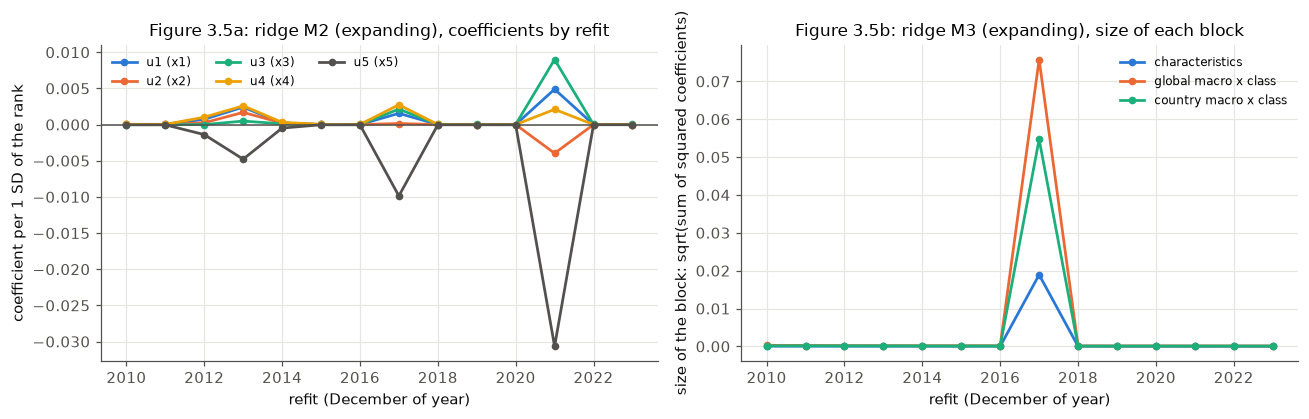

,mean coefficient,share of refits with the same sign as the mean
u1,0.001,1.000
u2,-0.000,0.429
u3,0.001,0.786
u4,0.001,1.000
u5,-0.003,1.000


lasso M3 (expanding): share of refits in which each block has at least one selected variable: {'characteristics': 0.14, 'global macro x class': 0.43, 'country macro x class': 0.21}
lasso M3 (expanding): variables selected in at least half the refits: []
PCR M3: components chosen per refit (expanding): [1, 1, 1, 3, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1]


,tuned on the validation folds (as run),best fixed value with hindsight (upper bound),that value,"first grid value (class means only for ridge, lasso, PCR K = 0)",last grid value,median validation gain of the best value over the first (%)
ridge M2,0.042%,0.087%,25.1,0.087%,-0.015%,0.000
ridge M3,-0.080%,0.086%,1e+03,0.086%,-4.709%,0.000
lasso M3,-0.132%,0.087%,0.316,0.087%,-4.698%,0.000
PCR M3 with K = 0..10,-0.095%,0.088%,1,0.087%,-1.723%,0.000


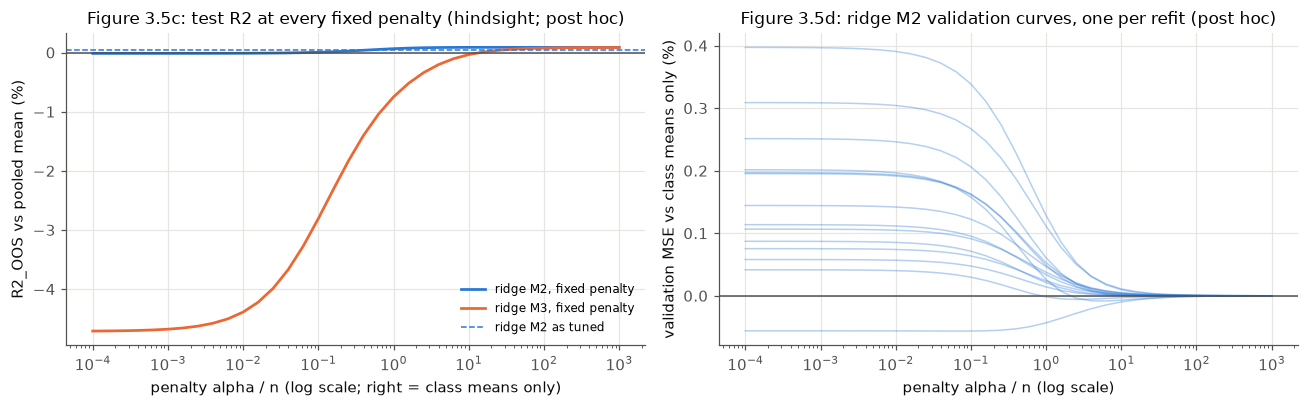

,PC1 share of variance,PC1-PC3 share of variance,PC1: characteristics,PC1: global macro x class,PC1: country macro x class,PC2: characteristics,PC2: global macro x class,PC2: country macro x class,PC3: characteristics,PC3: global macro x class,PC3: country macro x class
refit,,,,,,,,,,,
2010,0.101,0.291,0.000,0.646,0.354,0.002,0.667,0.331,0.000,0.687,0.313
2011,0.097,0.281,0.000,0.653,0.347,0.002,0.674,0.323,0.000,0.694,0.306
2012,0.094,0.273,0.000,0.660,0.340,0.002,0.681,0.316,0.001,0.705,0.294
2013,0.093,0.269,0.001,0.667,0.332,0.003,0.690,0.308,0.000,0.720,0.279
2014,0.093,0.271,0.000,0.672,0.328,0.003,0.691,0.306,0.000,0.716,0.283
2015,0.086,0.251,0.000,0.686,0.314,0.003,0.709,0.289,0.000,0.723,0.276
2016,0.082,0.238,0.001,0.699,0.300,0.002,0.730,0.269,0.000,0.739,0.261
2017,0.082,0.238,0.001,0.691,0.308,0.000,0.720,0.279,0.001,0.723,0.276
2018,0.081,0.234,0.001,0.679,0.321,0.000,0.703,0.296,0.001,0.714,0.285


largest share of the characteristics in the squared loadings of PC1-PC3, over the 14 refits: 0.003 (they are 5 of the 39 standardised columns)


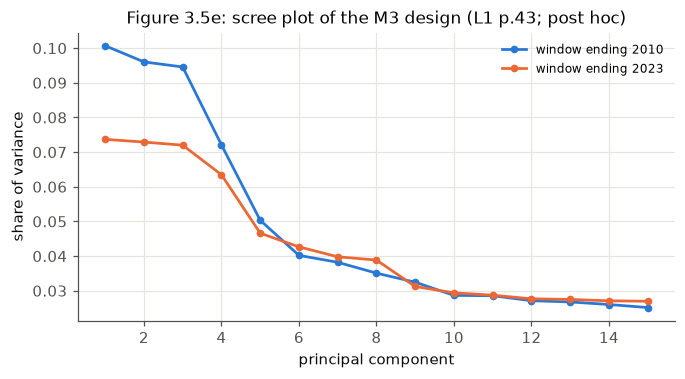

,mean over the 14 test years,years with a positive importance
dB,0.108%,9
u5,0.076%,9
dC,0.063%,8
u3,-0.007%,6
u2,-0.018%,5
u4,-0.025%,7
dD,-0.028%,8
u1,-0.028%,5


,mean over the 14 test years,years with a positive importance
g_x7,0.167%,5
dC,0.115%,9
g_x8,0.058%,7
dB,0.051%,10
g_x6,0.050%,4
u5,0.034%,11
c_x12,0.020%,8
c_x86,0.008%,7
u4,0.006%,8
dD,0.004%,8


M2: per-class minus pooled R2_OOS = 0.001% (SE 0.034%)
M3: per-class minus pooled R2_OOS = -1.086% (SE 0.386%)


,class A,class B,class C,class D,all
ridge|M2|expanding,-0.06%,1.81%,0.05%,-1.37%,0.04%
ridge-per-class|M2|expanding,-0.07%,1.94%,-0.00%,-1.39%,0.04%
ridge|M3|expanding,0.00%,1.74%,-0.88%,-1.29%,-0.08%
ridge-per-class|M3|expanding,-1.04%,-0.26%,-0.71%,-3.04%,-1.17%


training rows per class at the first refit (2010-12): {'A': 2496, 'B': 768, 'C': 864, 'D': 672} | slopes per class in M3: A 9 | B, C, D 15


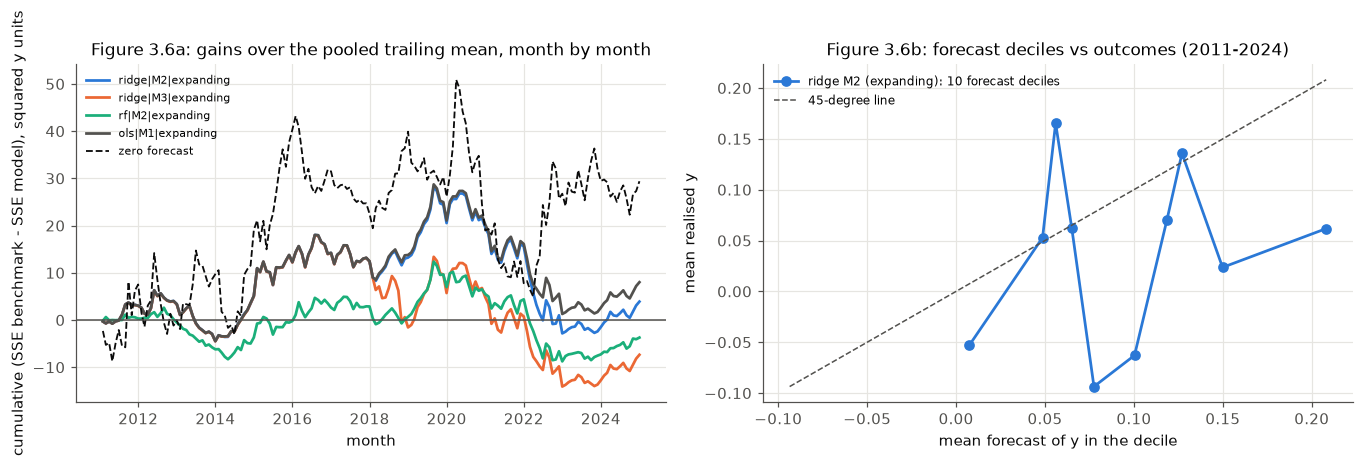

,decile 1,decile 2,decile 3,decile 4,decile 5,decile 6,decile 7,decile 8,decile 9,decile 10
forecast,0.007,0.049,0.056,0.065,0.078,0.100,0.119,0.127,0.150,0.208
realised,-0.053,0.053,0.165,0.062,-0.094,-0.063,0.070,0.136,0.024,0.062


sd of the ridge M2 forecasts 0.055 vs sd of y 1.043; corr(forecast, outcome) = 0.020


In [18]:
# ==============================================================================================================
# Section 3.5: Running the ledger   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.5: Running the ledger ====')

t0 = time.perf_counter()
def variant(**kw):
    """The same feature build with one option changed; rows must line up with the base frame."""
    Fv, _ = build_features(panel, mac_g, mac_c, mac_x, **kw)
    assert (Fv[['m', 'asset_id']].to_numpy() == F[['m', 'asset_id']].to_numpy()).all() and np.allclose(Fv.y, F.y)
    assert Fv[model_cols].notna().all().all(), f'missing predictor in variant {kw}'
    Fv['k'] = F.k.to_numpy()
    return Fv
FRAMES = {'lag1': variant(macro_lag=1), 'zscore': variant(char_std='z'),
          'x10': variant(short_rate='x10', sr_lag=14), 'x10-leak': variant(short_rate='x10', sr_lag=1)}
VARIANT_OF = {'M3-lag1': ('lag1', 'M3'), 'M2-zscore': ('zscore', 'M2'), 'M3-x10': ('x10', 'M3'), 'M3-x10-leak': ('x10-leak', 'M3')}

def class_cols(fs, c):
    """The columns that can be non-zero for class c (other classes' macro interactions are zero by construction)."""
    return [col for col in FSETS[fs] if col in CHARS or col in LEVELS or col.endswith('_' + c)]

IMPORTANCE = {}
def run_spec(model, feats, scheme):
    """Dispatch one ledger row to its runner. Returns forecasts for the 8,400 OOS rows and the refit log."""
    frame, fs = (FRAMES[VARIANT_OF[feats][0]], VARIANT_OF[feats][1]) if feats in VARIANT_OF else (None, feats)
    if model in ('ols', 'ridge', 'lasso', 'pcr'):
        return run_linear(model, FSETS[fs], scheme, frame=frame)
    if model in ('pcr-K3', 'pcr-K5'):
        return run_linear('pcr', FSETS[fs], scheme, fixed=int(model[-1]))
    if model in ('rf', 'rf-deep'):
        params = dict(RF_PARAMS, min_samples_leaf=200 if model == 'rf' else 5)
        yh, log, imp = run_rf(RF_SETS[fs], scheme, params, importance=(model == 'rf' and scheme == 'expanding'))
        if imp is not None:
            IMPORTANCE[f'rf|{fs}|expanding'] = imp
        return yh, log
    if model == 'ridge-per-class':
        yh, logs = np.full(len(OOS), np.nan), []
        for c in 'ABCD':
            p, lg = run_linear('ridge', class_cols(fs, c), scheme, rows=(F.cls == c).to_numpy())
            yh[(OOS.cls == c).to_numpy()] = p
            logs.append(lg.assign(cls=c))
        return yh, pd.concat(logs, ignore_index=True)
    raise ValueError(model)

RES, LOGS, RUNTIME = {}, {}, {}
for name, row in ledger.iterrows():
    t1 = time.perf_counter()
    RES[name], LOGS[name] = run_spec(row.model, row.features, row.scheme)
    RUNTIME[name] = time.perf_counter() - t1
    assert RES[name].shape == (len(OOS),) and np.isfinite(RES[name]).all()
LEAK_YH, LEAK_LOG = run_spec('ridge', 'M3-x10-leak', 'expanding')
print(f'{len(RES)} specifications + 1 diagnostic run in {time.perf_counter() - t0:.0f} s '
      f'(slowest: {max(RUNTIME, key=RUNTIME.get)}, {max(RUNTIME.values()):.0f} s)')

# ---------- Q1 and the model x scheme table ----------
ZERO = np.zeros(len(OOS))
rows = []
for name, row in ledger.iterrows():
    yh = RES[name]
    r2p, sep = r2_boot(yh, OOS.b_pool.to_numpy())
    r2z, sez = r2_boot(yh, ZERO)
    rows.append({'model': row.model, 'features': row.features, 'scheme': row.scheme, 'tier': row.tier,
                 'R2 vs pooled mean': r2p, 'SE': sep, 'R2 vs zero': r2z, 'SE (zero)': sez,
                 'R2 vs per-class mean': r2_oos(OOS.y, yh, OOS.b_class), 'R2 vs per-asset mean': r2_oos(OOS.y, yh, OOS.b_asset),
                 'mean IS R2': LOGS[name]['IS R2'].mean()})
res_tab = pd.DataFrame(rows, index=ledger.index)
core = res_tab[res_tab.tier == 'core']
for bn in ['R2 vs pooled mean', 'R2 vs zero']:
    piv = core.pivot_table(index=['model', 'features'], columns='scheme', values=bn, sort=False)[SCHEMES]
    display(piv.style.format('{:.2%}', na_rep='').set_caption(f'Table 3.10 (panel: {bn}): core specifications, 2011-2024 (8,400 asset-months)'))
display(res_tab.drop(columns=['model', 'features', 'scheme']).style.format({c: '{:.2%}' for c in res_tab.columns[4:]})
        .set_caption('Table 3.10b: every specification, with month-bootstrap SEs and in-sample R2'))
print(f'largest R2_OOS vs the pooled mean: {res_tab["R2 vs pooled mean"].max():.2%} ({res_tab["R2 vs pooled mean"].idxmax()}); '
      f'vs zero: {res_tab["R2 vs zero"].max():.2%} ({res_tab["R2 vs zero"].idxmax()})')
alarm = res_tab[['R2 vs pooled mean', 'R2 vs zero']].max().max() > LEAK_ALARM     # a suspiciously HIGH R2 (L5 p.57)
print('LEAK ALARM (an R2_OOS above 2% would mean: audit before interpreting):', 'TRIGGERED' if alarm else 'not triggered')
print(f"in-sample R2 exceeds R2_OOS for {(res_tab['mean IS R2'] > res_tab['R2 vs pooled mean']).sum()} of {len(res_tab)} specifications")

# Q1, pre-registered: ridge on characteristic ranks, expanding window, against the pooled trailing mean
P = 'ridge|M2|expanding'
q1, q1_se = r2_boot(RES[P], OOS.b_pool.to_numpy())
m1, m1_se = r2_boot(RES['ols|M1|expanding'], OOS.b_pool.to_numpy())
d_char, d_char_se = delta_boot(RES[P], RES['ols|M1|expanding'], OOS.b_pool.to_numpy())
q1_verdict = q1 > 0 and q1 - 2 * q1_se > 0
print(f'\nQ1 primary: R2_OOS(ridge|M2|expanding) = {q1:.3%} (SE {q1_se:.3%}); vs zero {r2_boot(RES[P], ZERO)[0]:.3%}')
print(f'   of which class intercepts alone (M1): {m1:.3%} (SE {m1_se:.3%}); characteristics beyond class means: {d_char:.3%} (SE {d_char_se:.3%})')
print(f'   pre-registered rule (R2 > 0 and more than 2 SE above 0): {"YES" if q1_verdict else "NO"}')
print(f'   characteristics beyond class means, +/- 2 SE: {d_char - 2 * d_char_se:.3%} to {d_char + 2 * d_char_se:.3%}')
q1_mde, q1_mde80 = 2 * q1_se, (2 + stats.norm.ppf(0.8)) * q1_se
print(f'   power of this statistic (added after the result): the rule needs R2_OOS > 2 SE = {q1_mde:.2%}; a true R2_OOS of '
      f'{q1_mde80:.2%} would pass it with 80% probability.\n   The Section 3.0 calculation assumed a pure within-class signal; the '
      'Q1 statistic also carries the class-intercept errors, which load on common class shocks.')

# the per-asset trailing mean of y (the literal per-series harness of HW5) is a much noisier benchmark than the pooled mean
BA = OOS.b_asset.to_numpy()
pa = pd.DataFrame({n: dict(zip(['R2 vs per-asset mean', 'SE'], r2_boot(RES[n], BA))) for n in ['ols|M1|expanding', P, 'ridge|M3|expanding']}).T
pa['R2 / SE'] = pa['R2 vs per-asset mean'] / pa['SE']
display(pa.style.format({'R2 vs per-asset mean': '{:.3%}', 'SE': '{:.3%}', 'R2 / SE': '{:.2f}'})
        .set_caption('Table 3.10c: against the per-asset trailing mean of y (2011-2024) (post hoc)'))
n_pa = int((res_tab['R2 vs per-asset mean'] > 0).sum())
print(f'specifications with R2_OOS > 0 against the per-asset mean: {n_pa} of {len(res_tab)}; '
      f'the per-asset mean itself scores {r2_oos(OOS.y, OOS.b_asset, OOS.b_pool):.2%} against the pooled mean')

# ---------- By class, by sub-period, and in raw-return units ----------
KEY = ['ols|M1|expanding', 'ols|M2|expanding', 'ridge|M2|expanding', 'rf|M2|expanding', 'ridge|M3|expanding',
       'lasso|M3|expanding', 'pcr|M3|expanding', 'rf|M3|expanding']
by_cls = pd.DataFrame({c: {n: r2_oos(OOS.y[OOS.cls == c], RES[n][OOS.cls == c], OOS.b_pool[OOS.cls == c]) for n in KEY} for c in 'ABCD'})
by_cls['all'] = [res_tab.loc[n, 'R2 vs pooled mean'] for n in KEY]
display(by_cls.style.format('{:.2%}').set_caption('Table 3.11: R2_OOS vs the pooled trailing mean, by asset class (2011-2024)'))
sub = {}
for lab, (s0, s1) in SUBPERIODS.items():
    rows_sp = ((OOS.m >= s0) & (OOS.m <= s1)).to_numpy()
    sub[lab] = {n: r2_boot(RES[n], OOS.b_pool.to_numpy(), rows_sp)[0] for n in KEY}
    sub[lab + ' (vs zero)'] = {n: r2_boot(RES[n], ZERO, rows_sp)[0] for n in KEY}
display(pd.DataFrame(sub).style.format('{:.2%}').set_caption('Table 3.12: R2_OOS by sub-period'))
# scheme differences on the same months (paired): static or rolling minus expanding
sch_rows = {}
for mdl, fs in [('ols', 'M2'), ('ols', 'M3'), ('ridge', 'M2'), ('ridge', 'M3'), ('rf', 'M2'), ('rf', 'M3'), ('lasso', 'M3'), ('pcr', 'M3')]:
    for s_ in ['static', 'rolling']:
        d, se = delta_boot(RES[f'{mdl}|{fs}|{s_}'], RES[f'{mdl}|{fs}|expanding'], OOS.b_pool.to_numpy())
        sch_rows[(f'{mdl} {fs}', f'{s_} - expanding')] = {'difference in R2_OOS': d, 'paired SE': se, 'difference / SE': d / se}
sch_tab = pd.DataFrame(sch_rows).T
display(sch_tab.style.format({'difference in R2_OOS': '{:.3%}', 'paired SE': '{:.3%}', 'difference / SE': '{:.2f}'})
        .set_caption('Table 3.12b: scheme differences, paired month bootstrap (vs the pooled trailing mean) (post hoc)'))
# raw excess returns: forecast r-hat = y-hat * sigma-hat, against the literal per-asset trailing mean of returns and zero
raw = {}
for n in KEY:
    rh = RES[n] * OOS.sig.to_numpy()
    raw[n] = {**{f'class {c}: vs asset mean': r2_oos(OOS.r[OOS.cls == c], rh[OOS.cls == c], OOS.rb_asset[OOS.cls == c]) for c in 'ABCD'},
              **{f'class {c}: vs zero': r2_oos(OOS.r[OOS.cls == c], rh[OOS.cls == c], ZERO[OOS.cls == c]) for c in 'ABCD'}}
display(pd.DataFrame(raw).T.style.format('{:.2%}').set_caption('Table 3.13: R2_OOS in raw excess-return units, by class'))

# ---------- Are the months independent? Serial dependence behind the month bootstrap (post hoc) ----------
BPOOL, BASSET = OOS.b_pool.to_numpy(), OOS.b_asset.to_numpy()
M1Y, M2Y, M3Y = RES['ols|M1|expanding'], RES['ridge|M2|expanding'], RES['ridge|M3|expanding']
def sse_m(v):
    return month_sums((OOS.y - v) ** 2)
loss_series = {'benchmark losses (pooled mean)': sse_m(BPOOL),
               'Q1: pooled mean minus ridge M2': sse_m(BPOOL) - sse_m(M2Y),
               'characteristics: class means minus ridge M2': sse_m(M1Y) - sse_m(M2Y),
               'Q2: ridge M2 minus ridge M3': sse_m(M2Y) - sse_m(M3Y)}
acf_tab = pd.DataFrame({k: {f'lag {L}': pd.Series(v).autocorr(L) for L in range(1, 7)} for k, v in loss_series.items()}).T
display(acf_tab.style.format('{:.2f}').set_caption('Table 3.12c: autocorrelation of the monthly loss series (168 months) (post hoc)'))

def block_idx(L, B=BOOT_B, seed=P3_SEED + 1):
    """Circular moving-block bootstrap of the 168 OOS months (our construction; not taught): blocks of L consecutive months."""
    rng = np.random.default_rng(seed)
    nblk = int(np.ceil(T_OOS / L))
    starts = rng.integers(0, T_OOS, size=(B, nblk))
    return ((starts[:, :, None] + np.arange(L)) % T_OOS).reshape(B, -1)[:, :T_OOS]
BLOCKS = {L: block_idx(L) for L in (6, 12)}
def delta_se(idx, yh1, yh2, bench):
    """SE of R2(yh1) - R2(yh2) against bench under resampling scheme idx (yh2 = bench gives the SE of R2(yh1) itself)."""
    e1, e2, eb = sse_m(yh1), sse_m(yh2), sse_m(bench)
    return ((e2[idx].sum(1) - e1[idx].sum(1)) / eb[idx].sum(1)).std(ddof=1)
checks = {'Q1: ridge M2 vs the pooled mean': (M2Y, BPOOL, BPOOL),
          'class means vs the pooled mean': (M1Y, BPOOL, BPOOL),
          'characteristics beyond class means': (M2Y, M1Y, BPOOL),
          'Q2: ridge M3 minus ridge M2': (M3Y, M2Y, BPOOL),
          'class means vs the per-asset mean': (M1Y, BASSET, BASSET),
          'curated x10 (14-month lag) minus x86': (RES['ridge|M3-x10|expanding'], M3Y, BPOOL),
          'OLS M2: static minus expanding': (RES['ols|M2|static'], RES['ols|M2|expanding'], BPOOL),
          'forest M2: static minus expanding': (RES['rf|M2|static'], RES['rf|M2|expanding'], BPOOL)}
dep = {}
for lab, (a_, b_, c_) in checks.items():
    est = delta_boot(a_, b_, c_)
    row = {'estimate': est[0], 'SE, months independent': est[1]}
    for L, idx in BLOCKS.items():
        row[f'SE, blocks of {L} months'] = delta_se(idx, a_, b_, c_)
    row['t, months independent'] = est[0] / est[1]
    row['t, blocks of 12'] = est[0] / row['SE, blocks of 12 months']
    dep[lab] = row
dep_tab = pd.DataFrame(dep).T
display(dep_tab.style.format({c: '{:.3%}' for c in dep_tab.columns[:4]} | {c: '{:.2f}' for c in dep_tab.columns[4:]})
        .set_caption('Table 3.12d: the month bootstrap against a moving-block bootstrap (our construction), same B = 10,000 (post hoc)'))
ratio = dep_tab['SE, blocks of 12 months'] / dep_tab['SE, months independent']
print(f'block (12-month) SE / independent-month SE: {ratio.min():.2f} to {ratio.max():.2f} (median {ratio.median():.2f})')

# ---------- Forest minus ridge on the same features, scheme and months: any exploitable nonlinearity? (post hoc) ----------
fr_rows = {}
for fs in ['M2', 'M3']:
    for sch in SCHEMES:
        d, se = delta_boot(RES[f'rf|{fs}|{sch}'], RES[f'ridge|{fs}|{sch}'], BPOOL)
        fr_rows[(fs, sch)] = {'forest minus ridge': d, 'paired SE': se, 'difference / SE': d / se}
fr_tab = pd.DataFrame(fr_rows).T
fr_tab.index.names = ['features', 'scheme']
display(fr_tab.style.format({'forest minus ridge': '{:.3%}', 'paired SE': '{:.3%}', 'difference / SE': '{:.2f}'})
        .set_caption('Table 3.12e: random forest (leaf 200) minus ridge, R2_OOS vs the pooled trailing mean (post hoc)'))

# ---------- Tuning choices, edges, and which predictors carry the signal ----------
tuned = [n for n in ledger.index if ledger.loc[n, 'model'] in ('ridge', 'lasso', 'pcr', 'ridge-per-class')]
tune_tab = pd.DataFrame({n: {'refits': len(LOGS[n]), 'share of refits at a grid edge': LOGS[n]['at grid edge'].mean(),
                             'median choice': np.median(LOGS[n]['choice'].astype(float)),
                             'min choice': LOGS[n]['choice'].astype(float).min(), 'max choice': LOGS[n]['choice'].astype(float).max()}
                         for n in tuned}).T
display(tune_tab.style.format('{:.3g}').set_caption('Table 3.14: chosen penalty (ridge: alpha/n; lasso: alpha) or number of components (PCR)'))
print('grid edges: ridge alpha/n in [1e-4, 1e3]; lasso alpha in [3e-5, 0.32]; PCR K in [1, 10]. '
      'The top edge of ridge/lasso is the class-means model ("no signal"); the bottom edge is close to OLS.')

coef = pd.DataFrame([r['coef'] for _, r in LOGS['ridge|M2|expanding'].iterrows()],
                    index=[d.year for d in LOGS['ridge|M2|expanding']['refit']])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
for cn, col in zip(CHARS, [C_BLUE, C_ORANGE, C_AQUA, C_YELLOW, C_GREY]):
    ax1.plot(coef.index, coef[cn], marker='o', markersize=4, color=col, label=f'{cn} ({XNAMES[CHARS.index(cn)]})')
ax1.axhline(0, color=C_GREY, linewidth=1)
ax1.set_xlabel('refit (December of year)')
ax1.set_ylabel('coefficient per 1 SD of the rank')
ax1.set_title('Figure 3.5a: ridge M2 (expanding), coefficients by refit')
ax1.legend(fontsize=8, ncol=3)
coef3 = pd.DataFrame([r['coef'] for _, r in LOGS['ridge|M3|expanding'].iterrows()],
                     index=[d.year for d in LOGS['ridge|M3|expanding']['refit']])
blocks = {'characteristics': CHARS, 'global macro x class': GLOB, 'country macro x class': CTRY_INT}
for (bn, cols), col in zip(blocks.items(), [C_BLUE, C_ORANGE, C_AQUA]):
    ax2.plot(coef3.index, np.sqrt((coef3[cols] ** 2).sum(axis=1)), marker='o', markersize=4, color=col, label=bn)
ax2.set_xlabel('refit (December of year)')
ax2.set_ylabel('size of the block: sqrt(sum of squared coefficients)')
ax2.set_title('Figure 3.5b: ridge M3 (expanding), size of each block')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()
stab = pd.DataFrame({'mean coefficient': coef.mean(), 'share of refits with the same sign as the mean': (np.sign(coef) == np.sign(coef.mean())).mean()})
display(stab.style.format('{:.3f}').set_caption('Table 3.15: stability of the ridge M2 coefficients across the 14 refits'))
sel = pd.DataFrame([r['coef'] for _, r in LOGS['lasso|M3|expanding'].iterrows()]).ne(0).mean()
print('lasso M3 (expanding): share of refits in which each block has at least one selected variable:',
      {bn: round(float(pd.DataFrame([r['coef'] for _, r in LOGS['lasso|M3|expanding'].iterrows()])[cols].ne(0).any(axis=1).mean()), 2)
       for bn, cols in blocks.items()})
print('lasso M3 (expanding): variables selected in at least half the refits:', list(sel[sel >= 0.5].index))
print('PCR M3: components chosen per refit (expanding):', list(LOGS['pcr|M3|expanding']['choice']))

# ---------- Does the "no" depend on tuning? R2_OOS at every fixed penalty, and the validation curves (post hoc) ----------
# Every grid value is scored on the test months as if it had been fixed in advance. The best of these is an UPPER BOUND
# chosen with hindsight: it is never used to choose anything (L5 p.58 item 4).
def path_forecasts(kind, cols, grid):
    """Expanding scheme. At every refit, fit the whole grid on the window, forecast the next 12 months for every value,
    and keep the mean validation MSE over the 3 forward folds (the curve the tuning minimised)."""
    X, y, k, m = F[cols].to_numpy(), F.y.to_numpy(), F.k.to_numpy(), F.m.to_numpy()
    pred, curves = np.full((len(F), len(grid)), np.nan), []
    for b in REFIT_ENDS:
        a, b = window('expanding', b)
        mse = np.zeros(len(grid))
        for (f0, f1), (v0, v1) in inner_folds(a, b):
            fit, val = (m >= f0) & (m <= f1), (m >= v0) & (m <= v1)
            assert m[fit].max() < m[val].min()
            mse += ((y[val][:, None] - LinearFE(kind, grid).fit(X[fit], y[fit], k[fit]).predict(X[val], k[val])) ** 2).mean(0) / 3
        curves.append(mse)
        win, test = (m >= a) & (m <= b), (m > b) & (m <= b + 12)
        assert m[win].max() < m[test].min()
        pred[test] = LinearFE(kind, grid).fit(X[win], y[win], k[win]).predict(X[test], k[test])
    return pred[F.m.to_numpy() >= OOS_M[0]], np.array(curves)

yo, om = OOS.y.to_numpy(), OOS.m.to_numpy()
den = ((yo - BPOOL) ** 2).sum()
fixed_rows, PATHS = {}, {}
for lab, kind, fs, grid, tuned in [('ridge M2', 'ridge', 'M2', GRIDS['ridge'], 'ridge|M2|expanding'),
                                   ('ridge M3', 'ridge', 'M3', GRIDS['ridge'], 'ridge|M3|expanding'),
                                   ('lasso M3', 'lasso', 'M3', GRIDS['lasso'], 'lasso|M3|expanding'),
                                   ('PCR M3 with K = 0..10', 'pcr', 'M3', [0] + list(GRIDS['pcr']), None)]:
    P_, C_ = path_forecasts(kind, FSETS[fs], grid)
    r2 = 1 - ((yo[:, None] - P_) ** 2).sum(0) / den
    choice = C_.argmin(1)                                   # the harness's rule: the first minimum = the heavier penalty
    rebuilt = np.empty(len(OOS))
    for i, b in enumerate(REFIT_ENDS):
        sel = (om > b) & (om <= b + 12)
        rebuilt[sel] = P_[sel, choice[i]]
    if tuned:                                               # the curves reproduce the ledger's own choice at every refit
        assert np.allclose(np.asarray(grid, float)[choice], LOGS[tuned]['choice'].astype(float)), lab
        if kind == 'ridge':                                 # closed form: the forecasts match exactly too (lasso's differ
            assert np.allclose(rebuilt, RES[tuned], atol=1e-10), lab   # only at solver tolerance, cold vs warm start)
    PATHS[lab] = (np.asarray(grid, float), r2, C_)
    jb = int(np.argmax(r2))
    fixed_rows[lab] = {'tuned on the validation folds (as run)': 1 - ((yo - rebuilt) ** 2).sum() / den,
                       'best fixed value with hindsight (upper bound)': r2[jb], 'that value': grid[jb],
                       'first grid value (class means only for ridge, lasso, PCR K = 0)': r2[0], 'last grid value': r2[-1],
                       'median validation gain of the best value over the first (%)': np.median(1 - C_.min(1) / C_[:, 0]) * 100}
fixed_tab = pd.DataFrame(fixed_rows).T
display(fixed_tab.style.format({c: '{:.3%}' for c in fixed_tab.columns if c not in ('that value', fixed_tab.columns[-1])}
                               | {'that value': '{:.3g}', fixed_tab.columns[-1]: '{:.3f}'})
        .set_caption('Table 3.14c: R2_OOS vs the pooled trailing mean at every fixed grid value (expanding, 2011-2024) (post hoc)'))

grid_r, r2_m2, cur_m2 = PATHS['ridge M2']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
ax1.plot(grid_r, 100 * r2_m2, color=C_BLUE, label='ridge M2, fixed penalty')
ax1.plot(grid_r, 100 * PATHS['ridge M3'][1], color=C_ORANGE, label='ridge M3, fixed penalty')
ax1.axhline(100 * fixed_tab.loc['ridge M2', 'tuned on the validation folds (as run)'], color=C_BLUE, linestyle='--', linewidth=1,
            label='ridge M2 as tuned')
ax1.axhline(0, color=C_GREY, linewidth=1)
ax1.set_xscale('log')
ax1.set_xlabel('penalty alpha / n (log scale; right = class means only)')
ax1.set_ylabel('R2_OOS vs pooled mean (%)')
ax1.set_title('Figure 3.5c: test R2 at every fixed penalty (hindsight; post hoc)')
ax1.legend(fontsize=8)
for i in range(len(cur_m2)):
    ax2.plot(grid_r, 100 * (cur_m2[i] / cur_m2[i, 0] - 1), color=C_BLUE, alpha=0.35, linewidth=1)
ax2.axhline(0, color=C_GREY, linewidth=1)
ax2.set_xscale('log')
ax2.set_xlabel('penalty alpha / n (log scale)')
ax2.set_ylabel('validation MSE vs class means only (%)')
ax2.set_title('Figure 3.5d: ridge M2 validation curves, one per refit (post hoc)')
plt.tight_layout()
plt.show()

# ---------- What PCR's components are made of (post hoc) ----------
# The same preprocessing as the harness (within-class demeaning, then a scaler, on the training window only).
blocks3 = {'characteristics': CHARS, 'global macro x class': GLOB, 'country macro x class': CTRY_INT}
Xp, kp, mp, yp = F[FSETS['M3']].to_numpy(), F.k.to_numpy(), F.m.to_numpy(), F.y.to_numpy()
pcr_rows, scree = [], {}
for b in REFIT_ENDS:
    a, b = window('expanding', b)
    win = (mp >= a) & (mp <= b)
    fe = LinearFE('pcr', [1]).fit(Xp[win], yp[win], kp[win])
    _, s_, Vt = np.linalg.svd(fe.sc.transform(Xp[win] - fe.xm[kp[win]]), full_matrices=False)
    share = s_ ** 2 / (s_ ** 2).sum()
    scree[DATES[b].year] = share
    row = {'refit': DATES[b].year, 'PC1 share of variance': share[0], 'PC1-PC3 share of variance': share[:3].sum()}
    for j in range(3):
        for bn, cols in blocks3.items():
            row[f'PC{j + 1}: {bn}'] = (Vt[j, [FSETS['M3'].index(c) for c in cols]] ** 2).sum()
    pcr_rows.append(row)
pcr_tab = pd.DataFrame(pcr_rows).set_index('refit')
display(pcr_tab.style.format('{:.3f}').set_caption("Table 3.14d: PCR's first three components (M3, expanding): share of "
                                                    "variance and share of squared loadings on each block (post hoc)"))
char_cols = [c for c in pcr_tab if c.endswith('characteristics')]
print(f"largest share of the characteristics in the squared loadings of PC1-PC3, over the 14 refits: {pcr_tab[char_cols].max().max():.3f} "
      f"(they are 5 of the 39 standardised columns)")
fig, ax = plt.subplots(figsize=(7, 3.4))
for yr, col in [(min(scree), C_BLUE), (max(scree), C_ORANGE)]:
    ax.plot(np.arange(1, 16), scree[yr][:15], 'o-', markersize=4, color=col, label=f'window ending {yr}')
ax.set_xlabel('principal component')
ax.set_ylabel('share of variance')
ax.set_title('Figure 3.5e: scree plot of the M3 design (L1 p.43; post hoc)')
ax.legend(fontsize=8)
plt.show()

# ---------- The forest: out-of-sample permutation importance, year by year (L8 p.57) ----------
imp_rows = {}
for key, imp in IMPORTANCE.items():
    mse_b = pd.Series({DATES[b + 1].year: ((OOS.y - OOS.b_pool)[(OOS.m > b) & (OOS.m <= b + 12)] ** 2).mean() for b in REFIT_ENDS})
    pts = imp.div(mse_b, axis=0)                      # increase in MSE when shuffled, in R2_OOS points
    imp_rows[key] = pts
    display(pd.DataFrame({'mean over the 14 test years': pts.mean(), 'years with a positive importance': (pts > 0).sum()})
            .sort_values('mean over the 14 test years', ascending=False).style.format({'mean over the 14 test years': '{:.3%}'})
            .set_caption(f'Table 3.16: {key}: loss of R2_OOS when one input is shuffled in its test year'))

# ---------- Per-class models vs the pooled model ----------
pc = {}
for fs in ['M2', 'M3']:
    for n in [f'ridge|{fs}|expanding', f'ridge-per-class|{fs}|expanding']:
        pc[n] = {**{f'class {c}': r2_oos(OOS.y[OOS.cls == c], RES[n][OOS.cls == c], OOS.b_pool[OOS.cls == c]) for c in 'ABCD'},
                 'all': res_tab.loc[n, 'R2 vs pooled mean']}
    d, se = delta_boot(RES[f'ridge-per-class|{fs}|expanding'], RES[f'ridge|{fs}|expanding'], OOS.b_pool.to_numpy())
    print(f'{fs}: per-class minus pooled R2_OOS = {d:.3%} (SE {se:.3%})')
display(pd.DataFrame(pc).T.style.format('{:.2%}').set_caption('Table 3.17: pooled vs per-class ridge (expanding), R2_OOS vs the pooled mean'))
first_rows = F[F.m <= INIT_END_M].groupby('cls').size()
print('training rows per class at the first refit (2010-12):', first_rows.to_dict(),
      '| slopes per class in M3: A', len(class_cols('M3', 'A')), '| B, C, D', len(class_cols('M3', 'B')))

# ---------- When do the gains accrue, and are the forecasts calibrated? ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4))
odates = DATES[OOS_M]
for n, col in [('ridge|M2|expanding', C_BLUE), ('ridge|M3|expanding', C_ORANGE), ('rf|M2|expanding', C_AQUA), ('ols|M1|expanding', C_GREY)]:
    gain = month_sums((OOS.y - OOS.b_pool) ** 2 - (OOS.y - RES[n]) ** 2)
    ax1.plot(odates, np.cumsum(gain), color=col, label=n)
gain0 = month_sums((OOS.y - OOS.b_pool) ** 2 - (OOS.y - ZERO) ** 2)
ax1.plot(odates, np.cumsum(gain0), color=C_INK, linestyle='--', linewidth=1.2, label='zero forecast')
ax1.axhline(0, color=C_GREY, linewidth=1)
ax1.set_xlabel('month')
ax1.set_ylabel('cumulative (SSE benchmark - SSE model), squared y units')
ax1.set_title('Figure 3.6a: gains over the pooled trailing mean, month by month')
ax1.legend(fontsize=7.5)
yh = RES['ridge|M2|expanding']
dec = pd.qcut(yh, 10, labels=False)
cal = pd.DataFrame({'forecast': yh, 'realised': OOS.y}).groupby(dec).mean()
ax2.plot(cal.forecast, cal.realised, 'o-', color=C_BLUE, label='ridge M2 (expanding): 10 forecast deciles')
lim = [min(cal.min()), max(cal.max())]
ax2.plot(lim, lim, color=C_GREY, linestyle='--', linewidth=1, label='45-degree line')
ax2.set_xlabel('mean forecast of y in the decile')
ax2.set_ylabel('mean realised y')
ax2.set_title('Figure 3.6b: forecast deciles vs outcomes (2011-2024)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()
cal.index = [f'decile {d + 1}' for d in cal.index]
display(cal.T.style.format('{:.3f}').set_caption('Table 3.17b: the numbers behind Figure 3.6b (mean forecast and mean realised y by forecast decile) (post hoc)'))
print(f'sd of the ridge M2 forecasts {yh.std(ddof=1):.3f} vs sd of y {OOS.y.std(ddof=1):.3f}; '
      f'corr(forecast, outcome) = {np.corrcoef(yh, OOS.y)[0, 1]:.3f}')

### 3.6 Does macro add? Placebo and robustness

- **Macro vs no macro** (the exam's "refit without it"): same rows, windows, folds and benchmark, so paired.
- **Placebo** [EXAM-DEFINED]: each raw macro series circularly shifted by $s = 36, 48, \dots, 120$ months, then the identical pipeline. Real data, wrong time.
- **Wrap-around**: target months up to $s+60$ carry some wrapped (later) macro values: 61–96 training months at the first fit and, for $s \ge 72$, OOS months too (one at $s = 72$, 49 at $s = 120$). Not strictly past data, but no better aligned with returns.
- **Rule** (our construction; cf. L4 p.26–28): macro is credited only if its gain exceeds 2 bootstrap SEs **and** every placebo gain.


==== Section 3.6: Does macro add? Placebo and robustness ====


,with macro,without macro,gain in R2_OOS from macro,SE,gain / SE
0,ols|M3|static,ols|M2|static,-19.467%,3.301%,-5.90
1,ols|M3|expanding,ols|M2|expanding,-4.698%,1.918%,-2.45
2,ols|M3|rolling,ols|M2|rolling,-5.340%,1.679%,-3.18
3,ridge|M3|static,ridge|M2|static,-0.006%,0.003%,-2.05
4,ridge|M3|expanding,ridge|M2|expanding,-0.123%,0.085%,-1.44
5,ridge|M3|rolling,ridge|M2|rolling,-0.208%,0.194%,-1.07
6,rf|M3|static,rf|M2|static,-2.961%,1.465%,-2.02
7,rf|M3|expanding,rf|M2|expanding,-1.428%,1.394%,-1.02
8,rf|M3|rolling,rf|M2|rolling,-0.952%,0.730%,-1.31
9,ridge|M3-global|expanding,ridge|M2|expanding,-0.414%,0.301%,-1.38


Q2 primary: ridge M3 - ridge M2 (expanding) = -0.123% (SE 0.085%)


,class B,class C,class D
x86,20%,26%,30%
x12,34%,46%,42%
x13,34%,36%,44%
x14,51%,62%,56%
x15,79%,80%,79%
x16,30%,44%,40%


,gain vs ridge M2,SE
shift (months),,
36,-0.327%,0.256%
48,0.125%,0.138%
60,0.070%,0.217%
72,-0.563%,0.263%
84,-0.300%,0.536%
96,-0.242%,0.215%
108,-0.027%,0.115%
120,-0.202%,0.272%


8 placebo runs in 10 s; real macro gain -0.123% ranks 4 of 9 (1 = best)
pre-registered rule (gain > 2 SE and above every placebo): NO


,first-fit training months (2003-2010) with wrapped macro,OOS target months with wrapped macro,last affected target month
shift (months),,,
36,61,0,2008-01
48,73,0,2009-01
60,85,0,2010-01
72,96,1,2011-01
84,96,13,2012-01
96,96,25,2013-01
108,96,37,2014-01
120,96,49,2015-01


checked by rebuilding: the last target month affected is m = s + 60 for s = 36 and s = 120


,36,48,60,72,84,96,108,120
global x6,-0.24,-0.35,-0.36,-0.08,0.01,-0.10,0.04,0.23
global x7,-0.18,-0.35,-0.21,-0.27,0.01,-0.14,-0.13,0.13
global x8,-0.17,-0.22,-0.46,0.03,0.51,0.25,-0.01,0.18
global x9,0.26,0.15,-0.06,-0.19,-0.22,-0.29,-0.35,-0.25
country x86,-0.22,-0.30,-0.24,-0.09,-0.12,-0.09,0.02,0.22
country x12,-0.20,-0.12,-0.05,-0.01,0.06,0.01,-0.05,0.08
country x13,0.10,-0.20,-0.18,-0.01,0.16,0.07,-0.08,0.11
country x14,-0.04,-0.15,-0.11,-0.08,0.01,0.11,0.18,0.12
country x15,-0.02,-0.04,-0.01,-0.01,0.01,0.02,0.04,-0.00
country x16,0.08,0.02,-0.13,-0.16,-0.21,-0.30,-0.35,-0.30


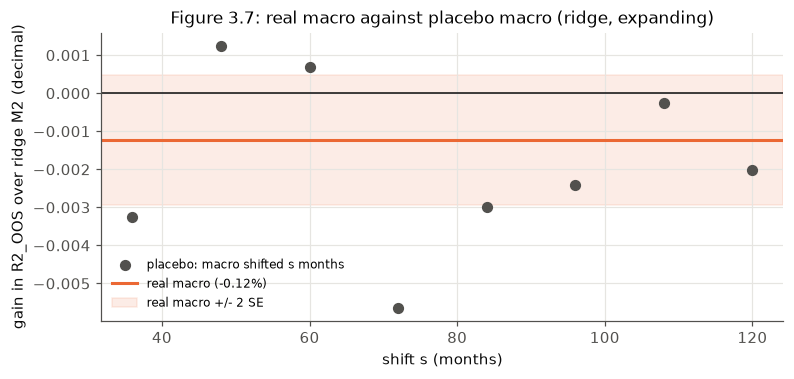

,"ridge on M2 + 20 interactions, expanding"
R2_OOS vs pooled mean (SE),0.054% (0.256%)
gain over ridge M2 (SE),0.012% (0.089%)
rank among real + 8 placebos (1 = best),6 of 9
"placebo gains, min / max",-0.006% / 0.039%
refits at the no-signal end of the ridge grid,6 of 14
Bonferroni critical |t| with this 39th test,3.28


Rule applied as for Q2 (gain > 2 SE and above every placebo): NO


,R2_OOS (variant),R2_OOS (parent),difference,SE,mean IS R2 (variant)
comparison,,,,,
PCR with K fixed at 3 vs K tuned,-0.360%,-0.171%,-0.189%,0.204%,0.596%
PCR with K fixed at 5 vs K tuned,-1.133%,-0.171%,-0.962%,0.311%,0.754%
"deep forest (leaf 5) vs leaf 200, M2",-2.233%,-0.040%,-2.192%,0.358%,27.132%
"deep forest (leaf 5) vs leaf 200, M3",-6.161%,-1.469%,-4.692%,2.409%,58.429%
macro lag 1 month vs 2,-0.452%,-0.080%,-0.372%,0.363%,1.333%
within-class z-score vs rank,0.069%,0.042%,0.027%,0.020%,0.276%
M2 + own-history levels vs M2,-0.012%,0.042%,-0.054%,0.191%,0.519%
M3 + own-history levels vs M3,-0.426%,-0.080%,-0.346%,0.288%,1.045%
curated x10 (14-month lag) vs x86,0.065%,-0.080%,0.146%,0.069%,0.304%


PCR M3 (expanding) with K = 0 allowed: R2_OOS -0.095% vs -0.171% on the pre-registered grid (difference 0.076%, SE 0.067%); K = 0 chosen in 8 of 14 refits; choices [0, 0, 0, 3, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1]


,R2 vs pooled mean,R2 vs zero,mean IS R2
x86 at a 2-month lag (headline),-0.080%,-0.402%,0.402%
"x10 at a 14-month lag (curated file, no look-ahead)",0.065%,-0.256%,0.304%
"x10 at a 1-month lag (LEAK DEMONSTRATION, not a result)",-0.050%,-0.371%,0.418%


refits (of 14) in which ridge left the no-signal end of its grid: x86 1, x10 at 14 months 1, x10 leaked 3


,all 168 months,without 2020-03..05,without the 10 stale-x1 rows
ols|M1|expanding,0.087%,0.080%,0.071%
ols|M2|expanding,-0.015%,-0.020%,-0.031%
ridge|M2|expanding,0.042%,0.032%,0.026%
rf|M2|expanding,-0.040%,-0.030%,-0.054%
ridge|M3|expanding,-0.080%,-0.100%,-0.097%
lasso|M3|expanding,-0.132%,-0.155%,-0.148%
pcr|M3|expanding,-0.171%,-0.200%,-0.195%
rf|M3|expanding,-1.469%,-1.708%,-1.496%


In [19]:
# ==============================================================================================================
# Section 3.6: Does macro add? Placebo and robustness   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.6: Does macro add? Placebo and robustness ====')

# ---------- Macro vs no macro: same model, same rows, same benchmark ----------
BP = OOS.b_pool.to_numpy()
pairs = ([(f'{mdl}|M3|{sch}', f'{mdl}|M2|{sch}') for mdl in ['ols', 'ridge', 'rf'] for sch in SCHEMES]
         + [('ridge|M3-global|expanding', 'ridge|M2|expanding'), ('ridge|M3-country|expanding', 'ridge|M2|expanding'),
            ('ridge-per-class|M3|expanding', 'ridge-per-class|M2|expanding'), ('ridge|M3-levels|expanding', 'ridge|M2-levels|expanding'),
            ('rf-deep|M3|expanding', 'rf-deep|M2|expanding')])
mac = pd.DataFrame([dict(zip(['with macro', 'without macro'], p)) | dict(zip(['gain in R2_OOS from macro', 'SE'], delta_boot(RES[p[0]], RES[p[1]], BP)))
                    for p in pairs])
mac['gain / SE'] = mac['gain in R2_OOS from macro'] / mac['SE']
display(mac.style.format({'gain in R2_OOS from macro': '{:.3%}', 'SE': '{:.3%}', 'gain / SE': '{:.2f}'})
        .set_caption('Table 3.18: what macro adds to each model (R2_OOS vs the pooled trailing mean, 2011-2024)'))
q2_gain, q2_se = delta_boot(RES['ridge|M3|expanding'], RES['ridge|M2|expanding'], BP)
print(f'Q2 primary: ridge M3 - ridge M2 (expanding) = {q2_gain:.3%} (SE {q2_se:.3%})')

# global macro is one number per month (a class-level signal); country macro also varies across countries within a month
xs_share = {}
for c in 'BCD':
    sub_c = F[F.cls == c]
    xs_share[f'class {c}'] = {k: (sub_c['c_' + k] - sub_c.groupby('m')['c_' + k].transform('mean')).var() / sub_c['c_' + k].var()
                              for k, _, _ in C_SER}
xs_share = pd.DataFrame(xs_share)
display(xs_share.style.format('{:.0%}').set_caption('Table 3.18b: share of the variance of each country-macro input that lies across countries within a month (post hoc)'))

# ---------- Placebo: every macro series circularly shifted by s months (real data at the wrong time) ----------
t0 = time.perf_counter()
placebo = {}
for s in PLACEBO_SHIFTS:
    yh_s, _ = run_linear('ridge', FSETS['M3'], 'expanding', frame=variant(shift=s))
    placebo[s] = delta_boot(yh_s, RES['ridge|M2|expanding'], BP)
plac = pd.DataFrame(placebo, index=['gain vs ridge M2', 'SE']).T
plac.index.name = 'shift (months)'
display(plac.style.format('{:.3%}').set_caption('Table 3.19: placebo gains of ridge M3 (expanding) over ridge M2'))
print(f'{len(PLACEBO_SHIFTS)} placebo runs in {time.perf_counter() - t0:.0f} s; real macro gain {q2_gain:.3%} ranks '
      f'{1 + (plac["gain vs ridge M2"] > q2_gain).sum()} of {len(PLACEBO_SHIFTS) + 1} (1 = best)')
q2_verdict = (q2_gain > 2 * q2_se) and (q2_gain > plac['gain vs ridge M2'].max())
print(f'pre-registered rule (gain > 2 SE and above every placebo): {"YES" if q2_verdict else "NO"}')

# where the circular shift wraps: a target month m uses raw macro months m-61..m-2, so m <= s + 58 + MACRO_LAG is touched
last_touched = {s: s + 58 + MACRO_LAG for s in PLACEBO_SHIFTS}
wrap = pd.DataFrame({s: {'first-fit training months (2003-2010) with wrapped macro': min(t, INIT_END_M) - FIRST_M + 1,
                         'OOS target months with wrapped macro': max(0, t - INIT_END_M),
                         'last affected target month': DATES[t].strftime('%Y-%m')} for s, t in last_touched.items()}).T
wrap.index.name = 'shift (months)'
display(wrap.style.set_caption('Table 3.19b: where the circular shift puts end-of-sample macro values (post hoc)'))
def touched_months(s):
    """Rebuild the placebo features after perturbing the last s raw macro months: rows that change use wrapped values."""
    cut = DATES[len(DATES) - s]
    bump = lambda d, cols: d.assign(**{c: np.where(d.date >= cut, d[c] * 1.1 + 0.05, d[c]) for c in cols})
    Fa, _ = build_features(panel, mac_g, mac_c, mac_x, shift=s)
    Fb, _ = build_features(panel, bump(mac_g, G_SER), bump(mac_c, [k for k, f, _ in C_SER if f == 'curated']),
                           bump(mac_x, [k for k, f, _ in C_SER if f == 'extended']), shift=s)
    mcols = GLOB + CTRY_INT
    changed = (Fa[mcols] - Fb[mcols]).abs().max(axis=1) > 1e-8      # pandas' rolling sums leave round-off of ~1e-11 behind
    return Fa.m[changed].max()
for s in (PLACEBO_SHIFTS[0], PLACEBO_SHIFTS[-1]):
    assert touched_months(s) == last_touched[s], s
print(f'checked by rebuilding: the last target month affected is m = s + {58 + MACRO_LAG} for s = {PLACEBO_SHIFTS[0]} and s = {PLACEBO_SHIFTS[-1]}')

# how correlated each lag-ready macro input stays with its own shifted copy (why several shifts are needed)
pers = {}
for k in G_SER:
    z = AUX['GZ'][k]
    pers[f'global {k}'] = {s: z.corr(z.shift(s)) for s in PLACEBO_SHIFTS}
for k, _, _ in C_SER:
    Z = AUX['CZ'][k].drop(columns='country_7')
    pers[f'country {k}'] = {s: np.nanmean([Z[c].corr(Z[c].shift(s)) for c in Z]) for s in PLACEBO_SHIFTS}
display(pd.DataFrame(pers).T.style.format('{:.2f}').set_caption('Table 3.20: corr(input, input shifted s months), the persistence a placebo inherits'))

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.scatter(plac.index, plac['gain vs ridge M2'], color=C_GREY, s=40, label='placebo: macro shifted s months', zorder=3)
ax.axhline(q2_gain, color=C_ORANGE, linewidth=2, label=f'real macro ({q2_gain:.2%})')
ax.axhspan(q2_gain - 2 * q2_se, q2_gain + 2 * q2_se, color=C_ORANGE, alpha=0.12, label='real macro +/- 2 SE')
ax.axhline(0, color=C_INK, linewidth=1)
ax.set_xlabel('shift s (months)')
ax.set_ylabel('gain in R2_OOS over ridge M2 (decimal)')
ax.set_title('Figure 3.7: real macro against placebo macro (ridge, expanding)')
ax.legend(fontsize=8, loc='lower left')
plt.show()

# ---------- Characteristic x macro-state interactions (post hoc: a 39th specification, with its own placebos) ----------
# Each characteristic rank times each lagged global macro z-score: a macro channel that varies WITHIN a class-month.
INTER = [f'i_{u}_{g}' for u in CHARS for g in G_SER]
def add_inter(fr):
    fr = fr.copy()
    for u in CHARS:
        for g in G_SER:
            fr[f'i_{u}_{g}'] = fr[u] * fr['g_' + g]
    return fr
F = add_inter(F)
assert F[INTER].notna().all().all()
YH_INT, LOG_INT = run_linear('ridge', CHARS + INTER, 'expanding')
int_r2, int_r2_se = r2_boot(YH_INT, BP)
int_gain, int_se = delta_boot(YH_INT, RES['ridge|M2|expanding'], BP)
plac_int = {}
for s in PLACEBO_SHIFTS:
    yh_s, _ = run_linear('ridge', CHARS + INTER, 'expanding', frame=add_inter(variant(shift=s)))
    plac_int[s] = delta_boot(yh_s, RES['ridge|M2|expanding'], BP)[0]
plac_int = pd.Series(plac_int, name='placebo gain over ridge M2')
bonf39 = stats.t.ppf(1 - 0.025 / 39, T_OOS - 1)
int_tab = pd.Series({'R2_OOS vs pooled mean (SE)': f'{int_r2:.3%} ({int_r2_se:.3%})',
                     'gain over ridge M2 (SE)': f'{int_gain:.3%} ({int_se:.3%})',
                     'rank among real + 8 placebos (1 = best)': f'{1 + int((plac_int > int_gain).sum())} of 9',
                     'placebo gains, min / max': f'{plac_int.min():.3%} / {plac_int.max():.3%}',
                     'refits at the no-signal end of the ridge grid': f"{(LOG_INT['choice'] == GRIDS['ridge'][0]).sum()} of {len(LOG_INT)}",
                     'Bonferroni critical |t| with this 39th test': f'{bonf39:.2f}'}, name='ridge on M2 + 20 interactions, expanding')
display(int_tab.to_frame().style.set_caption('Table 3.19c: characteristic x global-macro interactions (post hoc)'))
print('Rule applied as for Q2 (gain > 2 SE and above every placebo): '
      + ('YES' if (int_gain > 2 * int_se and int_gain > plac_int.max()) else 'NO'))

# ---------- Robustness and the pre-listed extras, each against its parent ----------
rob_pairs = [('pcr-K3|M3|expanding', 'pcr|M3|expanding', 'PCR with K fixed at 3 vs K tuned'),
             ('pcr-K5|M3|expanding', 'pcr|M3|expanding', 'PCR with K fixed at 5 vs K tuned'),
             ('rf-deep|M2|expanding', 'rf|M2|expanding', 'deep forest (leaf 5) vs leaf 200, M2'),
             ('rf-deep|M3|expanding', 'rf|M3|expanding', 'deep forest (leaf 5) vs leaf 200, M3'),
             ('ridge|M3-lag1|expanding', 'ridge|M3|expanding', 'macro lag 1 month vs 2'),
             ('ridge|M2-zscore|expanding', 'ridge|M2|expanding', 'within-class z-score vs rank'),
             ('ridge|M2-levels|expanding', 'ridge|M2|expanding', 'M2 + own-history levels vs M2'),
             ('ridge|M3-levels|expanding', 'ridge|M3|expanding', 'M3 + own-history levels vs M3'),
             ('ridge|M3-x10|expanding', 'ridge|M3|expanding', 'curated x10 (14-month lag) vs x86')]
rob = pd.DataFrame([{'comparison': lab, 'R2_OOS (variant)': res_tab.loc[a, 'R2 vs pooled mean'],
                     'R2_OOS (parent)': res_tab.loc[b, 'R2 vs pooled mean'],
                     **dict(zip(['difference', 'SE'], delta_boot(RES[a], RES[b], BP))),
                     'mean IS R2 (variant)': res_tab.loc[a, 'mean IS R2']} for a, b, lab in rob_pairs]).set_index('comparison')
display(rob.style.format('{:.3%}').set_caption('Table 3.21: robustness checks (R2_OOS vs the pooled trailing mean)'))

# PCR's pre-registered grid starts at K = 1, while ridge and lasso can reach the class-means model. Added after the ledger
# (not a candidate): allow K = 0, i.e. class means only.
PCR0_YH, PCR0_LOG = run_linear('pcr', FSETS['M3'], 'expanding', grid=[0] + list(GRIDS['pcr']))
pcr0_d, pcr0_se = delta_boot(PCR0_YH, RES['pcr|M3|expanding'], BP)
print(f"PCR M3 (expanding) with K = 0 allowed: R2_OOS {r2_oos(OOS.y, PCR0_YH, BP):.3%} vs {res_tab.loc['pcr|M3|expanding', 'R2 vs pooled mean']:.3%} "
      f"on the pre-registered grid (difference {pcr0_d:.3%}, SE {pcr0_se:.3%}); K = 0 chosen in {(PCR0_LOG['choice'] == 0).sum()} of {len(PCR0_LOG)} refits; "
      f"choices {list(PCR0_LOG['choice'])}")

# the x10 trap, three ways: the headline (x86, lag 2), the curated file at a correct lag, and the naive 1-month lag
x10_tab = pd.DataFrame({
    'x86 at a 2-month lag (headline)': {'R2 vs pooled mean': res_tab.loc['ridge|M3|expanding', 'R2 vs pooled mean'],
                                         'R2 vs zero': res_tab.loc['ridge|M3|expanding', 'R2 vs zero'],
                                         'mean IS R2': res_tab.loc['ridge|M3|expanding', 'mean IS R2']},
    'x10 at a 14-month lag (curated file, no look-ahead)': {'R2 vs pooled mean': res_tab.loc['ridge|M3-x10|expanding', 'R2 vs pooled mean'],
                                                            'R2 vs zero': res_tab.loc['ridge|M3-x10|expanding', 'R2 vs zero'],
                                                            'mean IS R2': res_tab.loc['ridge|M3-x10|expanding', 'mean IS R2']},
    'x10 at a 1-month lag (LEAK DEMONSTRATION, not a result)': {'R2 vs pooled mean': r2_oos(OOS.y, LEAK_YH, BP),
                                                                'R2 vs zero': r2_oos(OOS.y, LEAK_YH, ZERO),
                                                                'mean IS R2': LEAK_LOG['IS R2'].mean()}}).T
display(x10_tab.style.format('{:.3%}').set_caption('Table 3.22: the x10 trap (ridge M3, expanding)'))
top = GRIDS['ridge'][0]                                   # the no-signal end of the ridge grid (class means only)
print('refits (of 14) in which ridge left the no-signal end of its grid: '
      f'x86 {(LOGS["ridge|M3|expanding"]["choice"] < top).sum()}, x10 at 14 months {(LOGS["ridge|M3-x10|expanding"]["choice"] < top).sum()}, '
      f'x10 leaked {(LEAK_LOG["choice"] < top).sum()}')

# evaluation-only cuts: the same forecasts scored without COVID's first months or without the stale-x1 rows
covid = ~OOS.date.between('2020-03-31', '2020-05-31').to_numpy()
stale = ~pd.Series(list(zip(OOS.asset_id, OOS.date))).isin(FROZEN_ROWS).to_numpy()
assert (~stale).sum() == len(FROZEN_ROWS)
cuts = pd.DataFrame({n: {'all 168 months': res_tab.loc[n, 'R2 vs pooled mean'],
                         'without 2020-03..05': r2_boot(RES[n], BP, covid)[0],
                         'without the 10 stale-x1 rows': r2_boot(RES[n], BP, stale)[0]} for n in KEY}).T
display(cuts.style.format('{:.3%}').set_caption('Table 3.23: evaluation-only cuts (no refitting)'))

### 3.7 From forecasts to portfolios

- **P1** (primary): $w_{i,t}\propto \hat y_{i,t}/\hat\sigma_{i,t-1}$, the tilt $\hat r/\hat\sigma^2$; a constant forecast gives exactly RP, the natural bar.
- **P3**: $w_{i,t}\propto(\hat y_{i,t}-\bar{\hat y}_{\text{class},t})/\hat\sigma_{i,t-1}$, long–short within class.
- **P1 on M1** (class means): what class premia alone do.
- **P1 on ridge M2, static and rolling** (post hoc; not Q3 candidates): frozen 2010 fit vs re-estimated tilt; scheme dependence.
- **Class risk budget** (our choice): class sleeves scaled by the inverse trailing 36-month volatility of the class's **RP** sleeve, for RP and P1 alike, so both have identical class shares (Table 3.28). No covariance inversion: a 50 × 50 sample covariance is rank-deficient on 36 months (L1 p.63).
- **Costs** (our assumption): 10 bp per unit of $\sum_i|\Delta w_{i}|$, all strategies; 0–50 bp grid and break-evens.
- **Exposure vs timing**: net P1 on the three net benchmarks (L2 p.49, p.94–97; L3 p.19–21); α is what the rules cannot replicate; individual β's unstable (L3 p.39–44).


==== Section 3.7: From forecasts to portfolios ====


,2011-2017,2018-2024
EW,-0.02,0.53
RP,0.37,0.24
TSMOM,0.29,-0.06
"RP, class risk budget",0.63,0.04
P1 ridge M2 (primary),0.58,0.32
P1 ridge M3,0.58,0.24
P3 ridge M2,-0.07,-0.17
P3 ridge M3,-0.31,-0.66
P1 class means (M1),0.58,0.32
"P1 ridge M2, static (one fit, 2010-12)",0.33,0.21


,0 bp,5 bp,10 bp,25 bp,50 bp,break-even cost (bp): net mean = 0,cost (bp) at which P1-M2 = EW,cost (bp) at which P1-M2 = RP,cost (bp) at which P1-M2 = TSMOM
EW,0.28,0.28,0.28,0.27,0.25,516.71,,,
RP,0.31,0.30,0.30,0.29,0.27,380.58,,,
TSMOM,0.20,0.16,0.12,0.00,-0.19,25.27,,,
"RP, class risk budget",0.30,0.30,0.29,0.28,0.25,323.95,,,
P1 ridge M2 (primary),0.46,0.45,0.44,0.43,0.40,373.97,259.72,362.97,
P1 ridge M3,0.41,0.40,0.39,0.37,0.33,258.01,,,
P3 ridge M2,0.08,-0.02,-0.11,-0.41,-0.89,4.11,,,
P3 ridge M3,0.04,-0.23,-0.49,-1.27,-2.53,0.68,,,
P1 class means (M1),0.45,0.44,0.44,0.42,0.40,417.11,,,
"P1 ridge M2, static (one fit, 2010-12)",0.28,0.27,0.27,0.25,0.23,313.92,,,


(a blank break-even means the two net Sharpe curves do not cross between 0 and 500 bp)


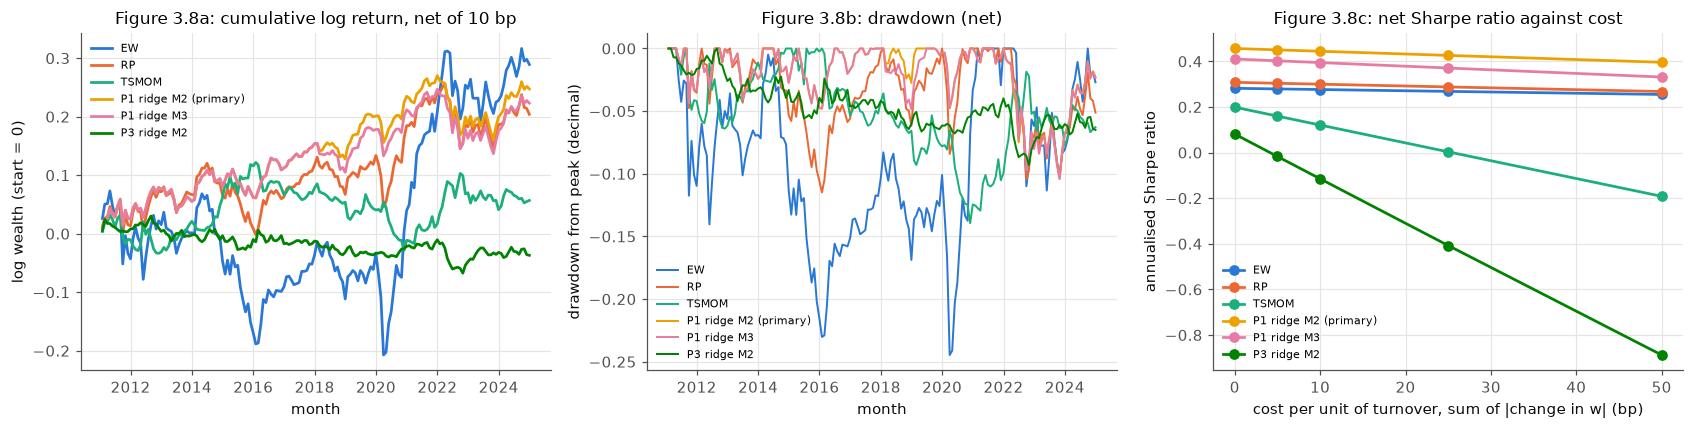

,alpha (annualised),t(alpha),R2,beta EW,beta RP,beta TS,beta M1
P1 on EW + RP + TSMOM,0.006,1.744,0.904,-0.303,1.212,0.100,
P1 on RP alone,0.007,1.591,0.845,,0.719,,
P1 on EW + RP + TSMOM + class-means tilt,0.000,0.815,0.998,-0.022,0.067,0.008,0.947
P1 (M3) on EW + RP + TSMOM,0.004,1.115,0.896,-0.313,1.242,0.108,
P1 class means (M1) on EW + RP + TSMOM,0.006,1.648,0.897,-0.296,1.208,0.098,
P1 static (M2) on EW + RP + TSMOM,-0.002,-0.914,0.983,-0.028,0.962,0.009,


P1 on RP alone: beta = 0.719 (SE 0.024); t for beta = 1: -11.76


,months,alpha (annualised),t(alpha),R2
2011-2017,84,-0.162%,-0.37,0.930
2018-2024,84,1.358%,2.47,0.902


,value
"avg monthly corr(P1 weights, RP weights)",0.935
"avg monthly corr(P1 weights, TSMOM weights)",0.251
share of months P1 is net short at least one class,0.143
P1 average net exposure (sum of w),0.989
P1 largest single |weight|,0.418
P1 asset_16 average |weight|,0.216


,A,B,C,D
RP,0.258,0.215,0.154,0.373
P1 ridge M2 (primary),0.175,0.070,0.156,0.600
"P1 ridge M2, class risk budget",0.143,0.249,0.144,0.464
"RP, class risk budget",0.143,0.249,0.144,0.464


,class-D share: RP,class-D share: P1 class means (M1),class-D share: P1 ridge M2 (primary),"class-D share: P1 ridge M2, static (one fit, 2010-12)",class A: forecast of y,class B: forecast of y,class C: forecast of y,class D: forecast of y
year,,,,,,,,
2011,0.381,0.450,0.450,0.450,0.150,0.122,0.087,0.169
2012,0.378,0.546,0.546,0.449,0.126,0.111,0.066,0.210
2013,0.360,0.535,0.535,0.431,0.119,0.105,0.084,0.215
2014,0.358,0.497,0.496,0.429,0.101,0.086,0.116,0.177
2015,0.344,0.584,0.584,0.416,0.081,0.047,0.120,0.216
2016,0.360,0.669,0.669,0.432,0.055,0.022,0.116,0.216
2017,0.357,0.648,0.648,0.430,0.062,0.015,0.124,0.213
2018,0.363,0.619,0.619,0.436,0.061,0.027,0.137,0.203
2019,0.381,0.697,0.697,0.454,0.050,0.011,0.113,0.198


,studentized residual,leverage
2011-09-30 00:00:00,-3.223,0.184
2012-05-31 00:00:00,-0.161,0.100
2018-01-31 00:00:00,-2.758,0.014
2020-03-31 00:00:00,-0.514,0.092
2021-02-28 00:00:00,-0.362,0.072
2021-04-30 00:00:00,-1.716,0.079
2021-06-30 00:00:00,2.512,0.015
2022-01-31 00:00:00,-0.011,0.112
2022-03-31 00:00:00,-0.431,0.084
2022-04-30 00:00:00,0.949,0.121


alpha, all 168 months: 0.61% a year (t = 1.74); without the 6 flagged months: 0.69% (t = 2.20).
   Reported only: L3 p.17 allows deleting a point only for a good reason, and the Q3 verdict is fixed by the pre-registered rule on all months.


,EW,RP,TS
EW,1.00,0.93,-0.21
RP,0.93,1.00,-0.27
TS,-0.21,-0.27,1.00


,estimate,textbook SE,"bootstrap SE (months resampled, refit)","t, textbook","t, bootstrap"
alpha (annualised),0.0061,0.0035,0.0035,1.7445,1.7411
beta EW,-0.3031,0.0318,0.0282,-9.5402,-10.7565
beta RP,1.2118,0.0538,0.0455,22.5314,26.6482
beta TS,0.1003,0.0261,0.0341,3.8366,2.9422


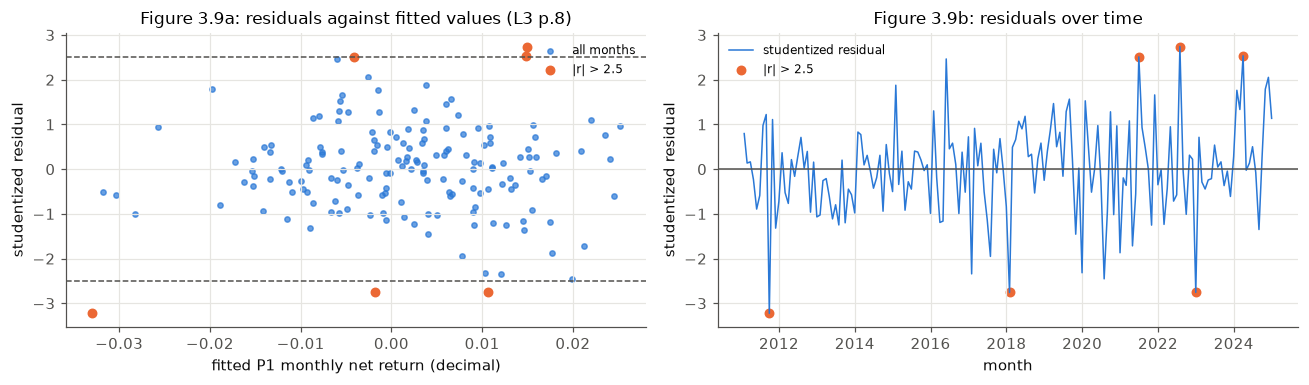

,net Sharpe P1 - benchmark,bootstrap SE,difference / SE
EW,0.168,0.181,0.927
RP,0.144,0.109,1.323
TSMOM,0.324,0.414,0.782
"RP, class risk budget",0.153,0.098,1.565
"P1 ridge M2, static (one fit, 2010-12)",0.178,0.109,1.638


Q3: net Sharpe P1 = 0.44; beats EW: True, RP: True, TSMOM: True; alpha t = 1.74 -> pre-registered rule: NO


,2003-2010 (training),2011-2019,2020-2024
within A,0.25,0.19,0.21
within B,0.52,0.51,0.68
within C,0.76,0.66,0.77
within D,0.59,0.61,0.59
A-C (commodity-like vs equity-like),0.22,0.14,0.22
C-D (equity-like vs bond-like),-0.17,-0.23,0.22
B-C,0.26,0.20,0.44
"first principal component, share of variance",0.29,0.26,0.30


In [20]:
# ==============================================================================================================
# Section 3.7: From forecasts to portfolios   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.7: From forecasts to portfolios ====')

OOS_IDX = DATES[OOS_M]
assert list(OOS.asset_id[:50]) == IDS and (OOS.m.to_numpy().reshape(T_OOS, 50) == OOS_M[:, None]).all()
def yh_wide(name):
    """Forecasts of one specification as a (month x asset) table."""
    return pd.DataFrame(np.asarray(RES[name]).reshape(T_OOS, 50), index=OOS_IDX, columns=IDS)

# class risk budget: each class sleeve (unit gross within the class) scaled by 1 / its trailing 36-month volatility
def within_class_unit(W):
    out = W.copy()
    for c in 'ABCD':
        cols = CLS_S.index[CLS_S == c]
        out[cols] = unit_gross(W[cols])
    return out
sleeve_ret = pd.DataFrame({c: port_ret(unit_gross((1.0 / SIG_W.loc[bench_idx])[CLS_S.index[CLS_S == c]])) for c in 'ABCD'})
sleeve_vol = sleeve_ret.rolling(36, min_periods=36).std(ddof=1).shift(1)          # known at the end of t-1
def class_budget(W):
    scale = (1.0 / sleeve_vol.loc[W.index])[CLS_S[W.columns].to_numpy()].to_numpy()
    return unit_gross(within_class_unit(W) * scale)
assert sleeve_vol.loc[OOS_IDX].notna().all().all()

STRATS = {'EW': W_EW.loc[OOS_IDX], 'RP': W_RP.loc[OOS_IDX], 'TSMOM': W_TS.loc[OOS_IDX],
          'RP, class risk budget': class_budget(1.0 / SIG_W.loc[OOS_IDX]),
          'P1 ridge M2 (primary)': weights_from_forecast(yh_wide('ridge|M2|expanding'), 'P1'),
          'P1 ridge M3': weights_from_forecast(yh_wide('ridge|M3|expanding'), 'P1'),
          'P3 ridge M2': weights_from_forecast(yh_wide('ridge|M2|expanding'), 'P3'),
          'P3 ridge M3': weights_from_forecast(yh_wide('ridge|M3|expanding'), 'P3'),
          'P1 class means (M1)': weights_from_forecast(yh_wide('ols|M1|expanding'), 'P1'),
          'P1 ridge M2, static (one fit, 2010-12)': weights_from_forecast(yh_wide('ridge|M2|static'), 'P1'),
          'P1 ridge M2, rolling (not selected)': weights_from_forecast(yh_wide('ridge|M2|rolling'), 'P1'),
          'P1 ridge M2, class risk budget': class_budget(yh_wide('ridge|M2|expanding') / SIG_W.loc[OOS_IDX])}
for k, W in STRATS.items():
    assert np.allclose(W.abs().sum(axis=1), 1), k
S_RET = {k: port_ret(W) for k, W in STRATS.items()}
S_TO = {k: (BENCH_TO[k].loc[OOS_IDX] if k in BENCH_TO else turnover(W)) for k, W in STRATS.items()}

rows = {}
for k in STRATS:
    rows[(k, 'gross')] = perf(S_RET[k], S_TO[k], OOS_M)
    rows[(k, f'net {HEADLINE_BP} bp')] = perf(S_RET[k], S_TO[k], OOS_M, HEADLINE_BP)
port_tab = pd.DataFrame(rows).T
display(port_tab.style.format('{:.3f}').set_caption('Table 3.24: portfolios, 2011-2024 (168 months; the P1 static and rolling rows are post hoc)'))
subp = pd.DataFrame({lab: {k: perf(S_RET[k], S_TO[k], np.arange(s0, s1 + 1), HEADLINE_BP)['Sharpe'] for k in STRATS}
                     for lab, (s0, s1) in SUBPERIODS.items()})
display(subp.style.format('{:.2f}').set_caption(f'Table 3.25: net Sharpe ratio ({HEADLINE_BP} bp) by sub-period (the P1 static and rolling rows are post hoc)'))

# ---------- Costs: net Sharpe on a grid, and break-even costs ----------
from scipy.optimize import brentq
def net_sharpe(k, bp):
    return perf(S_RET[k], S_TO[k], OOS_M, bp)['Sharpe']
cost_tab = pd.DataFrame({f'{bp} bp': {k: net_sharpe(k, bp) for k in STRATS} for bp in COST_BP})
g = {k: perf(S_RET[k], S_TO[k], OOS_M) for k in STRATS}
cost_tab['break-even cost (bp): net mean = 0'] = [1e4 * g[k]['ann. mean'] / 12 / g[k]['turnover / month'] for k in STRATS]
def breakeven_vs(k, b, hi=500):
    f = lambda bp: net_sharpe(k, bp) - net_sharpe(b, bp)
    return brentq(f, 0, hi) if f(0) * f(hi) < 0 else np.nan
for b in ['EW', 'RP', 'TSMOM']:
    cost_tab[f'cost (bp) at which P1-M2 = {b}'] = [breakeven_vs('P1 ridge M2 (primary)', b) if k == 'P1 ridge M2 (primary)' else np.nan for k in STRATS]
display(cost_tab.style.format('{:.2f}', na_rep='').set_caption('Table 3.26: net Sharpe ratio against the cost per unit of turnover (sum of |change in w|; the P1 static and rolling rows are post hoc)'))
print('(a blank break-even means the two net Sharpe curves do not cross between 0 and 500 bp)')

show = ['EW', 'RP', 'TSMOM', 'P1 ridge M2 (primary)', 'P1 ridge M3', 'P3 ridge M2']
cols6 = [C_BLUE, C_ORANGE, C_AQUA, C_YELLOW, '#e87ba4', '#008300']
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4))
for k, col in zip(show, cols6):
    r = S_RET[k] - HEADLINE_BP / 1e4 * S_TO[k].where(S_TO[k].index != OOS_IDX[0], 0.0)
    w = (1 + r).cumprod()
    axes[0].plot(OOS_IDX, np.log(w), color=col, label=k)
    axes[1].plot(OOS_IDX, -(1 - w / w.cummax()), color=col, linewidth=1.3, label=k)
    axes[2].plot(COST_BP, [net_sharpe(k, bp) for bp in COST_BP], marker='o', color=col, label=k)
axes[0].set_title(f'Figure 3.8a: cumulative log return, net of {HEADLINE_BP} bp')
axes[0].set_xlabel('month')
axes[0].set_ylabel('log wealth (start = 0)')
axes[1].set_title('Figure 3.8b: drawdown (net)')
axes[1].set_xlabel('month')
axes[1].set_ylabel('drawdown from peak (decimal)')
axes[2].set_title('Figure 3.8c: net Sharpe ratio against cost')
axes[2].set_xlabel('cost per unit of turnover, sum of |change in w| (bp)')
axes[2].set_ylabel('annualised Sharpe ratio')
for ax in axes:
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# ---------- Exposure vs timing: regress P1 on the benchmark rules (net of costs) ----------
import statsmodels.formula.api as smf
def net_ret(k):
    to = S_TO[k].copy()
    to.iloc[0] = 0.0
    return S_RET[k] - HEADLINE_BP / 1e4 * to
dfp = pd.DataFrame({'P1': net_ret('P1 ridge M2 (primary)'), 'EW': net_ret('EW'), 'RP': net_ret('RP'), 'TS': net_ret('TSMOM'),
                    'M1': net_ret('P1 class means (M1)'), 'P1_M3': net_ret('P1 ridge M3'),
                    'P1_static': net_ret('P1 ridge M2, static (one fit, 2010-12)')})
att = {}
for lab, formula in [('P1 on EW + RP + TSMOM', 'P1 ~ EW + RP + TS'), ('P1 on RP alone', 'P1 ~ RP'),
                     ('P1 on EW + RP + TSMOM + class-means tilt', 'P1 ~ EW + RP + TS + M1'), ('P1 (M3) on EW + RP + TSMOM', 'P1_M3 ~ EW + RP + TS'),
                     ('P1 class means (M1) on EW + RP + TSMOM', 'M1 ~ EW + RP + TS'), ('P1 static (M2) on EW + RP + TSMOM', 'P1_static ~ EW + RP + TS')]:
    fit = smf.ols(formula, data=dfp).fit()
    att[lab] = {'alpha (annualised)': 12 * fit.params['Intercept'], 't(alpha)': fit.tvalues['Intercept'], 'R2': fit.rsquared,
                **{f'beta {v}': fit.params[v] for v in ['EW', 'RP', 'TS', 'M1'] if v in fit.params}}
att_tab = pd.DataFrame(att).T
display(att_tab.style.format('{:.3f}', na_rep='').set_caption(f'Table 3.27: exposure vs timing, monthly net returns 2011-2024 ({T_OOS} months)'))
fit_rp = smf.ols('P1 ~ RP', data=dfp).fit()
t_beta1 = (fit_rp.params['RP'] - 1) / fit_rp.bse['RP']                            # testing beta = 1 by hand (L2 p.97)
print(f'P1 on RP alone: beta = {fit_rp.params["RP"]:.3f} (SE {fit_rp.bse["RP"]:.3f}); t for beta = 1: {t_beta1:.2f}')
# the same regression within each sub-period (post hoc)
sub_att = {}
for lab, (s0, s1) in SUBPERIODS.items():
    d_ = dfp.loc[DATES[s0]:DATES[s1]]
    f_ = smf.ols('P1 ~ EW + RP + TS', data=d_).fit()
    sub_att[lab] = {'months': len(d_), 'alpha (annualised)': 12 * f_.params['Intercept'], 't(alpha)': f_.tvalues['Intercept'], 'R2': f_.rsquared}
display(pd.DataFrame(sub_att).T.style.format({'months': '{:.0f}', 'alpha (annualised)': '{:.3%}', 't(alpha)': '{:.2f}', 'R2': '{:.3f}'})
        .set_caption('Table 3.27b: P1 (ridge M2) on EW + RP + TSMOM, by sub-period (net of 10 bp) (post hoc)'))

Wp, Wr, Wt = STRATS['P1 ridge M2 (primary)'], STRATS['RP'], STRATS['TSMOM']
overlap = pd.Series({'avg monthly corr(P1 weights, RP weights)': np.mean([np.corrcoef(Wp.iloc[i], Wr.iloc[i])[0, 1] for i in range(T_OOS)]),
                     'avg monthly corr(P1 weights, TSMOM weights)': np.mean([np.corrcoef(Wp.iloc[i], Wt.iloc[i])[0, 1] for i in range(T_OOS)]),
                     'share of months P1 is net short at least one class': np.mean([(Wp.iloc[i].T.groupby(CLS_S).sum() < 0).any() for i in range(T_OOS)]),
                     'P1 average net exposure (sum of w)': Wp.sum(axis=1).mean(),
                     'P1 largest single |weight|': Wp.abs().max().max(), 'P1 asset_16 average |weight|': Wp['asset_16'].abs().mean()}, name='value')
display(overlap.to_frame().style.format('{:.3f}'))
display(pd.DataFrame({k: STRATS[k].abs().T.groupby(CLS_S).sum().T.mean() for k in ['RP', 'P1 ridge M2 (primary)', 'P1 ridge M2, class risk budget', 'RP, class risk budget']}).T
        .style.format('{:.3f}').set_caption('Table 3.28: average share of gross exposure by class, 2011-2024'))

# is the class tilt fixed or re-estimated? class-D share of gross by year, and the class-means forecast of y by year
yr = OOS_IDX.year
d_share = pd.DataFrame({k: STRATS[k].abs().T.groupby(CLS_S).sum().T['D'].groupby(yr).mean()
                        for k in ['RP', 'P1 class means (M1)', 'P1 ridge M2 (primary)', 'P1 ridge M2, static (one fit, 2010-12)']})
cls_fc = yh_wide('ols|M1|expanding').T.groupby(CLS_S).mean().T.groupby(yr).mean()
cls_fc.columns = [f'class {c}: forecast of y' for c in cls_fc.columns]
tilt_tab = pd.concat([d_share.add_prefix('class-D share: '), cls_fc], axis=1)
tilt_tab.index.name = 'year'
display(tilt_tab.style.format('{:.3f}').set_caption('Table 3.28b: the class tilt year by year (class means re-estimated every December) (post hoc)'))

# ---------- How fragile is the Q3 alpha? Regression diagnostics (L3) and a bootstrap SE (L2 p.80) (post hoc) ----------
from statsmodels.stats.outliers_influence import OLSInfluence
fit_q3 = smf.ols('P1 ~ EW + RP + TS', data=dfp).fit()
infl = OLSInfluence(fit_q3)
q3diag = pd.DataFrame({'studentized residual': infl.resid_studentized_external, 'leverage': infl.hat_matrix_diag}, index=dfp.index)
flag = q3diag['studentized residual'].abs() > 2.5                               # the L3 p.16 flag
hi_lev = q3diag.leverage > 3 * q3diag.leverage.mean()
display(q3diag[flag | hi_lev].style.format('{:.3f}')
        .set_caption('Table 3.27c: months with |studentized residual| > 2.5 or leverage above 3 times its mean (the 3x cut-off is our choice) (post hoc)'))
fit_wo = smf.ols('P1 ~ EW + RP + TS', data=dfp[~flag]).fit()
print(f'alpha, all {len(dfp)} months: {12 * fit_q3.params["Intercept"]:.2%} a year (t = {fit_q3.tvalues["Intercept"]:.2f}); '
      f'without the {int(flag.sum())} flagged months: {12 * fit_wo.params["Intercept"]:.2%} (t = {fit_wo.tvalues["Intercept"]:.2f}).')
print('   Reported only: L3 p.17 allows deleting a point only for a good reason, and the Q3 verdict is fixed by the '
      'pre-registered rule on all months.')
display(dfp[['EW', 'RP', 'TS']].corr().style.format('{:.2f}')
        .set_caption('Table 3.27d: correlations of the three net benchmark returns (why the individual betas are unstable)'))

# bootstrap: resample the 168 months with replacement and refit (L2 p.80), with the same draws as everywhere else
Xq = np.column_stack([np.ones(len(dfp)), dfp[['EW', 'RP', 'TS']].to_numpy()])
yq = dfp['P1'].to_numpy()
bcoef = np.array([np.linalg.lstsq(Xq[ix], yq[ix], rcond=None)[0] for ix in BOOT_IDX])
names_q3 = ['alpha (annualised)', 'beta EW', 'beta RP', 'beta TS']
scale = np.array([12, 1, 1, 1])
q3_boot = pd.DataFrame({'estimate': fit_q3.params.to_numpy() * scale,
                        'textbook SE': fit_q3.bse.to_numpy() * scale,
                        'bootstrap SE (months resampled, refit)': bcoef.std(0, ddof=1) * scale}, index=names_q3)
q3_boot['t, textbook'] = q3_boot['estimate'] / q3_boot['textbook SE']
q3_boot['t, bootstrap'] = q3_boot['estimate'] / q3_boot['bootstrap SE (months resampled, refit)']
display(q3_boot.style.format('{:.4f}').set_caption('Table 3.27e: P1 on EW + RP + TSMOM, textbook and bootstrap standard errors (post hoc)'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.6))
ax1.scatter(fit_q3.fittedvalues, q3diag['studentized residual'], s=12, color=C_BLUE, alpha=0.7, label='all months')
ax1.scatter(fit_q3.fittedvalues[flag], q3diag['studentized residual'][flag], s=30, color=C_ORANGE, label='|r| > 2.5')
for lvl in (-2.5, 2.5):
    ax1.axhline(lvl, color=C_GREY, linestyle='--', linewidth=1)
ax1.set_xlabel('fitted P1 monthly net return (decimal)')
ax1.set_ylabel('studentized residual')
ax1.set_title('Figure 3.9a: residuals against fitted values (L3 p.8)')
ax1.legend(fontsize=8)
ax2.plot(dfp.index, q3diag['studentized residual'], color=C_BLUE, linewidth=1, label='studentized residual')
ax2.scatter(dfp.index[flag], q3diag['studentized residual'][flag], s=30, color=C_ORANGE, label='|r| > 2.5')
ax2.axhline(0, color=C_GREY, linewidth=1)
ax2.set_xlabel('month')
ax2.set_ylabel('studentized residual')
ax2.set_title('Figure 3.9b: residuals over time')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ---------- How precise are the Sharpe comparisons? Paired month bootstrap (the same resampled months as before) ----------
def sharpe_b(r):
    a = r.to_numpy()[BOOT_IDX]
    return np.sqrt(12) * a.mean(1) / a.std(1, ddof=1)
sb = {k: sharpe_b(net_ret(k)) for k in STRATS}
p1 = 'P1 ridge M2 (primary)'
d_tab = pd.DataFrame({b: {'net Sharpe P1 - benchmark': net_sharpe(p1, HEADLINE_BP) - net_sharpe(b, HEADLINE_BP),
                          'bootstrap SE': (sb[p1] - sb[b]).std(ddof=1)} for b in ['EW', 'RP', 'TSMOM', 'RP, class risk budget',
                                                                  'P1 ridge M2, static (one fit, 2010-12)']}).T
d_tab['difference / SE'] = d_tab.iloc[:, 0] / d_tab.iloc[:, 1]
display(d_tab.style.format('{:.3f}').set_caption('Table 3.29: Sharpe-ratio differences, P1 (ridge M2) minus each rule and minus its frozen version, net of 10 bp (the frozen-version row is post hoc)'))

# Q3, pre-registered: higher net Sharpe than all three rules AND a positive alpha with t > 2
sr_p1 = net_sharpe(p1, HEADLINE_BP)
beats = {b: sr_p1 > net_sharpe(b, HEADLINE_BP) for b in ['EW', 'RP', 'TSMOM']}
q3_verdict = all(beats.values()) and att['P1 on EW + RP + TSMOM']['alpha (annualised)'] > 0 and att['P1 on EW + RP + TSMOM']['t(alpha)'] > 2
print(f'Q3: net Sharpe P1 = {sr_p1:.2f}; beats ' + ', '.join(f'{b}: {v}' for b, v in beats.items())
      + f"; alpha t = {att['P1 on EW + RP + TSMOM']['t(alpha)']:.2f} -> pre-registered rule: {'YES' if q3_verdict else 'NO'}")

# ---------- Diversification: does the correlation structure change over time? ----------
periods = {'2003-2010 (training)': ('2003-01-31', '2010-12-31'), '2011-2019': ('2011-01-31', '2019-12-31'), '2020-2024': ('2020-01-31', '2024-12-31')}
div = {}
for lab, (a, b) in periods.items():
    C = R.loc[a:b].corr()
    bt = block_table(C)
    ev = np.linalg.eigvalsh(C.to_numpy())
    div[lab] = {**{f'within {c}': bt.loc[c, c] for c in 'ABCD'},
                'A-C (commodity-like vs equity-like)': bt.loc['A', 'C'], 'C-D (equity-like vs bond-like)': bt.loc['C', 'D'],
                'B-C': bt.loc['B', 'C'], 'first principal component, share of variance': ev.max() / ev.sum()}
display(pd.DataFrame(div).style.format('{:.2f}').set_caption('Table 3.30: average return correlations (L1 p.44) and the first-PC share, by period. First-PC share = largest eigenvalue of the return correlation matrix / 50 (our construction; eigenvalues as in L1 p.43)'))

### 3.8 Leakage audit

L5 p.58's five leakage questions (the first and third graded as fatal), plus four more.

| risk | guard | check |
|---|---|---|
| **transformation fitted before the split** (fatal; L5 p.58 #1) | scaler, PCA fitted inside each window and fold; ranks single-date; z-scores trailing; fills and clips fixed constants | truncation causality test (3.2); masks asserted at every refit; unit tests (3.4) |
| merge on period end (L5 p.58 #2) | 2-month macro lag; `x10` replaced by `x86`; annual/quarterly columns unused | lag spot checks; Figure 3.1a; Table 3.22 |
| **random fold on time-ordered data** (fatal; L5 p.58 #3) | one splitter, date masks only | `train.max() < validation.min()`, `window.max() < test.min()` at every fold |
| hyper-parameter chosen on the test block (L5 p.58 #4) | tuned on validation years; forest untuned; rules and costs fixed in 3.0 | refit log (Table 3.14) |
| benchmark changed after the fact (L5 p.58 #5) | pooled trailing mean fixed in 3.0; others shown | unit tests (3.3) |
| `r2_score` read as $R^2_{OOS}$ (it uses the test-set mean) | own `r2_oos`; explicit `neg_mean_squared_error` | scorer unit tests |
| look-ahead in characteristics | lag x1/x3/x4; back-fills set to missing; first target after the last fill | x2 = R12, x5 = SD36; fill table (3.1) |
| snooping in the exploratory analysis | tercile sorts on 2003–2010 only | assertion |
| too good to be true (L5 p.57) | alarm on any $R^2_{OOS}$ above 2% | Section 3.5 (not triggered) |

In [21]:
# ==============================================================================================================
# Section 3.8: Leakage audit   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.8: Leakage audit ====')

n_refits = sum(len(LOGS[n]) for n in ledger.index)
n_of = lambda models: sum(len(LOGS[n]) for n in ledger.index if ledger.loc[n, 'model'] in models)
audit = pd.Series({
    'model refits, each with train < test asserted': n_refits,
    'linear refits tuned on 3 forward validation folds, order asserted (ridge, lasso, PCR, per-class ridge)': n_of(('ridge', 'lasso', 'pcr', 'ridge-per-class')),
    'linear refits with nothing to tune (OLS, PCR with K fixed)': n_of(('ols', 'pcr-K3', 'pcr-K5')),
    'forest refits (untuned)': n_of(('rf', 'rf-deep')),
    'lag spot checks passed': 20,
    'causality test (rebuild from data truncated at 2010-12): identical features': True,
    'unit tests of the harness passed': True,
    'largest R2_OOS of the 38 specifications (alarm at 2%)': f"{res_tab[['R2 vs pooled mean', 'R2 vs zero']].max().max():.2%}",
    'tercile sorts use months up to': str(DATES[INIT_END_M].date())}, name='check')
display(audit.to_frame())


==== Section 3.8: Leakage audit ====


,check
"model refits, each with train < test asserted",512
"linear refits tuned on 3 forward validation folds, order asserted (ridge, lasso, PCR, per-class ridge)",326
"linear refits with nothing to tune (OLS, PCR with K fixed)",100
forest refits (untuned),86
lag spot checks passed,20
causality test (rebuild from data truncated at 2010-12): identical features,True
unit tests of the harness passed,True
largest R2_OOS of the 38 specifications (alarm at 2%),0.21%
tercile sorts use months up to,2010-12-31


### 3.9 Headline numbers

Table 3.31, the last table printed below, collects every number the write-up quotes.

In [22]:
# ==============================================================================================================
# Section 3.9: Headline numbers   (notes: the markdown cell above)
# ==============================================================================================================
print('\n==== Section 3.9: Headline numbers ====')

# ---------- Every number quoted in the write-up, printed from the objects above ----------
best = res_tab['R2 vs pooled mean'].idxmax()
b_tab = res_tab.loc[best]
def edge_share(n):
    return (LOGS[n]['choice'] == GRIDS['ridge'][0]).mean()
headline = pd.Series({
    'specifications in the ledger': len(ledger), 'Bonferroni critical |t| for 38 tests': round(bonf38, 2),
    'OOS months / asset-months': f'{T_OOS} / {len(OOS):,}',
    'mean of y: training block / OOS': f'{F.loc[F.m <= INIT_END_M, "y"].mean():.3f} / {OOS.y.mean():.3f}',
    'R2_OOS of the zero forecast vs the pooled trailing mean': f'{r2_oos(OOS.y, ZERO, OOS.b_pool):.2%}',
    'Q1: R2_OOS ridge M2 expanding vs pooled mean (SE)': f'{q1:.3%} ({q1_se:.3%})',
    'Q1: same, vs zero (SE)': '{:.3%} ({:.3%})'.format(*r2_boot(RES[P], ZERO)),
    'Q1: class means alone (M1) vs pooled mean (SE)': f'{m1:.3%} ({m1_se:.3%})',
    'Q1: characteristics beyond class means (SE)': f'{d_char:.3%} ({d_char_se:.3%})',
    'Q1: pre-registered verdict': 'YES' if q1_verdict else 'NO',
    'Q1: characteristics beyond class means, +/- 2 SE': f'{d_char - 2 * d_char_se:.3%} to {d_char + 2 * d_char_se:.3%}',
    'post hoc: Q1: true R2_OOS needed to pass the rule at 50% / 80% power': f'{q1_mde:.2%} / {q1_mde80:.2%}',
    'R2_OOS vs the pooled mean, range over the 38 specifications': f"{res_tab['R2 vs pooled mean'].min():.2%} .. {res_tab['R2 vs pooled mean'].max():.2%}",
    'specifications at or above -1% vs the pooled mean, and their lowest value': f"{(res_tab['R2 vs pooled mean'] >= -0.01).sum()}, {res_tab.loc[res_tab['R2 vs pooled mean'] >= -0.01, 'R2 vs pooled mean'].min():.2%}",
    'post hoc: ridge M2: static minus expanding, paired (SE, t)': f"{sch_tab.loc[('ridge M2', 'static - expanding'), 'difference in R2_OOS']:.3%} "
                                                        f"({sch_tab.loc[('ridge M2', 'static - expanding'), 'paired SE']:.3%}, t = {sch_tab.loc[('ridge M2', 'static - expanding'), 'difference / SE']:.2f})",
    'post hoc: paired t, static minus expanding: OLS M2 / RF M2 / PCR M3': ' / '.join(f"{sch_tab.loc[(k, 'static - expanding'), 'difference / SE']:.2f}" for k in ['ols M2', 'rf M2', 'pcr M3']),
    'post hoc: vs the per-asset trailing mean of y: ridge M2 / class means M1 (SE, t)': ' / '.join(f"{pa.loc[n, 'R2 vs per-asset mean']:.2%} ({pa.loc[n, 'SE']:.3%}, t = {pa.loc[n, 'R2 / SE']:.2f})"
                                                                                  for n in ['ridge|M2|expanding', 'ols|M1|expanding']),
    'post hoc: specifications with R2_OOS > 0 vs the per-asset mean; the per-asset mean vs the pooled mean': f"{n_pa} of {len(res_tab)}; {r2_oos(OOS.y, OOS.b_asset, OOS.b_pool):.2%}",
    'ridge M2 with and without the 10 stale-x1 rows': f"{cuts.loc['ridge|M2|expanding', 'all 168 months']:.3%} / {cuts.loc['ridge|M2|expanding', 'without the 10 stale-x1 rows']:.3%}",
    'share of refits where ridge chose the no-signal end: M2 / M3': f"{edge_share('ridge|M2|expanding'):.0%} / {edge_share('ridge|M3|expanding'):.0%}",
    'best of 38 vs pooled mean (SE)': f"{best}: {b_tab['R2 vs pooled mean']:.2%} ({b_tab['SE']:.2%})",
    'number of specifications with R2_OOS > 0 vs zero': int((res_tab['R2 vs zero'] > 0).sum()),
    'OLS M3 static / expanding': f"{res_tab.loc['ols|M3|static', 'R2 vs pooled mean']:.1%} / {res_tab.loc['ols|M3|expanding', 'R2 vs pooled mean']:.1%}",
    'deep forest M2 / M3: OOS (mean IS R2)': f"{res_tab.loc['rf-deep|M2|expanding', 'R2 vs pooled mean']:.1%} ({res_tab.loc['rf-deep|M2|expanding', 'mean IS R2']:.0%}) / "
                                          f"{res_tab.loc['rf-deep|M3|expanding', 'R2 vs pooled mean']:.1%} ({res_tab.loc['rf-deep|M3|expanding', 'mean IS R2']:.0%})",
    'Q2: macro gain ridge M3 - M2 expanding (SE)': f'{q2_gain:.3%} ({q2_se:.3%})',
    'Q2: rank of real macro among real + 8 placebos': f'{1 + (plac["gain vs ridge M2"] > q2_gain).sum()} of 9',
    'Q2: placebo gains, min / max': f'{plac["gain vs ridge M2"].min():.3%} / {plac["gain vs ridge M2"].max():.3%}',
    'Q2: pre-registered verdict': 'YES' if q2_verdict else 'NO',
    'post hoc: country macro: share of variance across countries within a month (classes B-D), min / max': f'{xs_share.min().min():.0%} / {xs_share.max().max():.0%}',
    'post hoc: placebo: OOS target months with wrapped macro, s = 72 / 120': f"{wrap.loc[72, 'OOS target months with wrapped macro']} / {wrap.loc[120, 'OOS target months with wrapped macro']}",
    'post hoc: PCR M3 with K = 0 allowed: R2_OOS; refits choosing K = 0': f"{r2_oos(OOS.y, PCR0_YH, BP):.3%}; {(PCR0_LOG['choice'] == 0).sum()} of {len(PCR0_LOG)}",
    'x10 at 14-month lag minus x86 (SE)': f"{rob.loc['curated x10 (14-month lag) vs x86', 'difference']:.3%} ({rob.loc['curated x10 (14-month lag) vs x86', 'SE']:.3%})",
    'x10 leak demonstration, R2_OOS vs pooled mean': f'{r2_oos(OOS.y, LEAK_YH, BP):.3%}',
    'Q3: net Sharpe P1 / EW / RP / TSMOM': ' / '.join(f'{net_sharpe(k, HEADLINE_BP):.2f}' for k in ['P1 ridge M2 (primary)', 'EW', 'RP', 'TSMOM']),
    'Q3: alpha (annual) and t on EW + RP + TSMOM': f"{att['P1 on EW + RP + TSMOM']['alpha (annualised)']:.2%}, t = {att['P1 on EW + RP + TSMOM']['t(alpha)']:.2f}",
    'Q3: net Sharpe P1 minus RP (bootstrap SE)': f"{d_tab.loc['RP', 'net Sharpe P1 - benchmark']:.2f} ({d_tab.loc['RP', 'bootstrap SE']:.2f})",
    'post hoc: Q3: net Sharpe P1 minus P1 static (bootstrap SE)': f"{d_tab.loc['P1 ridge M2, static (one fit, 2010-12)', 'net Sharpe P1 - benchmark']:.2f} "
                                                        f"({d_tab.loc['P1 ridge M2, static (one fit, 2010-12)', 'bootstrap SE']:.2f})",
    'Q3: P1 on class means alone, net Sharpe': f"{net_sharpe('P1 class means (M1)', HEADLINE_BP):.2f}",
    'Q3: with the class-means tilt as a regressor: beta, R2, alpha t': f"{att['P1 on EW + RP + TSMOM + class-means tilt']['beta M1']:.2f}, {att['P1 on EW + RP + TSMOM + class-means tilt']['R2']:.3f}, "
                                                                     f"{att['P1 on EW + RP + TSMOM + class-means tilt']['t(alpha)']:.2f}",
    'Q3: P3 (within-class long-short) gross Sharpe': f"{g['P3 ridge M2']['Sharpe']:.2f}",
    'post hoc: Q3: P1 static: alpha and t on EW + RP + TSMOM': f"{att['P1 static (M2) on EW + RP + TSMOM']['alpha (annualised)']:.2%}, t = {att['P1 static (M2) on EW + RP + TSMOM']['t(alpha)']:.2f}",
    'Q3: P3 (within-class long-short) net Sharpe and turnover': f"{net_sharpe('P3 ridge M2', HEADLINE_BP):.2f}, {g['P3 ridge M2']['turnover / month']:.0%} / month",
    'Q3: P1 share of gross in class D (RP)': f"{STRATS['P1 ridge M2 (primary)'].abs().T.groupby(CLS_S).sum().T.mean()['D']:.0%} ({STRATS['RP'].abs().T.groupby(CLS_S).sum().T.mean()['D']:.0%})",
    'Q3: P1 asset_16 average |w|, largest |w|': f"{Wp['asset_16'].abs().mean():.0%}, {Wp.abs().max().max():.0%}",
    'Q3: break-even cost vs EW / RP (bp)': f"{cost_tab.loc['P1 ridge M2 (primary)', 'cost (bp) at which P1-M2 = EW']:.0f} / {cost_tab.loc['P1 ridge M2 (primary)', 'cost (bp) at which P1-M2 = RP']:.0f}",
    'Q3: pre-registered verdict': 'YES' if q3_verdict else 'NO',
    'post hoc: Q3: net Sharpe of P1 static (2010 tilt frozen) / P1 rolling (not selected)': f"{net_sharpe('P1 ridge M2, static (one fit, 2010-12)', HEADLINE_BP):.2f} / "
                                                                                f"{net_sharpe('P1 ridge M2, rolling (not selected)', HEADLINE_BP):.2f}",
    'post hoc: Q3: P1 rolling turnover / month': f"{g['P1 ridge M2, rolling (not selected)']['turnover / month']:.1%}",
    'Q3: P1 class means (M1) alpha and t on EW + RP + TSMOM': f"{att['P1 class means (M1) on EW + RP + TSMOM']['alpha (annualised)']:.2%}, t = {att['P1 class means (M1) on EW + RP + TSMOM']['t(alpha)']:.2f}",
    'Q3: avg monthly corr of P1 weights, ridge M2 vs class means M1': f"{np.mean([np.corrcoef(Wp.iloc[i], STRATS['P1 class means (M1)'].iloc[i])[0, 1] for i in range(T_OOS)]):.4f}",
    'post hoc: Q3: alpha of P1 (t), 2011-2017 / 2018-2024': ' / '.join(f"{v['alpha (annualised)']:.2%} ({v['t(alpha)']:.2f})" for v in sub_att.values()),
    'Q3: net Sharpe 2011-2017 / 2018-2024, EW': f"{subp.loc['EW', '2011-2017']:.2f} / {subp.loc['EW', '2018-2024']:.2f}",
    'post hoc: Q3: class-D share of P1 by year: first / highest (year) / last': f"{tilt_tab.iloc[0, 2]:.0%} / {tilt_tab.iloc[:, 2].max():.0%} ({tilt_tab.iloc[:, 2].idxmax()}) / {tilt_tab.iloc[-1, 2]:.0%}",
    'post hoc: Q3: class-means forecast of y for class B, 2011 / 2024': f"{tilt_tab.loc[2011, 'class B: forecast of y']:.3f} / {tilt_tab.loc[2024, 'class B: forecast of y']:.3f}",
    'post hoc: Q3: class-means forecast of y for class D, 2011 / highest (year) / 2024': f"{tilt_tab.loc[2011, 'class D: forecast of y']:.3f} / {tilt_tab['class D: forecast of y'].max():.3f} "
                                                                             f"({tilt_tab['class D: forecast of y'].idxmax()}) / {tilt_tab.loc[2024, 'class D: forecast of y']:.3f}",
    'C-D correlation 2011-2019 / 2020-2024': f"{div['2011-2019']['C-D (equity-like vs bond-like)']:.2f} / {div['2020-2024']['C-D (equity-like vs bond-like)']:.2f}",
    'P1 net Sharpe 2011-2017 / 2018-2024': f"{subp.loc['P1 ridge M2 (primary)', '2011-2017']:.2f} / {subp.loc['P1 ridge M2 (primary)', '2018-2024']:.2f}",
    # ----- post-hoc diagnostics
    'post hoc: corr(x6, trailing realised vol of class A / class C); x12 peaks in 2022-23 in n of 12 countries':
        f"{x6_vol['A']:.2f} / {x6_vol['C']:.2f}; {int(peak('x12').dt.year.isin([2022, 2023]).sum())}",
    'post hoc: largest share of changes made in January (series used)': f'{jan.max():.0%}',
    'post hoc: sd of y across classes; across years (lowest, highest)': f'{sd_cls.iloc[:, 1].min():.2f}-{sd_cls.iloc[:, 1].max():.2f}; '
        f'{sd_year.min():.2f} ({sd_year.idxmin()}), {sd_year.max():.2f} ({sd_year.idxmax()})',
    'post hoc: lag-1 autocorrelation of the benchmark losses; block/iid SE ratio, median':
        f"{acf_tab.iloc[0, 0]:.2f}; {ratio.median():.2f}",
    'post hoc: t with 12-month blocks: x10 variant / characteristics beyond class means / class means vs per-asset mean':
        ' / '.join(f"{dep_tab.loc[k, 't, blocks of 12']:.2f}" for k in ['curated x10 (14-month lag) minus x86', 'characteristics beyond class means', 'class means vs the per-asset mean']),
    'post hoc: forest minus ridge, M2 expanding (SE); largest |t| over the 6 pairs':
        f"{fr_tab.loc[('M2', 'expanding'), 'forest minus ridge']:.3%} ({fr_tab.loc[('M2', 'expanding'), 'paired SE']:.3%}); {fr_tab['difference / SE'].abs().max():.2f}",
    'post hoc: best fixed penalty with hindsight, R2_OOS: ridge M2 / ridge M3 / lasso M3 / PCR M3':
        ' / '.join(f"{fixed_tab.loc[k, 'best fixed value with hindsight (upper bound)']:.3%}" for k in fixed_tab.index),
    'post hoc: largest share of the characteristics in the loadings of PCR PC1-PC3': f"{pcr_tab[char_cols].max().max():.3f}",
    'post hoc: interactions, R2_OOS (SE); gain over ridge M2 (SE); rank among 9': f'{int_r2:.3%} ({int_r2_se:.3%}); {int_gain:.3%} ({int_se:.3%}); '
        f'{1 + int((plac_int > int_gain).sum())} of 9',
    'post hoc: flagged months (|r| > 2.5); alpha and t without them': f"{int(flag.sum())}; {12 * fit_wo.params['Intercept']:.2%}, t = {fit_wo.tvalues['Intercept']:.2f}",
    'post hoc: t(alpha) with bootstrap SE; corr(EW, RP)': f"{q3_boot.loc['alpha (annualised)', 't, bootstrap']:.2f}; {dfp['EW'].corr(dfp['RP']):.2f}",
    'Problem 3 runtime (minutes)': round((time.perf_counter() - P3_T0) / 60, 1)}, name='value')
display(headline.to_frame().style.set_caption('Table 3.31: the numbers the write-up quotes'))


==== Section 3.9: Headline numbers ====


,value
specifications in the ledger,38
Bonferroni critical |t| for 38 tests,3.270000
OOS months / asset-months,"168 / 8,400"
mean of y: training block / OOS,0.137 / 0.036
R2_OOS of the zero forecast vs the pooled trailing mean,0.32%
Q1: R2_OOS ridge M2 expanding vs pooled mean (SE),0.042% (0.241%)
"Q1: same, vs zero (SE)",-0.279% (0.570%)
Q1: class means alone (M1) vs pooled mean (SE),0.087% (0.236%)
Q1: characteristics beyond class means (SE),-0.045% (0.027%)
Q1: pre-registered verdict,NO


### 3.10 Deviations from the design in Section 3.0

Everything else (windows, target, benchmarks, tests, decision rules, grids, forest, placebos, cost) is as fixed in Section 3.0.

1. **Leak alarm** tests the largest $R^2_{OOS}$ (a suspiciously *high* value, L5 p.57), not the absolute value. Not triggered: the largest is far below 2%.
2. **Curated-`x10` extra**: at a 14-month lag its z-score first exists for 2003-02, so the 50 rows of 2003-01 are set to 0 (one training month, one extra).
3. **In-sample above out-of-sample fit** is reported as a count, not asserted; it holds for all 38 specifications.
4. **Definitions.** Turnover is $\sum_i|\Delta w_i|$, twice the design's "one-way turnover", so the cost is conservative. P1's class budget uses the RP sleeve's volatility. Forest leaf 200 departs from L8 p.44 (our choice). `x11` dropped (gaps; near-redundant with `x86 − x12`).
5. **Post-hoc diagnostics** (labelled where printed; they re-use the OOS window; none changes a pre-registered verdict):
   - tercile means (Table 3.6b); macro inputs (Table 3.5b); target spread by class and year (Tables 3.6c–d); decile numbers behind Figure 3.6b (Table 3.17b);
   - power of the Q1 statistic (Section 3.5); per-asset benchmark summary (Table 3.10c); paired scheme differences (Table 3.12b); loss autocorrelation and a moving-block bootstrap, our construction (Tables 3.12c–d); forest minus ridge (Table 3.12e);
   - $R^2_{OOS}$ at every fixed penalty, a hindsight upper bound, and validation curves (Table 3.14c, Figures 3.5c–d); PCR loadings (Table 3.14d, Figure 3.5e);
   - across-country share of country-macro variance (Table 3.18b); placebo wrap (Table 3.19b); PCR with $K = 0$ (Section 3.6), as the pre-registered grid starts at $K = 1$;
   - characteristic × macro interactions with own placebos (Table 3.19c), the only new specification (the 39th), moving the Bonferroni value to 3.28;
   - P1 on static and rolling ridge M2 and its Sharpe difference from the frozen version (Table 3.29); P1 on the rules by sub-period (Table 3.27b); class tilt by year (Table 3.28b); Q3 α-regression diagnostics and bootstrap SE (Tables 3.27c–e, Figure 3.9).
6. **Order.** The notebook cannot prove the design came first; hence this list and the post-hoc labels.

## Write-up

# Characteristics, macro and cross-country asset returns: an out-of-sample study with a design fixed in advance

*Every number below is printed by a cell above, and Table 3.31 collects the headline numbers. Tables and figures are numbered as in Sections 3.0–3.10. Lecture citations are PDF page numbers.*

**Abstract.** Using a panel of 50 assets in four classes and 12 countries, 2000–2024, we ask whether next month's excess return can be forecast from five lagged characteristics, whether macro information adds anything, and whether a forecast-based portfolio beats simple rules after costs. The design, tests and decision rules were fixed before any model was fitted, and 38 candidate specifications are scored on 168 out-of-sample months (2011–2024). No specification shows detectable predictability: the pre-registered ridge model has an out-of-sample R² of 0.04% (SE 0.24%) against the trailing mean, the best of the 38 is far below the Bonferroni bar of 3.27, and the characteristics add nothing to class means alone. Macro lowers R² in all 14 paired comparisons of Table 3.18 and does no better than the same series shifted in time. The forecast portfolio earns a higher net Sharpe ratio than equal weight, risk parity and time-series momentum (0.44 against 0.12–0.30), but its α is not significant (t = 1.74); its weights come from the class means, and a post-hoc comparison links the gain to re-estimating those means each year.

## 1. Introduction

A desk that trades across countries and asset classes has to decide whether a forecasting model is worth paying for, or whether cheap rules that use only past returns already capture what is there. We ask three questions:
- **Q1.** How much of next month's excess return is forecastable from lagged asset characteristics?
- **Q2.** Does global or country macro add anything?
- **Q3.** Does a forecast-based portfolio beat equal weight, risk parity and time-series momentum out of sample, after costs?

**What to expect: something, but not much.** Value and momentum premia appear across many markets and asset classes (Asness, Moskowitz and Pedersen, 2013), and an asset's own past 12-month return predicts its next return across futures markets (Moskowitz, Ooi and Pedersen, 2012), the finding behind the momentum rule we test against. Gu, Kelly and Xiu (2020) combine firm characteristics with macro predictors in machine-learning models for US stocks and reach monthly out-of-sample R² of a few tenths of a percent, in line with the course's range of 0.3–0.5% (L5 p.57). And when a linear model wins, "it is usually because the signal really is weak and linear" (L8 p.62).

**Preview.** The characteristics show no detectable predictability: the pre-registered model scores 0.04% (SE 0.24%), and none of the 38 specifications comes near the Bonferroni bar. Macro adds nothing and does no better than placebo macro. The forecast portfolio beats the three rules on net Sharpe ratio, but its α is not significant, and its advantage comes from a tilt toward class premia re-estimated each year, not from the characteristics. Sections 2–5 cover the data, the design, the results and their meaning.

## 2. Data

**The panel** holds monthly excess returns and five characteristics for 50 assets in four anonymised classes across 12 countries, 2000-01 to 2024-12 (300 months), plus four global macro series and two files of country macro (curated and extended).

| class | assets | median annual volatility | median Sharpe | within-class correlation | our hypothesis |
|---|---|---|---|---|---|
| A | 26 | 30% | 0.25 | 0.21 | commodity-like, no country (a 54.7% loss in 2020-03) |
| B | 8 | 10% | −0.01 | 0.55 | currencies against country 7 |
| C | 9 | 18% | 0.24 | 0.73 | equity indices |
| D | 7 | 7% | 0.47 | 0.58 | government bonds |

(Tables 3.1–3.2, Figures 3.2–3.4.) Classes B, C and D are tight blocks; class A is not (within-class correlation 0.21, against 0.24 between A and B). Monthly volatility runs from 0.82% to 17.40%, which is why the target is volatility-scaled and the characteristics are ranked within class. Class Sharpe ratios are essentially unpersistent from year to year (Table 3.3, correlations −0.10 to 0.14).

**Characteristics** (Table 3.5). `x2` is the past 12-month return (matching in 99.63% of asset-months) and `x5` the 36-month volatility (99.67%). For the currencies, `x1` behaves like carry (correlation 0.93 with the short-rate differential against country 7) and `x4` like its 12-month change (correlation 1.00); in the equity class `x4` correlates −0.60 with the past 12-month return, so it may measure something else there. `x3` behaves like value or five-year reversal (correlation −0.93 to −0.98 with the 60-month past return in classes A, B and D). So `x2` and `x5` are what the momentum and risk-parity rules use, and for the currencies `x1` and `x4` already carry interest-rate information.

**Data problems and their treatment** (Section 3.1):
1. **Back-fills.** Eight (variable, asset) pairs copy their first genuine value, the last dated 2002-07. They are set to missing and, with the first target month at 2003-01, never enter a model.
2. **`x10` has look-ahead.** It is constant within each calendar year and correlates 0.998 with the *same-year* average of the short rate `x86`, against 0.839 with the prior-year average (Figure 3.1a). A one-month lag would leave up to 11 months of look-ahead, so we use `x86` instead.
3. **`x11` stops early** for countries 12, 9 and 11 (2020-10, 2021-08, 2024-03); a forward fill would be wrong by up to 10.1 percentage points (Figure 3.1b). It is rebuilt closely by `x86 − x12` (pooled correlation 0.988; lowest, 0.871, for country 12), whose two parts are both in the model, so it is left out.
4. **The extended file** holds six exact copies of curated series, 26 series identical across countries, 35 annual and 26 quarterly series of unknown release timing, and 7 series with gaps. Only `x86` is taken from it, and it was never screened against returns.
5. **Kept as stored:** `x1` is stale for five currencies in late 2024 (10 target rows; dropping them moves the ridge R²_OOS from 0.042% to 0.026%, Table 3.23).

**Macro inputs** (Table 3.5b; our reading, post hoc): globally, implied volatility (`x6`), stress (`x7`), activity (`x8`) and a yield-like level (`x9`); by country, the short rate (`x86`), inflation (`x12`), the effective exchange-rate change (`x13`), policy uncertainty (`x14`), geopolitical risk (`x15`) and a risk rating (`x16`).

**Features** (Table 3.7).
- **Characteristics:** `x1`, `x3`, `x4` lagged one month (`x2`, `x5` are stored lagged), then ranked within class and month.
- **Global macro** (log `x6`, `x7`, `x8`, `x9`): trailing 60-month z-scores, lagged two months for release delays, with a slope for each class.
- **Country macro** (`x86`, `x12`, `x13`, log `x14`, log `x15`, `x16`): the differential against country 7 as a trailing z-score per country (so static country gaps cannot pose as macro), lagged two months, with a slope per class for B, C and D. Class A has no natural country and gets no country macro (our choice).
- **Sets:** M1 is the class intercepts alone (class means); M2 adds the five ranks (8 columns); M3 adds the macro block (42 columns).

**A first look, training block only** (Tables 3.6, 3.6b). The strongest within-class tercile spreads are value in bonds (t = 3.22, just above the Bonferroni value of 3.18 for 25 tests), low volatility in class A (t = −2.71) and momentum in bonds (t = −2.10). No design choice was made from these tables.

## 3. Methodology

**Design and windows.** The design below, including the decision rules and the list of 38 specifications (29 core and 9 extras, the "ledger"), was fixed in Section 3.0 before any model was fitted ("pre-registered"). Later changes are listed in Section 3.10, and later analyses are labelled post hoc.
- First target month 2003-01, when the 36-month volatility that scales the target first exists (the last back-fill is dated 2002-07).
- Initial training block 2003-01 to 2010-12: 96 months, including the 2008 crisis.
- Out-of-sample window 2011-01 to 2024-12: 168 months, 8,400 asset-months, with halves 2011–17 and 2018–24, scored once.

**Target.** $y_{i,t}=r_{i,t}/\hat\sigma_{i,t-1}$, with $\hat\sigma$ the 36-month standard deviation (ddof = 1) of the asset's own past excess returns. Pooled least squares weights every squared error equally, so without scaling the most volatile assets would dominate the fit (our reasoning). After scaling, the sd of $y$ is 1.05–1.09 in every class, against a raw monthly sd of 1.9% (bonds) to 8.9% (class A) (Table 3.6c).

**Benchmarks.** Forecasts are scored with $R^2_{OOS}=1-\sum(y-\hat y)^2/\sum(y-\bar y^{bench})^2$ (L5 p.55–57). The primary benchmark is the exam's: the trailing mean of $y$ through month $t-1$, updated monthly and pooled over all assets, the forecast a desk gets for free from past returns. Zero and the per-class and per-asset trailing means are also shown. Because the mean of $y$ fell from 0.137 in training to 0.036 out of sample, zero is the harder bar: it beats the pooled mean by 0.32% (Table 3.8). The portfolio benchmarks are equal weight (EW), risk parity (RP, $\propto 1/\hat\sigma$) and time-series momentum (TSMOM, $\propto \mathrm{sign}(R_{12})/\hat\sigma$): rules a desk can run from past returns alone; RP and TSMOM use the same information as `x5` and `x2`.

**Schemes and tuning.** Static (fit once at 2010-12), expanding (primary; refit every December from 2010 to 2023, 14 refits) and rolling (the 96 months ending each December) (L5 p.48–52). For a window ending in year $b$, each hyper-parameter value is fitted up to year $b-j$ and validated on year $b-j+1$ for $j = 3, 2, 1$; the lowest mean validation MSE wins, a tie goes to the heavier penalty (L5 p.25), and the model is refit on the whole window. No split is shuffled (L5 p.58), and every scaler and PCA is fitted on training rows only (L5 p.27).

**Models.**
- OLS and **ridge** (primary; L5 p.12–16), with the penalty set as α/n so that it means the same at every sample size, on 36 log-spaced values from $10^{3}$ to $10^{-4}$.
- Lasso (L5 p.17–24), sklearn's α on 33 values from $10^{-0.5}$ to $10^{-4.5}$.
- PCR: OLS on the first K ∈ {1, 2, 3, 4, 5, 6, 8, 10} principal components of the standardised inputs (our construction from PCA, L1 p.45–74, and OLS).
- A random forest: 300 trees, a third of the inputs per split, minimum leaf 200, untuned (L8 p.41–45). The large leaf is our choice for a weak signal; a deep version (leaf 5) tests it.
- Per-class ridge, and variants with within-class z-scores, own-history levels of the characteristics, a one-month macro lag, or `x10` at a 14-month lag.

Class intercepts are unpenalised (our choice; $y$ and $X$ are demeaned within class on the fit rows), so at the heaviest penalty ridge and lasso reduce to the class-means model M1.

**Inference.** The 168 out-of-sample months are resampled 10,000 times, each month keeping its whole cross-section and every model using the same draws, so comparisons are paired. Holding forecasts fixed and resampling whole months is our construction (the lectures resample observations and refit, L2 p.80). Results are read as estimate ± 2 SE (L2 p.85). Months are treated as independent; a post-hoc moving-block bootstrap gives SEs a median 1.19 times larger (Tables 3.12c–d). A "best of the ledger" claim must pass the Bonferroni value of 3.27 for 38 tests (L4 p.25–28), conservative because the specifications are highly dependent.

**Power.** At design time, a true R² of 0.3% would give t ≈ 3.34 for a within-class signal but only t ≈ 1.01 for a class-level (macro) one, because the four classes behave like about 8 independent assets. Post hoc, passing the Q1 rule needed a true R²_OOS of 0.48% for 50% power and 0.68% for 80%.

**Placebo.** Every raw macro series is circularly shifted by 36, 48, …, 120 months and the identical pipeline runs. Because the shift wraps around, some early out-of-sample months receive end-of-sample values (Table 3.19b): real macro at the wrong date, but not strictly past data.

**Portfolios** (unit gross exposure, monthly rebalancing).
- **P1** holds $w_{i,t}\propto\hat y_{i,t}/\hat\sigma_{i,t-1}$; a constant forecast makes it RP exactly. **P3** holds $w_{i,t}\propto(\hat y_{i,t}-\bar{\hat y}_{\text{class},t})/\hat\sigma_{i,t-1}$, long–short within each class.
- Turnover is $\sum_i|w_{i,t}-w_{i,t-1}(1+r_{i,t-1})/(1+r_{p,t-1})|$ against drifted weights. Every strategy pays 10 bp per unit of turnover (our assumption; conservative, since the sum counts both buys and sells), with a 0–50 bp grid and break-even costs.
- Exposure versus timing: net P1 returns are regressed on the three net benchmark returns, and α is tested (L2 p.49, p.94–97).

**Pre-registered decision rules** (expanding window, 2011–2024):

| question | primary test | "yes" requires |
|---|---|---|
| Q1 | $R^2_{OOS}$ of ridge M2 vs the pooled trailing mean | more than 2 SE above 0 |
| Q2 | $\Delta R^2_{OOS}$ = ridge M3 − ridge M2 | more than 2 SE above 0 **and** above all 8 placebo gains |
| Q3 | P1 on ridge M2, net of 10 bp | higher net Sharpe than EW, RP **and** TSMOM, **and** α > 0 with t > 2 |

## 4. Results

### 4.1 Forecastability (Q1)

**Table A. Out-of-sample R², 2011–2024 (from Table 3.10b; 38 specifications, Bonferroni bar 3.27)**

| specification | vs pooled trailing mean (SE) | vs zero | vs per-asset trailing mean |
|---|---|---|---|
| class means only (OLS M1, expanding) | 0.09% (0.24%) | −0.23% | 0.36% |
| **ridge on characteristic ranks (M2, expanding; pre-registered)** | **0.04% (0.24%)** | **−0.28%** | **0.32%** |
| ridge with macro (M3, expanding) | −0.08% (0.25%) | −0.40% | 0.19% |
| random forest (M2, expanding) | −0.04% (0.17%) | −0.36% | 0.23% |
| random forest (M2, rolling; best of 38) | 0.21% (0.36%) | −0.11% | 0.48% |
| OLS with macro (M3, static) | −20.44% (3.32%) | −20.83% | −20.11% |
| deep forest with macro (M3, expanding) | −6.16% (3.53%) | −6.50% | −5.87% |

**The answer is no.** The pre-registered model scores 0.042% (SE 0.241%) against the pooled trailing mean and −0.279% (SE 0.570%) against zero, so the rule fails. The best of the 38 specifications, a rolling forest, scores 0.21% (SE 0.36%), far below the Bonferroni bar; every positive value is inside one SE, and none of the 38 beats a zero forecast. Since the test could only detect an R²_OOS of about 0.5%, this means "not detectable", not "zero".

**The characteristics add nothing to class means.** Class means alone score 0.087% (SE 0.236%); on the same months the characteristics change that by −0.045% (SE 0.027%), a ±2 SE interval of −0.099% to +0.009%. Ridge chose the heaviest penalty, which leaves only the class means, in 64% of refits (93% with macro; Table 3.14), and unshrunk OLS does worse than class means (−0.01% against 0.09%). So the characteristics, as these models used them, did not help; this does not bound every within-class signal another model might find. Against each asset's own trailing mean (post hoc; Table 3.10c) class means do better, +0.36% (t = 2.18), but that is the gain from shrinking 50 noisy asset means toward four class means, and it stays below the Bonferroni bar.

**Flexible models lose.** Kitchen-sink OLS on 42 columns has in-sample R² of 7.67% (static) and 4.66% (expanding) but scores −20.44% and −4.71% out of sample (L4 p.47–48). The deep forests lose a further 2.19% (SE 0.36%) to the leaf-200 forest with characteristics only and 4.69% (SE 2.41%) with macro (Table 3.21). In all, 29 of the 38 specifications lie between −0.97% and +0.21%; the other nine are mostly OLS and forests with macro. No variable is selected in half or more of lasso's refits, and PCR's components are almost pure macro (Table 3.14d), so PCR is evidence about Q2, not Q1.

**Neither tuning nor nonlinearity is the reason** (post hoc). Scoring every grid value on the test months, an upper bound chosen with hindsight, the best fixed value gives 0.087% for ridge M2, 0.086% for ridge M3, 0.087% for lasso and 0.088% for PCR, against 0.087% for class means alone (Table 3.14c, Figures 3.5c–d). Forest minus ridge on the same features and months is −0.083% (SE 0.130%) with characteristics and expanding windows, and within about one SE in five of six pairs (Table 3.12e).

**The forecasts carry almost no information.** Their sd is 0.055 against 1.043 for $y$, their correlation with outcomes is 0.020, and realised $y$ is not monotone across forecast deciles (Figure 3.6b, Table 3.17b). The models' cumulative gain over the trailing mean builds up until 2020 and is mostly given back in 2021–22 (Figure 3.6a).

**Schemes, classes and coefficients.**
- *Schemes.* Static is worst for every model: static minus expanding is −0.727% for ridge M2 (paired SE 0.385%; post hoc, Table 3.12b). Rolling and expanding differ by less than one SE in every model.
- *Classes.* The class intercepts help currencies (+1.8% for ridge M2) and hurt bonds (−1.4%; Table 3.11). In raw-return units the equity-like class beats a zero forecast by about 2.5% (Table 3.13): the equity premium, not a characteristic.
- *Coefficients.* Low volatility (`u5`, negative), carry (`u1`) and the change in carry (`u4`) keep their sign in every ridge refit (Table 3.15, Figure 3.5a), weak evidence since expanding windows share most of their rows.
- *Per-class models* are no better than the pooled model with characteristics only (+0.001%, SE 0.034%) and much worse with macro (−1.086%, SE 0.386%; Table 3.17), with only 672–864 training rows per class at the first refit for 15 slopes.

### 4.2 Does macro add? (Q2)

**Table B. Macro against placebos (ridge, expanding; Tables 3.18, 3.19, 3.21)**

| comparison | gain in R²_OOS (SE) |
|---|---|
| **with macro minus without (pre-registered)** | **−0.123% (0.085%)** |
| global macro only | −0.414% |
| country macro only | −0.106% |
| eight placebos (macro shifted 36–120 months) | −0.563% to +0.125% |
| real macro's rank among real + 8 placebos | 4 of 9 |
| curated `x10` at a 14-month lag, minus `x86` | +0.146% (0.069%) |
| characteristic × macro interactions minus ridge M2 (post hoc) | +0.012% (0.089%); rank 6 of 9 against its own placebos |

**No.** Adding macro lowers R²_OOS in all 14 paired comparisons of Table 3.18, slightly for ridge and heavily for OLS (−19.47% static) and the forests. Real macro ranks 4th of 9 against the placebos (Figure 3.7), and the rule fails on both conditions. The one positive comparison, the curated `x10` variant against `x86` (+0.146%, SE 0.069%), is one of nine robustness checks; with the block bootstrap its t falls from 2.09 to 1.24 (Table 3.12d), and the model itself scores only 0.065%. A one-month macro lag is worse (−0.372%). Interactions of the characteristic ranks with the global series, added post hoc as a 39th specification, add nothing (Table 3.19c). Leaving the `x10` look-ahead in scores −0.050% (Table 3.22): the leak would not have produced a false success here, but the design would still have been invalid.

Macro had a fair chance: 20–80% of the variance of country macro in classes B–D lies across countries within a month (Table 3.18b), so it is not only a class-level signal.

### 4.3 Portfolios (Q3)

**Table C. Portfolios, 2011–2024, net of 10 bp (Tables 3.24–3.25; Figures 3.8a–c)**

| portfolio | net Sharpe | 2011–17 | 2018–24 | turnover / month |
|---|---|---|---|---|
| **P1 on ridge M2 (pre-registered)** | **0.44** | 0.58 | 0.32 | 4.2% |
| P1 on the class-means model | 0.44 | 0.58 | 0.32 | 3.8% |
| P1 on ridge M2, static (2010 fit frozen; post hoc) | 0.27 | 0.33 | 0.21 | 3.6% |
| P1 on ridge M2, rolling (not selected; post hoc) | 0.60 | 0.66 | 0.53 | 8.2% |
| RP | 0.30 | 0.37 | 0.24 | 3.6% |
| EW | 0.28 | −0.02 | 0.53 | 4.1% |
| TSMOM | 0.12 | 0.29 | −0.06 | 26.5% |
| P3, within-class long–short | −0.11 | −0.07 | −0.17 | 34.5% |

**P1 beats all three rules on net Sharpe ratio, but fails the pre-registered test.** Regressing net P1 on the three net benchmark returns gives α = 0.61% a year with t = 1.74 (Table 3.27), and the Sharpe gain over RP is 0.14 with a bootstrap SE of 0.11 (Table 3.29). The rules jointly explain 90% of P1's variance. P1's advantage survives costs up to about 260 bp against EW and 363 bp against RP (Table 3.26, Figure 3.8c). P3, the only portfolio that bets on the characteristics within a class, earns a gross Sharpe ratio of 0.08 and loses after costs. The rolling row only shows how much the portfolio depends on the scheme; it is not a result.

**The α is fragile** (post hoc; Tables 3.27c–e, Figures 3.9a–b). Six months have a studentized residual beyond ±2.5 (L3 p.16); without them α would be 0.69% a year with t = 2.20. This is reported, not used: L3 p.17 allows deleting a point only for a good reason, and the verdict uses all 168 months. A bootstrap SE gives the same t of 1.74.

**P1's return comes from re-estimated class means, not the characteristics.**
- P1 on the class-means model holds almost the same weights (average monthly weight correlation 0.9994). Added as a fourth regressor, it takes a β of 0.95, the R² is 0.998, and P1's α disappears (t = 0.82).
- The class means are re-estimated every December, and the tilt moves with them (Table 3.28b): the bond-class forecast of $y$ goes from 0.169 in 2011 to 0.216 in 2015 and 0.125 in 2024, the currency forecast from 0.122 to −0.011, and class D's share of gross exposure from 45% (2011) to 74% (2021) and back to 46% (2024).
- Frozen at its 2010 estimates (post hoc), the same model earns a net Sharpe ratio of 0.27 and a negative α (−0.16% a year, t = −0.91). The point estimates thus link P1's advantage to slowly updated class premia, which the rules do not use, but imprecisely: P1 minus its frozen version is 0.18 (bootstrap SE 0.11; Table 3.29).

**The tilt is concentrated and its timing uneven.** On average P1 puts 60% of its gross exposure in the bond class, against 37% for RP (Table 3.28); asset_16, the lowest-volatility bond, averages 22%, and the largest single weight reaches 42%. Against the three rules, α is −0.16% a year (t = −0.37) in 2011–17 and +1.36% (t = 2.47) in 2018–24 (post hoc, Table 3.27b), while in 2018–24 EW (0.53) beats P1 (0.32). Giving each class an equal risk budget cuts class D to 46% and the net Sharpe ratio to 0.41.

## 5. Discussion

**What the results mean.** For an allocator, the five characteristics carry no detectable month-ahead information beyond the class an asset belongs to, and macro does not change that. What the models did learn is that average risk-adjusted returns differ across classes and drift: the bond class had the highest class mean in the 2003–2010 data (0.169, Table 3.28b), and the currency premium kept shrinking afterwards. A portfolio that follows the running class means beat risk parity on the point estimate; the same tilt frozen in 2010 did not.

**Why the numbers come out this way.**
- *Little signal, little power.* Monthly returns are mostly news (L1 p.33), and with 168 months and 50 assets in correlated blocks the headline test could reliably detect only an R²_OOS of about 0.5–0.7%, at or above the top of the range the literature reports.
- *The rules already use the obvious information.* `x2` and `x5` enter the benchmarks as time-series signals. Betting on their ranks within a class is a different, cross-sectional bet, and P3, which makes it, earns a gross Sharpe ratio of 0.08.
- *Macro acts at the class level.* Global macro is one number per month, and the four classes behave like about 8 independent assets; country macro varies across countries but, for the currencies, is partly duplicated in `x1` and `x4`. With 34 extra slopes, the macro block raises in-sample fit and lowers out-of-sample fit (Table 3.10b), the pattern of estimation error.

**Strong and fragile evidence.** The strong evidence is negative: the characteristics, as fitted, add nothing to class means; macro loses in all 14 paired comparisons of Table 3.18 and matches its placebos; the flexible learners do worse than their shrunk counterparts on the same months (Tables 3.10b, 3.21). The positive evidence is fragile. Every positive R²_OOS against the pooled mean is inside one SE. A few results pass 2 SE (class means against the per-asset mean, the curated `x10` variant, the 2018–24 α), but none comes near the Bonferroni bar, each is secondary or post hoc, and the block bootstrap suggests our SEs are about a fifth too small. The portfolio's Sharpe advantage over RP is 1.3 SEs, depends on re-estimating the class means, shows up in α only after 2018, leans on one asset, and its apparent significance hinges on six months.

**What did not work.** Kitchen-sink OLS, deep forests, per-class models, macro at either lag, own-history levels, PCR and (post hoc) characteristic × macro interactions: none beat the class means.

**Considered and not used** (our choices of scope):
- *Boosted trees* (L8 p.50–55): tuning them on the forward folds multiplies the runtime, L8 p.55 recommends the forest when time is short, and the forest finds no exploitable nonlinearity.
- *A single regression tree*: its problem "is not bias. It is variance" (L8 p.40), and the forest, its averaged version, does no better than ridge.
- *KNN regression, neural networks, covariance-optimised weights*: not taught in full in the lectures.
- *A classification framing* (logistic regression, a sign classifier; Lecture 6): Q1 asks how much of a continuous return is forecastable; predicting the sign answers a different question.
- *Clustering* (Lecture 7): the asset classes are already given.
- *Information criteria* (L4 p.29–32): they assume independent rows, and rows in the same month are strongly correlated.
- *Screening the extended file, and outside data*: no hypothesis to test, a larger search, and no way to align outside series with anonymised assets.
- *Cross-country macro transforms* (such as ranking the 12 countries each month): not in the pre-registered list, so not run.

**Limitations.** The data are anonymised and the 50-asset universe is fixed (survivorship); the macro series are revised data, not real-time vintages; and the cost is one uniform number, although bonds and currencies are cheaper to trade than commodities.

**Next steps.** Class-specific transaction costs; point-in-time macro vintages; a longer history or a wider universe, so that a class-level signal of 0.3% becomes detectable; a weight cap for the risk budget; and a fresh holdout period to test the one hypothesis this study generates: that tilting risk parity toward slowly updated class premia earns more than risk parity.

## 6. Conclusion

**Is next month's return forecastable from the five characteristics? Not detectably.** Ridge on the characteristics explains 0.04% of the volatility-scaled return against the trailing mean (SE 0.24%), and none of the 38 specifications comes near the Bonferroni bar of 3.27. On top of class means the characteristics add −0.045% (SE 0.027%), and no model we tried beats a forecast of zero.

**Does macro help? No.** Adding global and country macro lowers out-of-sample R² in all 14 paired comparisons of Table 3.18, macro shifted to the wrong years does just as well, and letting macro modulate the characteristics adds nothing.

**Should a desk pay for the forecast portfolio? Not for its characteristics.** It earned a net Sharpe ratio of 0.44 in 2011–2024, against 0.30 for risk parity, 0.28 for equal weight and 0.12 for time-series momentum. But its α over the three rules is 0.61% a year with t = 1.74, negative in 2011–17 and positive only in 2018–24, and its apparent significance depends on six months. The characteristics contribute nothing: it is risk parity plus a tilt that follows the running class means, on average 60% of exposure in the bond class and 22% in a single bond, and frozen at its 2010 estimate (post hoc) the tilt does worse than risk parity. A desk can build the same portfolio from running class average returns and risk parity, without a characteristic model. If it wants that bet, it should size it as a deliberate, slowly updated class tilt with its own concentration limits, and test it on data it has not yet seen.